In [134]:
import numpy as np
import pandas as pd
from pathlib import Path


# =========================
# Настройки
# =========================

# Основной файл с H0/H1
DIAGRAMS_PATH = Path("persistence_diagrams_31_columns.csv")

# Отдельный файл с H2
H2_DIAGRAMS_PATH = Path("h2_persistence_selected_columns.csv")

OUTPUT_DIR = Path("persistence_vectors")
OUTPUT_DIR.mkdir(exist_ok=True)

HOMOLOGY_DIMS = [0, 1, 2]

# Сетка для landscapes, Betti curves, Euler curves
# Параметр задаёт, на сколько точек по оси масштаба
# разбиваем диапазон birth–death, чтобы представить 
# непрерывные функции в виде конечного вектора.
N_GRID = 100

# Persistence Landscape
N_LANDSCAPE_LAYERS = 5

# Persistence Image
PI_BIRTH_BINS = 20
PI_PERSISTENCE_BINS = 20
# Это параметр сглаживания для Persistence Image.
# Каждая точка диаграммы не кладётся строго в одну ячейку,
# а размазывается гауссовым ядром. sigma задаёт ширину этого размытия.

# маленькая sigma → точки почти резкие, изображение чувствительно к малым сдвигам;
# большая sigma → изображение более сглаженное, устойчивее к шуму, но теряются детали.
PI_SIGMA = 0.05


# =========================
# Загрузка и объединение диаграмм
# =========================

diagrams_base = pd.read_csv(DIAGRAMS_PATH)
diagrams_h2 = pd.read_csv(H2_DIAGRAMS_PATH)

# оставляем только H2 из отдельного файла
diagrams_h2 = diagrams_h2[diagrams_h2["homology_dimension"] == 2].copy()

common_cols = [col for col in diagrams_base.columns if col in diagrams_h2.columns]

diagrams_base = diagrams_base[common_cols].copy()
diagrams_h2 = diagrams_h2[common_cols].copy()

diagrams = pd.concat(
    [diagrams_base, diagrams_h2],
    ignore_index=True
)

finite = diagrams[
    np.isfinite(diagrams["birth"])
    & np.isfinite(diagrams["death"])
    & np.isfinite(diagrams["persistence"])
    & (diagrams["persistence"] > 0)
].copy()

finite["homology_dimension"] = finite["homology_dimension"].astype(int)
finite = finite[finite["homology_dimension"].isin(HOMOLOGY_DIMS)].copy()

finite_diagrams = finite.copy()

columns = sorted(finite_diagrams["column"].dropna().unique())

print("Размерности гомологий:", sorted(finite_diagrams["homology_dimension"].unique()))

Размерности гомологий: [0, 1, 2]


## Общие функции для векторизации

In [135]:
def get_common_grid(df, n_grid=100):
    """
    Общая сетка по birth/death для всех диаграмм.
    На этой сетке строятся landscapes, Betti curves и Euler curves.
    """
    min_birth = df["birth"].min()
    max_death = df["death"].max()

    if not np.isfinite(min_birth) or not np.isfinite(max_death):
        raise ValueError("Некорректные birth/death значения")

    if min_birth == max_death:
        max_death = min_birth + 1.0

    return np.linspace(min_birth, max_death, n_grid)


def get_diagram_points(df, column_name, homology_dim):
    """
    Возвращает точки диаграммы для одного ряда и одной размерности гомологии.
    Формат: массив shape = (n_points, 2), где колонки birth, death.
    """
    part = df[
        (df["column"] == column_name)
        & (df["homology_dimension"] == homology_dim)
    ]

    if part.empty:
        return np.empty((0, 2))

    return part[["birth", "death"]].to_numpy(dtype=float)


## Persistence Landscapes

Идея: каждая точка диаграммы (birth, death) превращается в треугольную функцию. Потом в каждой точке сетки берутся самые большие значения этих функций.

In [136]:
# =========================
# Функция для расчёта Persistence Landscape
# =========================

def persistence_landscape(points, grid, n_layers=5):
    """
    Persistence Landscape для одной диаграммы персистентности.

    points: массив точек диаграммы shape = (n_points, 2),
            где каждая точка имеет вид [birth, death].

    grid: сетка значений масштаба фильтрации.

    n_layers: количество слоёв landscape.

    Возвращает вектор длины n_layers * len(grid).
    """
    if len(points) == 0:
        return np.zeros(n_layers * len(grid))

    points = np.asarray(points, dtype=float)

    birth = points[:, 0]
    death = points[:, 1]

    tents = []

    for b, d in zip(birth, death):
        if not np.isfinite(b) or not np.isfinite(d) or d <= b:
            continue

        # Для каждой точки диаграммы строим "палатку":
        # lambda(t) = max(0, min(t - birth, death - t))
        values = np.maximum(
            0.0,
            np.minimum(grid - b, d - grid)
        )

        tents.append(values)

    if len(tents) == 0:
        return np.zeros(n_layers * len(grid))

    tents = np.vstack(tents)

    # В каждой точке сетки сортируем значения палаток по убыванию.
    # Первый слой — максимальное значение,
    # второй слой — второе по величине и т.д.
    sorted_values = np.sort(tents, axis=0)[::-1]

    layers = []

    for layer_idx in range(n_layers):
        if layer_idx < sorted_values.shape[0]:
            layers.append(sorted_values[layer_idx])
        else:
            layers.append(np.zeros(len(grid)))

    return np.concatenate(layers)

In [137]:
# =========================
# Persistence Landscapes
# =========================

landscape_rows = []

columns = sorted(finite["column"].dropna().unique())

for column_name in columns:
    row = {"column": column_name}

    for h_dim in HOMOLOGY_DIMS:
        part = finite[
            (finite["column"] == column_name)
            & (finite["homology_dimension"] == h_dim)
        ]

        points = part[["birth", "death"]].to_numpy(dtype=float)

        landscape_vector = persistence_landscape(
            points=points,
            grid=grid,
            n_layers=N_LANDSCAPE_LAYERS,
        )

        for i, value in enumerate(landscape_vector):
            row[f"landscape_H{h_dim}_{i}"] = float(value)

    landscape_rows.append(row)

landscapes_df = pd.DataFrame(landscape_rows)

landscapes_df.to_csv(
    OUTPUT_DIR / "persistence_landscapes.csv",
    index=False
)

print("Persistence Landscapes сохранены:")
print(OUTPUT_DIR / "persistence_landscapes.csv")
print("Размер:", landscapes_df.shape)


Persistence Landscapes сохранены:
persistence_vectors\persistence_landscapes.csv
Размер: (31, 1501)


## Persistence Images

Идея: точка (birth, death) переводится в (birth, persistence), затем каждая точка размазывается гауссианом по сетке. В итоге получается картинка, которую можно развернуть в вектор.

In [138]:
# =========================
# Диапазоны для Persistence Image
# =========================

global_birth_min = finite["birth"].min()
global_birth_max = finite["birth"].max()

global_persistence_min = finite["persistence"].min()
global_persistence_max = finite["persistence"].max()

birth_range = (global_birth_min, global_birth_max)
persistence_range = (global_persistence_min, global_persistence_max)

In [139]:
# =========================
# Persistence Images
# =========================

image_rows = []

columns = sorted(finite["column"].dropna().unique())

for column_name in columns:
    row = {"column": column_name}

    for h_dim in HOMOLOGY_DIMS:
        part = finite[
            (finite["column"] == column_name)
            & (finite["homology_dimension"] == h_dim)
        ]

        points = part[["birth", "death"]].to_numpy(dtype=float)

        image_vector = persistence_image(
            points=points,
            birth_range=birth_range,
            persistence_range=persistence_range,
            birth_bins=PI_BIRTH_BINS,
            persistence_bins=PI_PERSISTENCE_BINS,
            sigma=PI_SIGMA,
        )

        for i, value in enumerate(image_vector):
            row[f"pimage_H{h_dim}_{i}"] = float(value)

    image_rows.append(row)

images_df = pd.DataFrame(image_rows)

images_df.to_csv(
    OUTPUT_DIR / "persistence_images.csv",
    index=False
)

print("Persistence Images сохранены:")
print(OUTPUT_DIR / "persistence_images.csv")
print("Размер:", images_df.shape)

h2_image_cols = [
    c for c in images_df.columns
    if c.startswith("pimage_H2_")
]

print("Количество колонок pimage_H2:", len(h2_image_cols))
print(h2_image_cols[:10])

Persistence Images сохранены:
persistence_vectors\persistence_images.csv
Размер: (31, 1201)
Количество колонок pimage_H2: 400
['pimage_H2_0', 'pimage_H2_1', 'pimage_H2_2', 'pimage_H2_3', 'pimage_H2_4', 'pimage_H2_5', 'pimage_H2_6', 'pimage_H2_7', 'pimage_H2_8', 'pimage_H2_9']


## Betti Curves

Кривая Бетти показывает, сколько топологических объектов живо при каждом значении масштаба.

In [140]:
# =========================
# Betti Curves / функция множественности классов
# =========================

def betti_curve(points, grid):
    """
    Betti curve для одной диаграммы.

    points: массив birth-death точек shape = (n_points, 2)
    grid: сетка значений масштаба

    Возвращает массив длины len(grid):
    сколько гомологических классов живо при каждом масштабе.
    """
    values = np.zeros(len(grid), dtype=float)

    if len(points) == 0:
        return values

    for birth, death in points:
        if not np.isfinite(birth) or not np.isfinite(death) or death <= birth:
            continue

        alive = (grid >= birth) & (grid < death)
        values[alive] += 1.0

    return values


betti_rows = []

columns = sorted(finite["column"].dropna().unique())

for column_name in columns:
    row = {"column": column_name}

    for h_dim in HOMOLOGY_DIMS:
        part = finite[
            (finite["column"] == column_name)
            & (finite["homology_dimension"] == h_dim)
        ]

        points = part[["birth", "death"]].to_numpy(dtype=float)

        betti_vector = betti_curve(
            points=points,
            grid=grid,
        )

        for i, value in enumerate(betti_vector):
            row[f"betti_H{h_dim}_{i}"] = float(value)

    betti_rows.append(row)

betti_df = pd.DataFrame(betti_rows)

betti_df.to_csv(
    OUTPUT_DIR / "betti_curves.csv",
    index=False
)

print("Betti curves сохранены:")
print(OUTPUT_DIR / "betti_curves.csv")
print("Размер:", betti_df.shape)

h2_betti_cols = [
    c for c in betti_df.columns
    if c.startswith("betti_H2_")
]

print("Количество колонок betti_H2:", len(h2_betti_cols))
print(h2_betti_cols[:10])

Betti curves сохранены:
persistence_vectors\betti_curves.csv
Размер: (31, 301)
Количество колонок betti_H2: 100
['betti_H2_0', 'betti_H2_1', 'betti_H2_2', 'betti_H2_3', 'betti_H2_4', 'betti_H2_5', 'betti_H2_6', 'betti_H2_7', 'betti_H2_8', 'betti_H2_9']


## Euler Curves

Кривая Эйлера считается через кривые Бетти:

χ(t) = β0(t) - β1(t) + β2(t) - β3(t) + ...

In [141]:
def euler_curve(betti_curves_by_dim, homology_dims):
    """
    Euler curve по набору Betti curves.

    betti_curves_by_dim: dict, где ключ — размерность гомологии,
    значение — Betti curve.
    """
    result = None

    for h_dim in homology_dims:
        curve = betti_curves_by_dim.get(h_dim)

        if curve is None:
            continue

        sign = (-1) ** h_dim

        if result is None:
            result = sign * curve.copy()
        else:
            result += sign * curve

    if result is None:
        first_dim = homology_dims[0]
        return np.zeros_like(betti_curves_by_dim[first_dim])

    return result

## Характеристики диаграмм



Персистентность каждой точки и масса точки

In [142]:
# =========================
# Персистентность каждой точки и масса
# =========================

point_mass_rows = []

for (column_name, h_dim), group in finite.groupby(["column", "homology_dimension"]):
    group = group.copy()

    total_persistence = group["persistence"].sum()
    point_count = len(group)

    # Масса точки = ее персистентность
    group["point_mass"] = group["persistence"]

    # Нормированная масса точки: вклад точки в общую персистентность диаграммы
    if total_persistence > 0:
        group["normalized_point_mass"] = group["persistence"] / total_persistence
    else:
        group["normalized_point_mass"] = 0.0

    group["point_count_in_diagram"] = point_count
    group["total_persistence_in_diagram"] = total_persistence

    point_mass_rows.append(group)

points_with_mass = pd.concat(point_mass_rows, ignore_index=True)

points_with_mass.to_csv(
    OUTPUT_DIR / "persistence_points_with_mass.csv",
    index=False
)

print("Таблица с массами точек сохранена:")
print(OUTPUT_DIR / "persistence_points_with_mass.csv")

points_with_mass.head()

Таблица с массами точек сохранена:
persistence_vectors\persistence_points_with_mass.csv


,column,tau,dimension,homology_dimension,birth,death,persistence,is_infinite,point_mass,normalized_point_mass,point_count_in_diagram,total_persistence_in_diagram
0,Lab1_G1_N1,98,4,0,0.0,0.033841,0.033841,False,0.033841,0.000174,1142,194.019947
1,Lab1_G1_N1,98,4,0,0.0,0.033841,0.033841,False,0.033841,0.000174,1142,194.019947
2,Lab1_G1_N1,98,4,0,0.0,0.033841,0.033841,False,0.033841,0.000174,1142,194.019947
3,Lab1_G1_N1,98,4,0,0.0,0.033841,0.033841,False,0.033841,0.000174,1142,194.019947
4,Lab1_G1_N1,98,4,0,0.0,0.033841,0.033841,False,0.033841,0.000174,1142,194.019947


## Общая персистентность и количество гомологических классов

In [143]:
# =========================
# Персистентность по группам гомологий
# =========================

# В finite уже лежат только конечные точки диаграмм:
# column, homology_dimension, birth, death, persistence

# Персистентность каждой точки уже есть в колонке persistence.
# На всякий случай пересчитаем ее явно как death - birth.
finite = finite.copy()
finite["persistence"] = finite["death"] - finite["birth"]

# Таблица с персистентностью каждой точки
persistence_points = finite[
    [
        "column",
        "homology_dimension",
        "birth",
        "death",
        "persistence",
    ]
].copy()

persistence_points.to_csv(
    OUTPUT_DIR / "persistence_points_by_homology.csv",
    index=False
)

print("Персистентность каждой точки сохранена:")
print(OUTPUT_DIR / "persistence_points_by_homology.csv")

persistence_points.head()

Персистентность каждой точки сохранена:
persistence_vectors\persistence_points_by_homology.csv


,column,homology_dimension,birth,death,persistence
0,Lab1_G1_N3,0,0.0,0.213524,0.213524
1,Lab1_G1_N3,0,0.0,0.213524,0.213524
2,Lab1_G1_N3,0,0.0,0.213524,0.213524
3,Lab1_G1_N3,0,0.0,0.213524,0.213524
4,Lab1_G1_N3,0,0.0,0.213524,0.213524


In [144]:
# =========================
# Общая персистентность и количество классов
# =========================

persistence_summary = (
    finite
    .groupby(["column", "homology_dimension"], as_index=False)
    .agg(
        # количество точек = количество гомологических классов данной размерности
        point_count=("persistence", "count"),

        # общая персистентность = сумма persistence всех точек диаграммы
        total_persistence=("persistence", "sum"),
    )
)

persistence_summary.to_csv(
    OUTPUT_DIR / "persistence_summary_by_homology.csv",
    index=False
)

print("Сводная таблица по группам гомологий сохранена:")
print(OUTPUT_DIR / "persistence_summary_by_homology.csv")

persistence_summary.head()

Сводная таблица по группам гомологий сохранена:
persistence_vectors\persistence_summary_by_homology.csv


,column,homology_dimension,point_count,total_persistence
0,Lab1_G1_N1,0,1142,194.019947
1,Lab1_G1_N1,1,386,14.594784
2,Lab1_G1_N1,2,50,1.257175
3,Lab1_G1_N2,0,1199,231.078897
4,Lab1_G1_N2,1,415,16.142211


In [145]:
# =========================
# Таблица: H0, H1, H2 в одной строке
# =========================

persistence_summary_wide = persistence_summary.pivot(
    index="column",
    columns="homology_dimension",
    values=[
        "point_count",
        "total_persistence",
    ],
)

persistence_summary_wide.columns = [
    f"{feature}_H{h_dim}"
    for feature, h_dim in persistence_summary_wide.columns
]

persistence_summary_wide = persistence_summary_wide.reset_index().fillna(0)

persistence_summary_wide.to_csv(
    OUTPUT_DIR / "persistence_summary_by_homology_wide.csv",
    index=False
)

print("Wide-таблица сохранена:")
print(OUTPUT_DIR / "persistence_summary_by_homology_wide.csv")

persistence_summary_wide.head()

Wide-таблица сохранена:
persistence_vectors\persistence_summary_by_homology_wide.csv


,column,point_count_H0,point_count_H1,point_count_H2,total_persistence_H0,total_persistence_H1,total_persistence_H2
0,Lab1_G1_N1,1142.0,386.0,50.0,194.019947,14.594784,1.257175
1,Lab1_G1_N2,1199.0,415.0,39.0,231.078897,16.142211,0.884316
2,Lab1_G1_N3,1183.0,805.0,72.0,580.709688,75.893677,4.883600
3,Lab1_G1_T1,1199.0,335.0,21.0,258.948033,16.400865,0.484609
4,Lab1_G1_T4ср,1199.0,396.0,18.0,189.937700,13.315787,0.451708


## Энтропия персистентности

Для дополнительной характеристики диаграмм персистентности используется встроенный метод `PersistenceEntropy` из библиотеки `giotto-tda`. Энтропия персистентности рассчитывается по длинам интервалов диаграммы и показывает, насколько равномерно суммарная персистентность распределена между точками диаграммы.

Низкая энтропия означает, что основная персистентность сосредоточена в нескольких доминирующих топологических признаках. Высокая энтропия означает, что вклад распределён между большим числом признаков более равномерно.

В отличие от общей персистентности, энтропия характеризует не суммарную величину топологических признаков, а структуру распределения вкладов между ними.

In [146]:
# =========================
# Persistence Entropy через встроенную функцию giotto-tda
# =========================

from gtda.diagrams import PersistenceEntropy

columns = sorted(finite["column"].dropna().unique())

diagrams_as_arrays = []

for column_name in columns:
    column_parts = []

    part = finite[finite["column"] == column_name].copy()

    for _, row in part.iterrows():
        column_parts.append([
            float(row["birth"]),
            float(row["death"]),
            int(row["homology_dimension"]),
        ])

    # Добавляем нулевые диагональные точки для каждой размерности H0/H1/H2.
    # Они имеют birth = death, то есть нулевую персистентность,
    # и нужны только для корректного формата входа giotto-tda.
    for h_dim in HOMOLOGY_DIMS:
        column_parts.append([0.0, 0.0, int(h_dim)])

    diagrams_as_arrays.append(np.asarray(column_parts, dtype=float))


# giotto-tda требует, чтобы все диаграммы имели одинаковое число точек
# в каждой размерности гомологий. Поэтому добиваем диаграммы
# тривиальными точками birth = death отдельно по каждой H-размерности.
def stack_diagrams_for_gtda(diagrams_list, homology_dims):
    max_count_by_dim = {
        h_dim: max(
            int((diagram[:, 2] == h_dim).sum())
            for diagram in diagrams_list
        )
        for h_dim in homology_dims
    }

    stacked = []

    for diagram in diagrams_list:
        parts = []

        for h_dim in homology_dims:
            sub = diagram[diagram[:, 2] == h_dim]

            need = max_count_by_dim[h_dim] - len(sub)

            if need > 0:
                pad = np.zeros((need, 3), dtype=float)
                pad[:, 2] = h_dim
                sub = np.vstack([sub, pad]) if len(sub) else pad

            parts.append(sub)

        stacked.append(np.vstack(parts))

    return np.stack(stacked)


X_diagrams = stack_diagrams_for_gtda(
    diagrams_as_arrays,
    HOMOLOGY_DIMS
)

print("Форма массива диаграмм для giotto-tda:", X_diagrams.shape)

pe = PersistenceEntropy()

entropy_values = pe.fit_transform(X_diagrams)

builtin_entropy = pd.DataFrame(
    entropy_values,
    columns=[f"persistence_entropy_H{h}" for h in pe.homology_dimensions_]
)

builtin_entropy.insert(0, "column", columns)

builtin_entropy.to_csv(
    OUTPUT_DIR / "persistence_entropy_builtin_gtda.csv",
    index=False
)

print("Энтропия персистентности через giotto-tda сохранена:")
print(OUTPUT_DIR / "persistence_entropy_builtin_gtda.csv")

builtin_entropy.head()

Форма массива диаграмм для giotto-tda: (31, 2666, 3)
Энтропия персистентности через giotto-tda сохранена:
persistence_vectors\persistence_entropy_builtin_gtda.csv


,column,persistence_entropy_H0,persistence_entropy_H1,persistence_entropy_H2
0,Lab1_G1_N1,10.052528,7.759651,5.214554
1,Lab1_G1_N2,10.102881,7.896679,4.819936
2,Lab1_G1_N3,10.099405,9.191772,5.776451
3,Lab1_G1_T1,10.135515,7.447183,3.907317
4,Lab1_G1_T4ср,10.111851,7.631368,3.437914


## Загрузка данных

In [147]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# -----------------------------
# Пути к файлам
# -----------------------------

# Основной файл с H0/H1
DIAGRAMS_PATH = Path("persistence_diagrams_31_columns.csv")

# Отдельный файл с H2
H2_DIAGRAMS_PATH = Path("h2_persistence_selected_columns.csv")

VECTORS_DIR = Path("persistence_vectors")

LANDSCAPES_PATH = VECTORS_DIR / "persistence_landscapes.csv"
IMAGES_PATH = VECTORS_DIR / "persistence_images.csv"
BETTI_PATH = VECTORS_DIR / "betti_curves.csv"
EULER_PATH = VECTORS_DIR / "euler_curves.csv"

SUMMARY_PATH = VECTORS_DIR / "persistence_summary_by_homology_wide.csv"
ENTROPY_PATH = VECTORS_DIR / "persistence_entropy_builtin_gtda.csv"

# -----------------------------
# Параметры векторизаций
# -----------------------------

HOMOLOGY_DIMS = [0, 1, 2]

N_GRID = 100
N_LANDSCAPE_LAYERS = 5
PI_BIRTH_BINS = 20
PI_PERSISTENCE_BINS = 20

# -----------------------------
# Чтение и объединение диаграмм H0/H1 + H2
# -----------------------------

diagrams_base = pd.read_csv(DIAGRAMS_PATH)
diagrams_h2 = pd.read_csv(H2_DIAGRAMS_PATH)

# Оставляем только H2 из отдельного файла
diagrams_h2 = diagrams_h2[diagrams_h2["homology_dimension"] == 2].copy()

# берём только общие колонки
common_cols = [col for col in diagrams_base.columns if col in diagrams_h2.columns]

diagrams_base = diagrams_base[common_cols].copy()
diagrams_h2 = diagrams_h2[common_cols].copy()

diagrams = pd.concat(
    [diagrams_base, diagrams_h2],
    ignore_index=True
)

# Только конечные точки для диаграмм
finite_diagrams = diagrams[
    np.isfinite(diagrams["birth"])
    & np.isfinite(diagrams["death"])
    & np.isfinite(diagrams["persistence"])
    & (diagrams["persistence"] > 0)
].copy()

finite_diagrams["homology_dimension"] = finite_diagrams["homology_dimension"].astype(int)
finite_diagrams = finite_diagrams[
    finite_diagrams["homology_dimension"].isin(HOMOLOGY_DIMS)
].copy()

# Список рядов
columns = sorted(finite_diagrams["column"].dropna().unique())

## Вспомогательные функции

In [148]:
def get_row_by_column(df, column_name):
    part = df[df["column"] == column_name]
    if part.empty:
        return None
    return part.iloc[0]


def get_diagram_points(df, column_name, homology_dim):
    part = df[
        (df["column"] == column_name)
        & (df["homology_dimension"] == homology_dim)
    ]
    if part.empty:
        return np.empty((0, 2))
    return part[["birth", "death"]].to_numpy(dtype=float)


def extract_landscape(row, homology_dim, n_layers=N_LANDSCAPE_LAYERS, n_grid=N_GRID):
    cols = [f"landscape_H{homology_dim}_{i}" for i in range(n_layers * n_grid)]
    values = row[cols].to_numpy(dtype=float)
    return values.reshape(n_layers, n_grid)


def extract_pimage(row, homology_dim, birth_bins=PI_BIRTH_BINS, persistence_bins=PI_PERSISTENCE_BINS):
    cols = [f"pimage_H{homology_dim}_{i}" for i in range(birth_bins * persistence_bins)]
    values = row[cols].to_numpy(dtype=float)
    return values.reshape(persistence_bins, birth_bins)


def extract_betti(row, homology_dim, n_grid=N_GRID):
    cols = [f"betti_H{homology_dim}_{i}" for i in range(n_grid)]
    return row[cols].to_numpy(dtype=float)


def extract_euler(row, n_grid=N_GRID):
    cols = [f"euler_{i}" for i in range(n_grid)]
    return row[cols].to_numpy(dtype=float)


def get_common_grid(diagrams_df, n_grid=N_GRID):
    min_birth = diagrams_df["birth"].min()
    max_death = diagrams_df["death"].max()
    if min_birth == max_death:
        max_death = min_birth + 1.0
    return np.linspace(min_birth, max_death, n_grid)


# Общая сетка для кривых
grid = get_common_grid(finite_diagrams, n_grid=N_GRID)

# Для persistence image удобно еще знать диапазон persistence
global_birth_min = finite_diagrams["birth"].min()
global_birth_max = finite_diagrams["birth"].max()
global_persistence_min = finite_diagrams["persistence"].min()
global_persistence_max = finite_diagrams["persistence"].max()

## Основная функция визуализации

In [154]:
def plot_series_vectorizations(column_name):
    landscape_row = get_row_by_column(landscapes_df, column_name)
    image_row = get_row_by_column(images_df, column_name)
    betti_row = get_row_by_column(betti_df, column_name)
    euler_row = get_row_by_column(euler_df, column_name)
    features_row = get_row_by_column(features_df, column_name)

    if landscape_row is None or image_row is None or betti_row is None or euler_row is None:
        print(f"Нет данных для ряда: {column_name}")
        return

    # -----------------------------
    # Figure 1: Persistence Diagram
    # -----------------------------
    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    ax_diag = axes[0, 0]

    max_death = 0.0
    min_birth = np.inf

    for h_dim in HOMOLOGY_DIMS:
        pts = get_diagram_points(finite_diagrams, column_name, h_dim)
        if len(pts) == 0:
            continue

        ax_diag.scatter(
            pts[:, 0],
            pts[:, 1],
            s=20,
            alpha=0.7,
            label=f"H{h_dim}"
        )

        min_birth = min(min_birth, pts[:, 0].min())
        max_death = max(max_death, pts[:, 1].max())

    if np.isfinite(min_birth) and np.isfinite(max_death):
        ax_diag.plot([min_birth, max_death], [min_birth, max_death], "--")
        ax_diag.set_xlim(min_birth, max_death)
        ax_diag.set_ylim(min_birth, max_death)

    ax_diag.set_title(f"Persistence Diagram\n{column_name}")
    ax_diag.set_xlabel("Birth")
    ax_diag.set_ylabel("Death")
    ax_diag.legend()

    # -----------------------------
    # Figure 2: Persistence Landscapes
    # -----------------------------
    ax_land = axes[0, 1]

    for h_dim in HOMOLOGY_DIMS:
        landscape = extract_landscape(landscape_row, h_dim)
        # первые 3 слоя
        n_show = min(3, landscape.shape[0])

        for layer_idx in range(n_show):
            ax_land.plot(
                grid,
                landscape[layer_idx],
                label=f"H{h_dim}, layer {layer_idx + 1}"
            )

    ax_land.set_title("Persistence Landscapes")
    ax_land.set_xlabel("t")
    ax_land.set_ylabel("λ_k(t)")
    ax_land.legend(fontsize=8)

    # -----------------------------
    # Figure 3: Betti Curves
    # -----------------------------
    ax_betti = axes[0, 2]

    for h_dim in HOMOLOGY_DIMS:
        betti = extract_betti(betti_row, h_dim)
        ax_betti.plot(grid, betti, label=f"Betti H{h_dim}")

    ax_betti.set_title("Betti Curves")
    ax_betti.set_xlabel("t")
    ax_betti.set_ylabel("β_k(t)")
    ax_betti.legend()

    # -----------------------------
    # Persistence Images H0, H1, H2
    # -----------------------------
    image_axes = [axes[1, 0], axes[1, 1], axes[1, 2]]

    for ax_img, h_dim in zip(image_axes, HOMOLOGY_DIMS):
        pimg = extract_pimage(image_row, h_dim)

        im = ax_img.imshow(
            pimg,
            origin="lower",
            aspect="auto",
            extent=[
                global_birth_min, global_birth_max,
                global_persistence_min, global_persistence_max
            ]
        )

        ax_img.set_title(f"Persistence Image H{h_dim}")
        ax_img.set_xlabel("Birth")
        ax_img.set_ylabel("Persistence")
        plt.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04)

    # -----------------------------
    # Figure 6: Euler Curve
    # -----------------------------
    ax_euler = axes[2, 0]
    euler = extract_euler(euler_row)
    ax_euler.plot(grid, euler)
    ax_euler.set_title("Euler Curve")
    ax_euler.set_xlabel("t")
    ax_euler.set_ylabel("χ(t)")

    # Отключаем пустые ячейки
    axes[2, 1].axis("off")
    axes[2, 2].axis("off")

    # -----------------------------
    # Краткая таблица характеристик
    # -----------------------------
    summary_rows = []

    for h_dim in HOMOLOGY_DIMS:
        part = finite_diagrams[
            (finite_diagrams["column"] == column_name)
            & (finite_diagrams["homology_dimension"] == h_dim)
        ]

        if len(part) == 0:
            summary_rows.append({
                "homology_dimension": f"H{h_dim}",
                "point_count": 0,
                "total_persistence": 0.0,
                "persistence_entropy": 0.0,
            })
            continue

        persistence_values = part["persistence"].to_numpy(dtype=float)
        persistence_values = persistence_values[
            np.isfinite(persistence_values) & (persistence_values > 0)
        ]

        total_persistence = persistence_values.sum()
        point_count = len(persistence_values)

        if point_count > 0 and total_persistence > 0:
            q = persistence_values / total_persistence
            persistence_entropy = -np.sum(q * np.log(q))
        else:
            persistence_entropy = 0.0

        summary_rows.append({
            "homology_dimension": f"H{h_dim}",
            "point_count": int(point_count),
            "total_persistence": float(total_persistence),
            "persistence_entropy": float(persistence_entropy),
        })

    summary_table = pd.DataFrame(summary_rows)

    print(f"\nКраткие характеристики диаграмм для ряда: {column_name}")
    display(summary_table)

    plt.show()
    plt.close(fig)

In [155]:
import ipywidgets as widgets
from IPython.display import display, clear_output

output = widgets.Output()

column_dropdown = widgets.Dropdown(
    options=columns,
    value=columns[0],
    description="Ряд:",
    layout=widgets.Layout(width="700px")
)

def redraw(column_name):
    with output:
        clear_output(wait=True)
        print(f"Выбран ряд: {column_name}")
        plot_series_vectorizations(column_name)

def on_change(change):
    redraw(change["new"])

column_dropdown.observe(on_change, names="value")

display(column_dropdown)
display(output)

redraw(column_dropdown.value)

Dropdown(description='Ряд:', layout=Layout(width='700px'), options=('Lab1_G1_N1', 'Lab1_G1_N2', 'Lab1_G1_N3', …

Output()

## Вспомогательный блок

In [157]:
import math
import matplotlib.pyplot as plt

def make_axes_grid(n_items, plots_per_row=4, width_per_plot=4.2, height_per_plot=3.5):
    n_cols = plots_per_row
    n_rows = math.ceil(n_items / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(width_per_plot * n_cols, height_per_plot * n_rows),
        squeeze=False
    )

    return fig, axes, n_rows, n_cols

## Все кривые Бетти

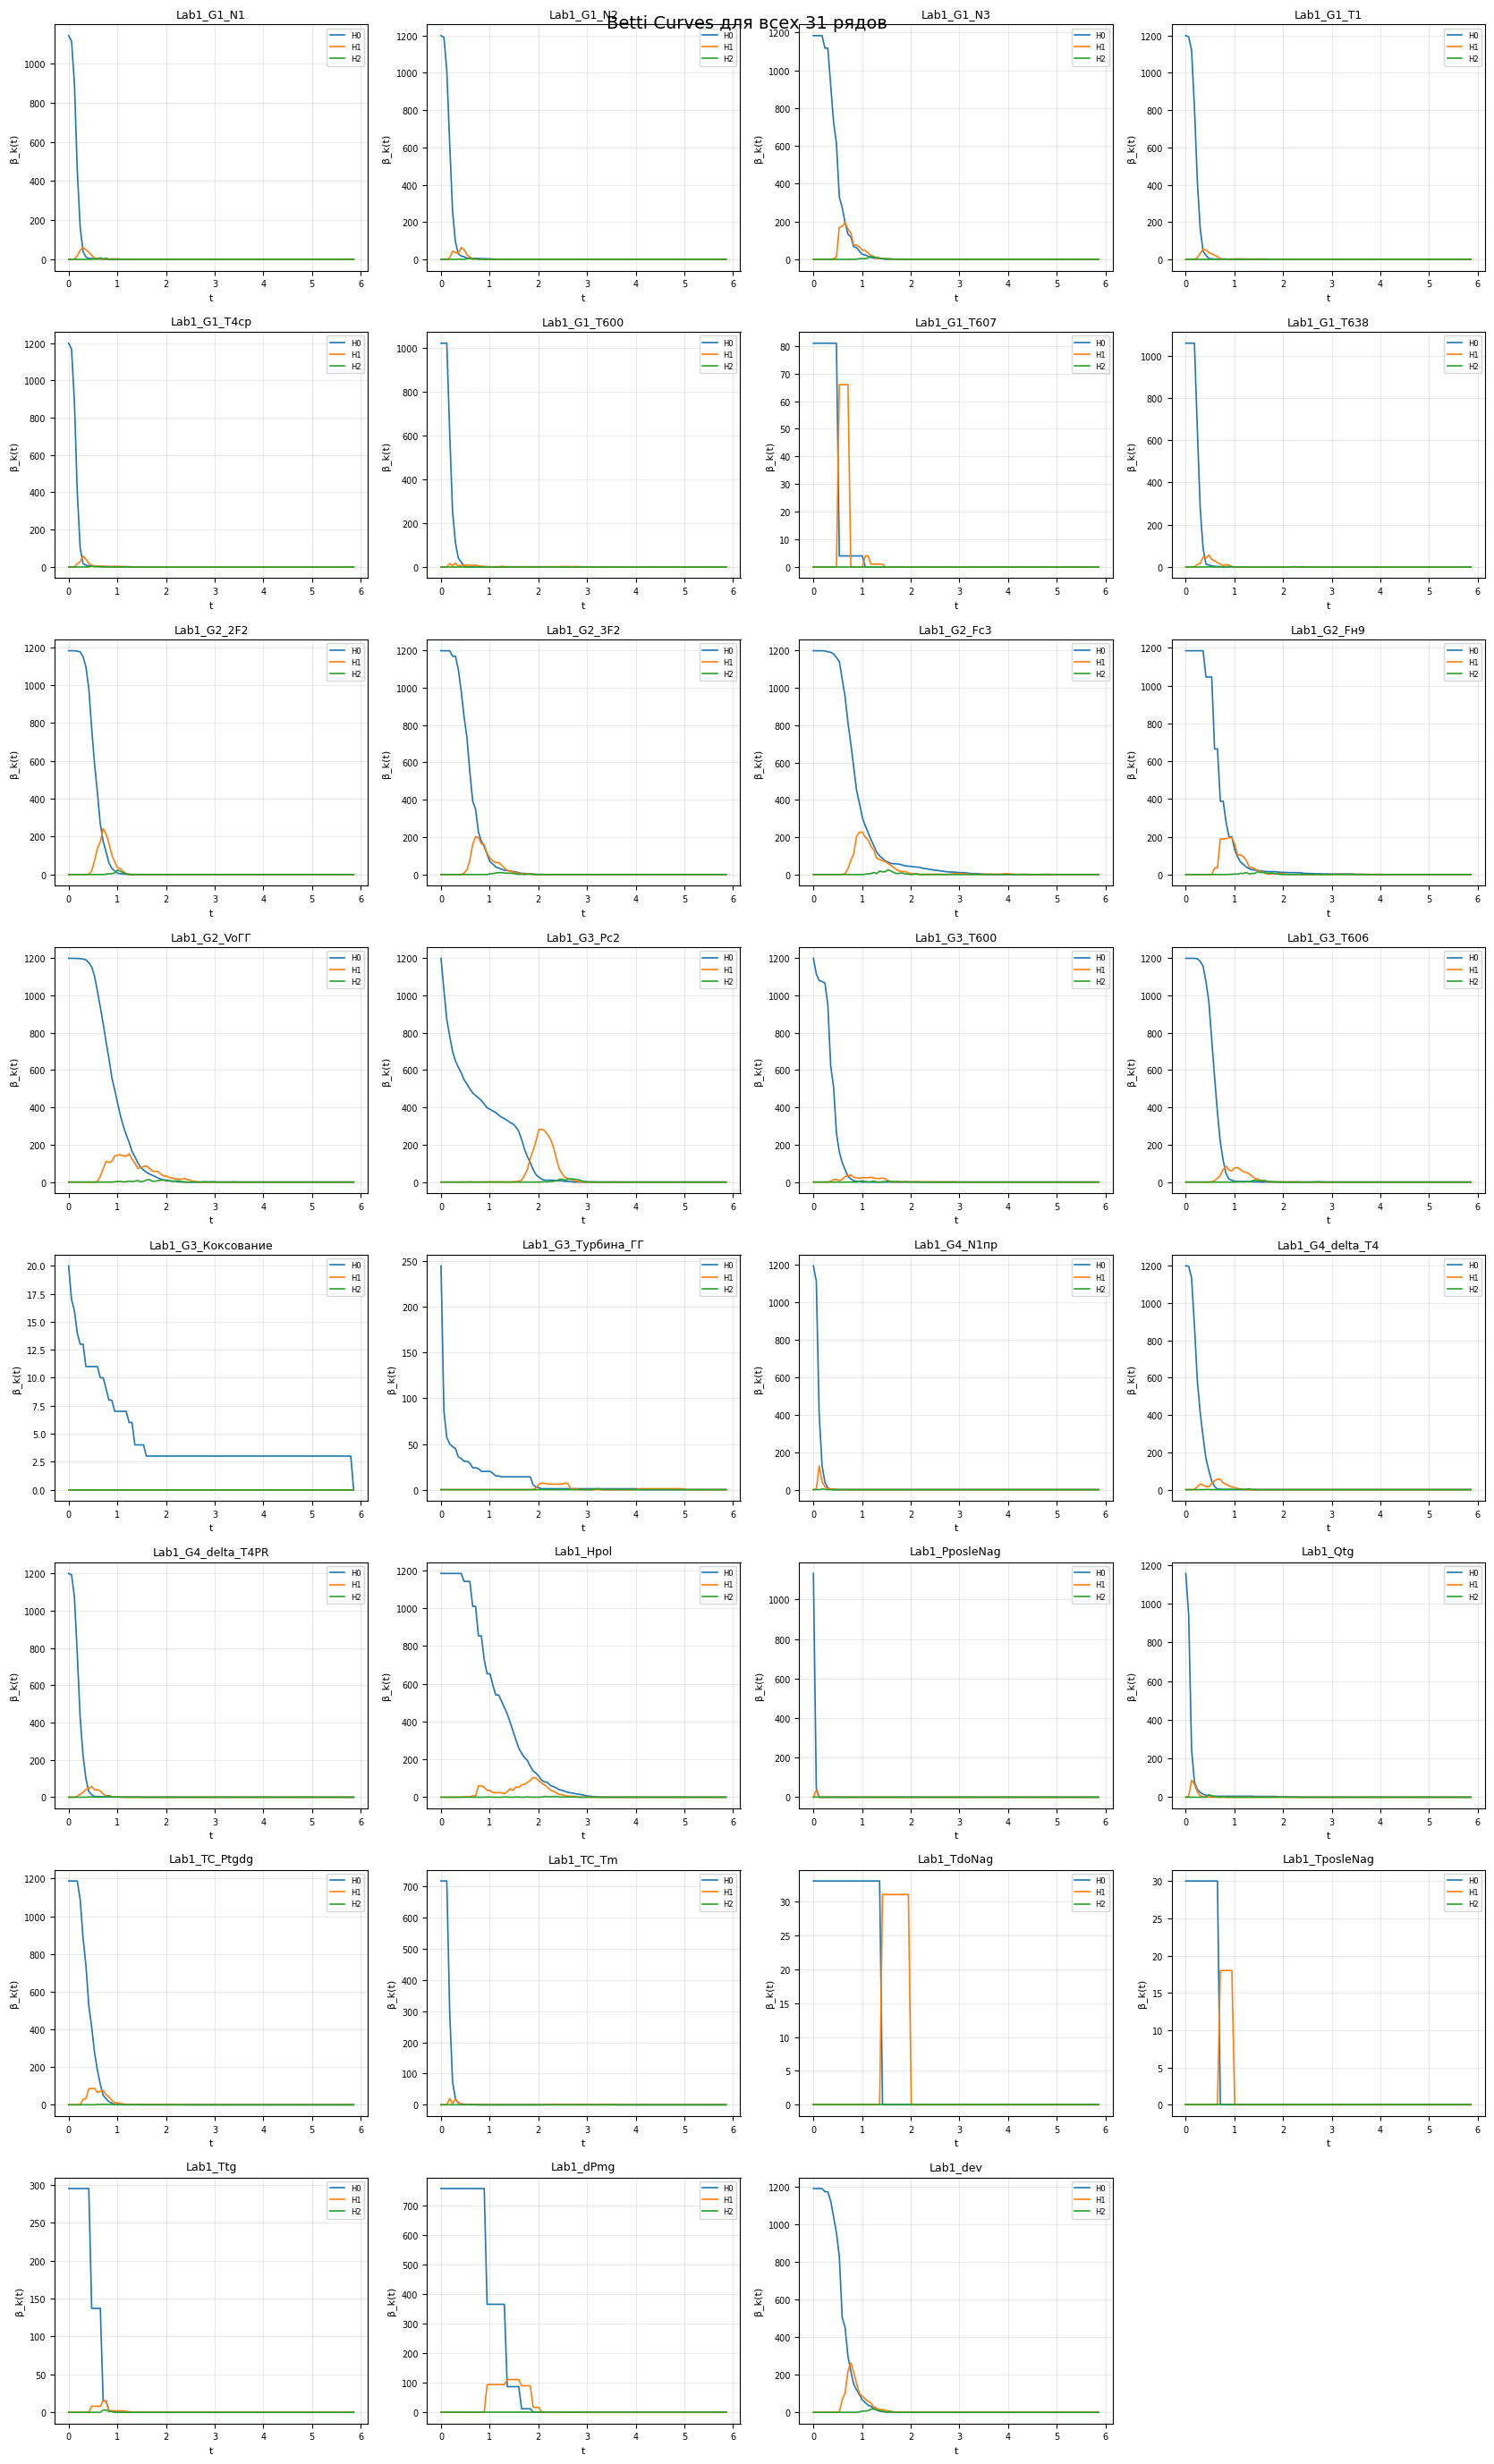

In [158]:
# =========================
# Betti curves: 31 маленький график
# =========================

fig, axes, n_rows, n_cols = make_axes_grid(len(columns), plots_per_row=4)

for idx, column_name in enumerate(columns):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row][col]

    betti_row = get_row_by_column(betti_df, column_name)

    if betti_row is None:
        ax.set_title(column_name, fontsize=9)
        ax.text(
            0.5, 0.5, "Нет данных",
            ha="center", va="center",
            transform=ax.transAxes
        )
        ax.axis("off")
        continue

    for h_dim in HOMOLOGY_DIMS:
        betti = extract_betti(betti_row, h_dim)
        ax.plot(grid, betti, linewidth=1.2, label=f"H{h_dim}")

    ax.set_title(column_name, fontsize=9)
    ax.set_xlabel("t", fontsize=8)
    ax.set_ylabel("β_k(t)", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=6)

# скрываем пустые оси
for empty_idx in range(len(columns), n_rows * n_cols):
    row = empty_idx // n_cols
    col = empty_idx % n_cols
    axes[row][col].axis("off")

plt.suptitle("Betti Curves для всех 31 рядов", fontsize=14)
plt.tight_layout()
plt.show()

## Все кривые Эйлера

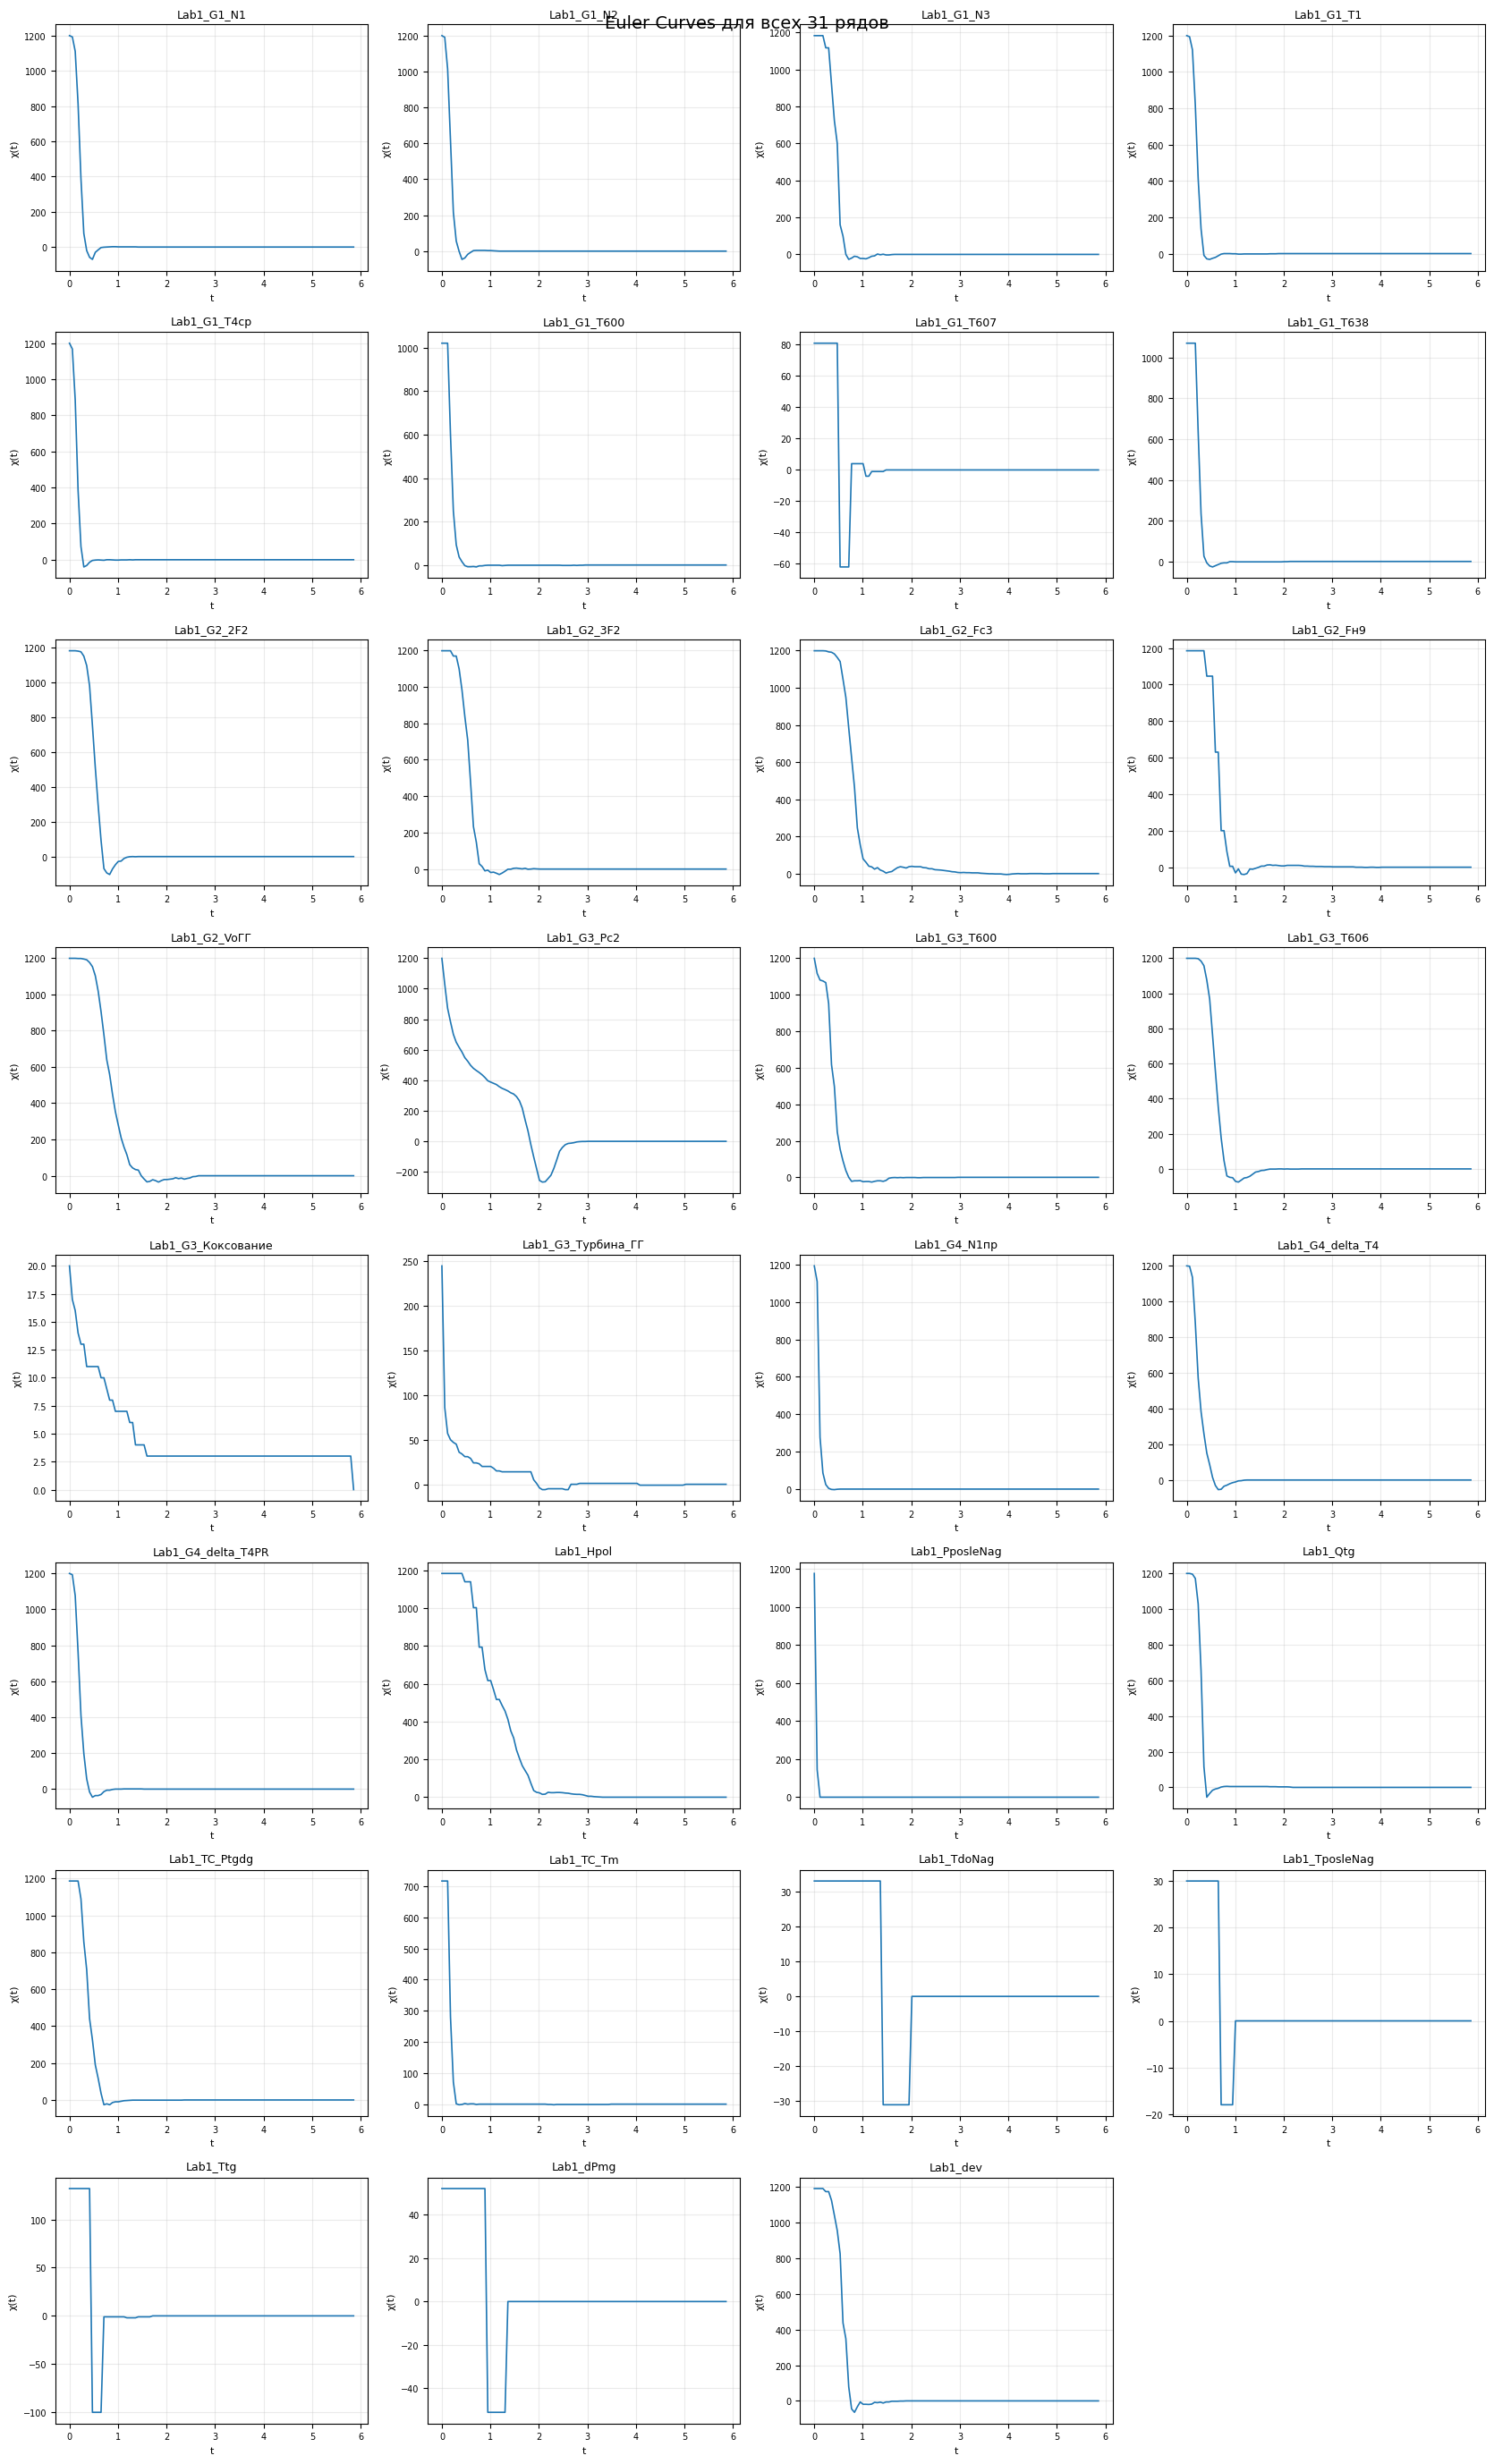

In [159]:
# =========================
# Euler curves: 31 маленький график
# =========================

fig, axes, n_rows, n_cols = make_axes_grid(len(columns), plots_per_row=4)

for idx, column_name in enumerate(columns):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row][col]

    euler_row = get_row_by_column(euler_df, column_name)

    if euler_row is None:
        ax.set_title(column_name, fontsize=9)
        ax.text(
            0.5, 0.5, "Нет данных",
            ha="center", va="center",
            transform=ax.transAxes
        )
        ax.axis("off")
        continue

    euler = extract_euler(euler_row)

    ax.plot(grid, euler, linewidth=1.2)
    ax.set_title(column_name, fontsize=9)
    ax.set_xlabel("t", fontsize=8)
    ax.set_ylabel("χ(t)", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.grid(alpha=0.25)

# скрываем пустые оси
for empty_idx in range(len(columns), n_rows * n_cols):
    row = empty_idx // n_cols
    col = empty_idx % n_cols
    axes[row][col].axis("off")

plt.suptitle("Euler Curves для всех 31 рядов", fontsize=14)
plt.tight_layout()
plt.show()

## Все ландшафты персистентности

1-й слой показывает самую выраженную активную топологическую особенность на каждом масштабе;

2-й слой показывает вторую по выраженности;

3-й слой — третью;

и так далее.

Чем выше пик, тем более выраженный и устойчивый признак.

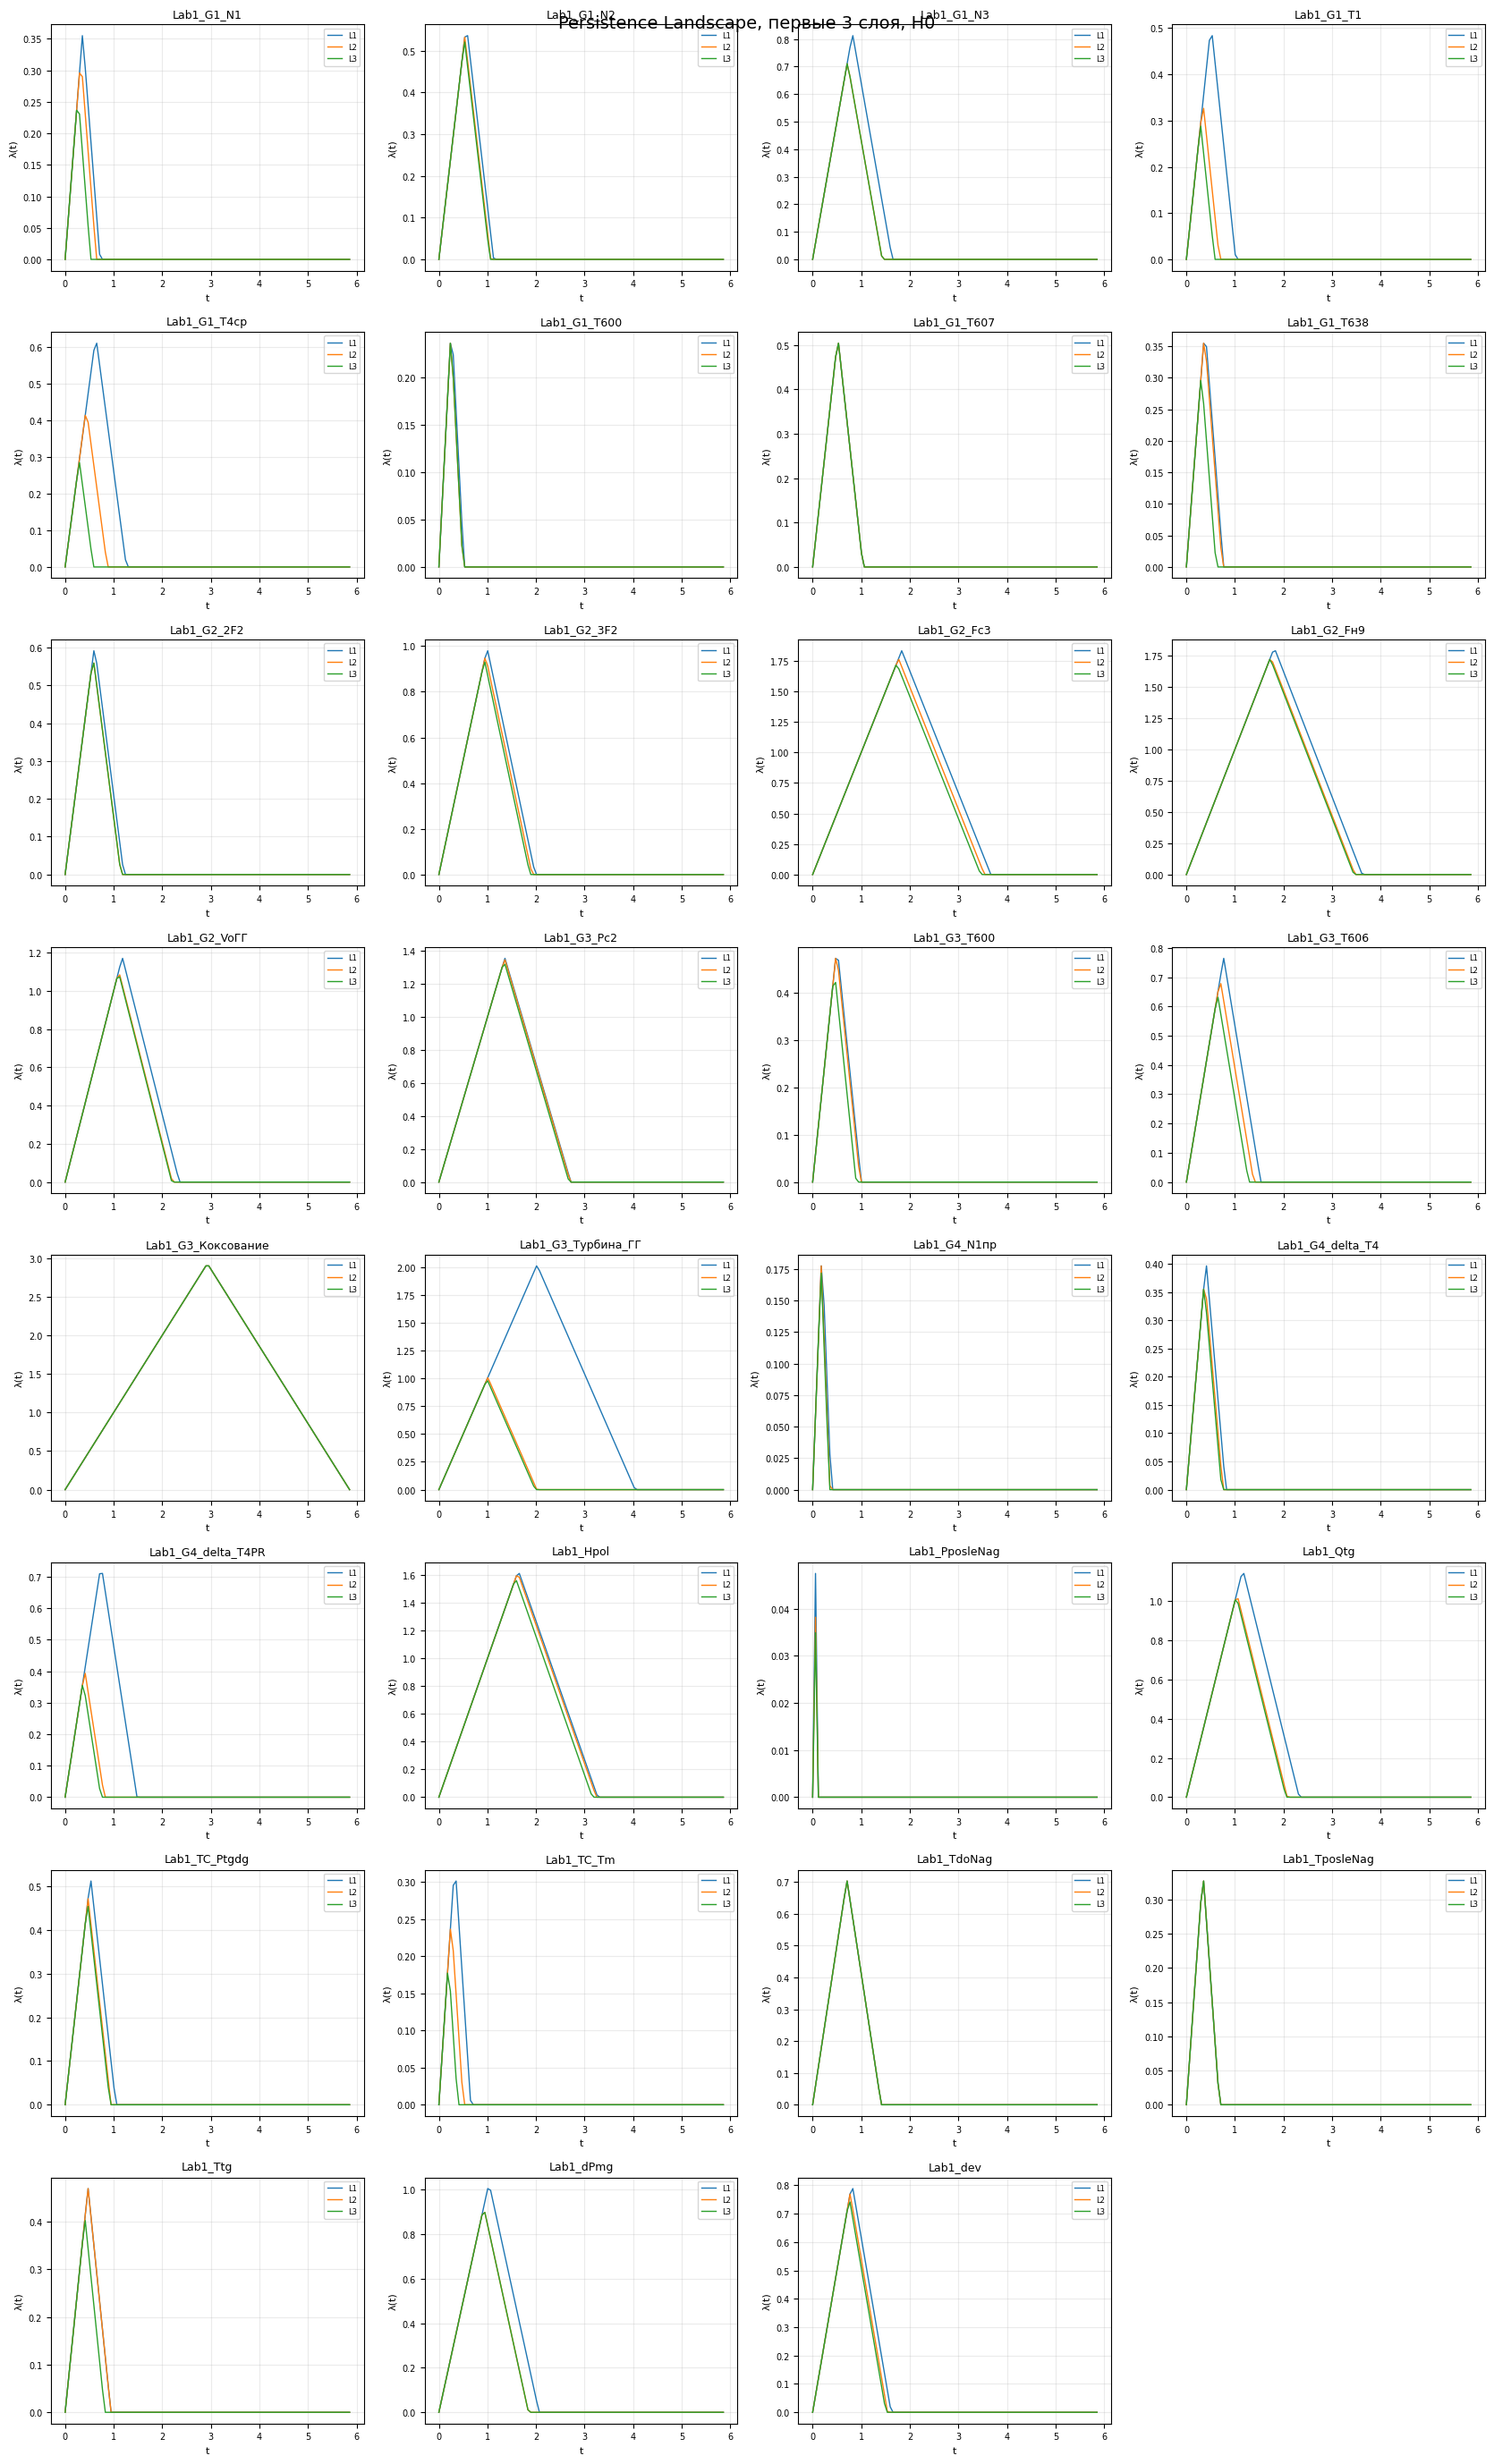

In [162]:
# =========================
# Persistence Landscape: первые 3 слоя для H0
# =========================

h_dim = 0
n_show_layers = 3

fig, axes, n_rows, n_cols = make_axes_grid(len(columns), plots_per_row=4)

for idx, column_name in enumerate(columns):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row][col]

    landscape_row = get_row_by_column(landscapes_df, column_name)

    if landscape_row is None:
        ax.set_title(column_name, fontsize=9)
        ax.text(
            0.5, 0.5, "Нет данных",
            ha="center", va="center",
            transform=ax.transAxes
        )
        ax.axis("off")
        continue

    landscape = extract_landscape(landscape_row, h_dim)

    for layer_idx in range(min(n_show_layers, landscape.shape[0])):
        ax.plot(
            grid,
            landscape[layer_idx],
            linewidth=1.0,
            label=f"L{layer_idx+1}"
        )

    ax.set_title(column_name, fontsize=9)
    ax.set_xlabel("t", fontsize=8)
    ax.set_ylabel("λ(t)", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=6)

for empty_idx in range(len(columns), n_rows * n_cols):
    row = empty_idx // n_cols
    col = empty_idx % n_cols
    axes[row][col].axis("off")

plt.suptitle(f"Persistence Landscape, первые {n_show_layers} слоя, H{h_dim}", fontsize=14)
plt.tight_layout()
plt.show()

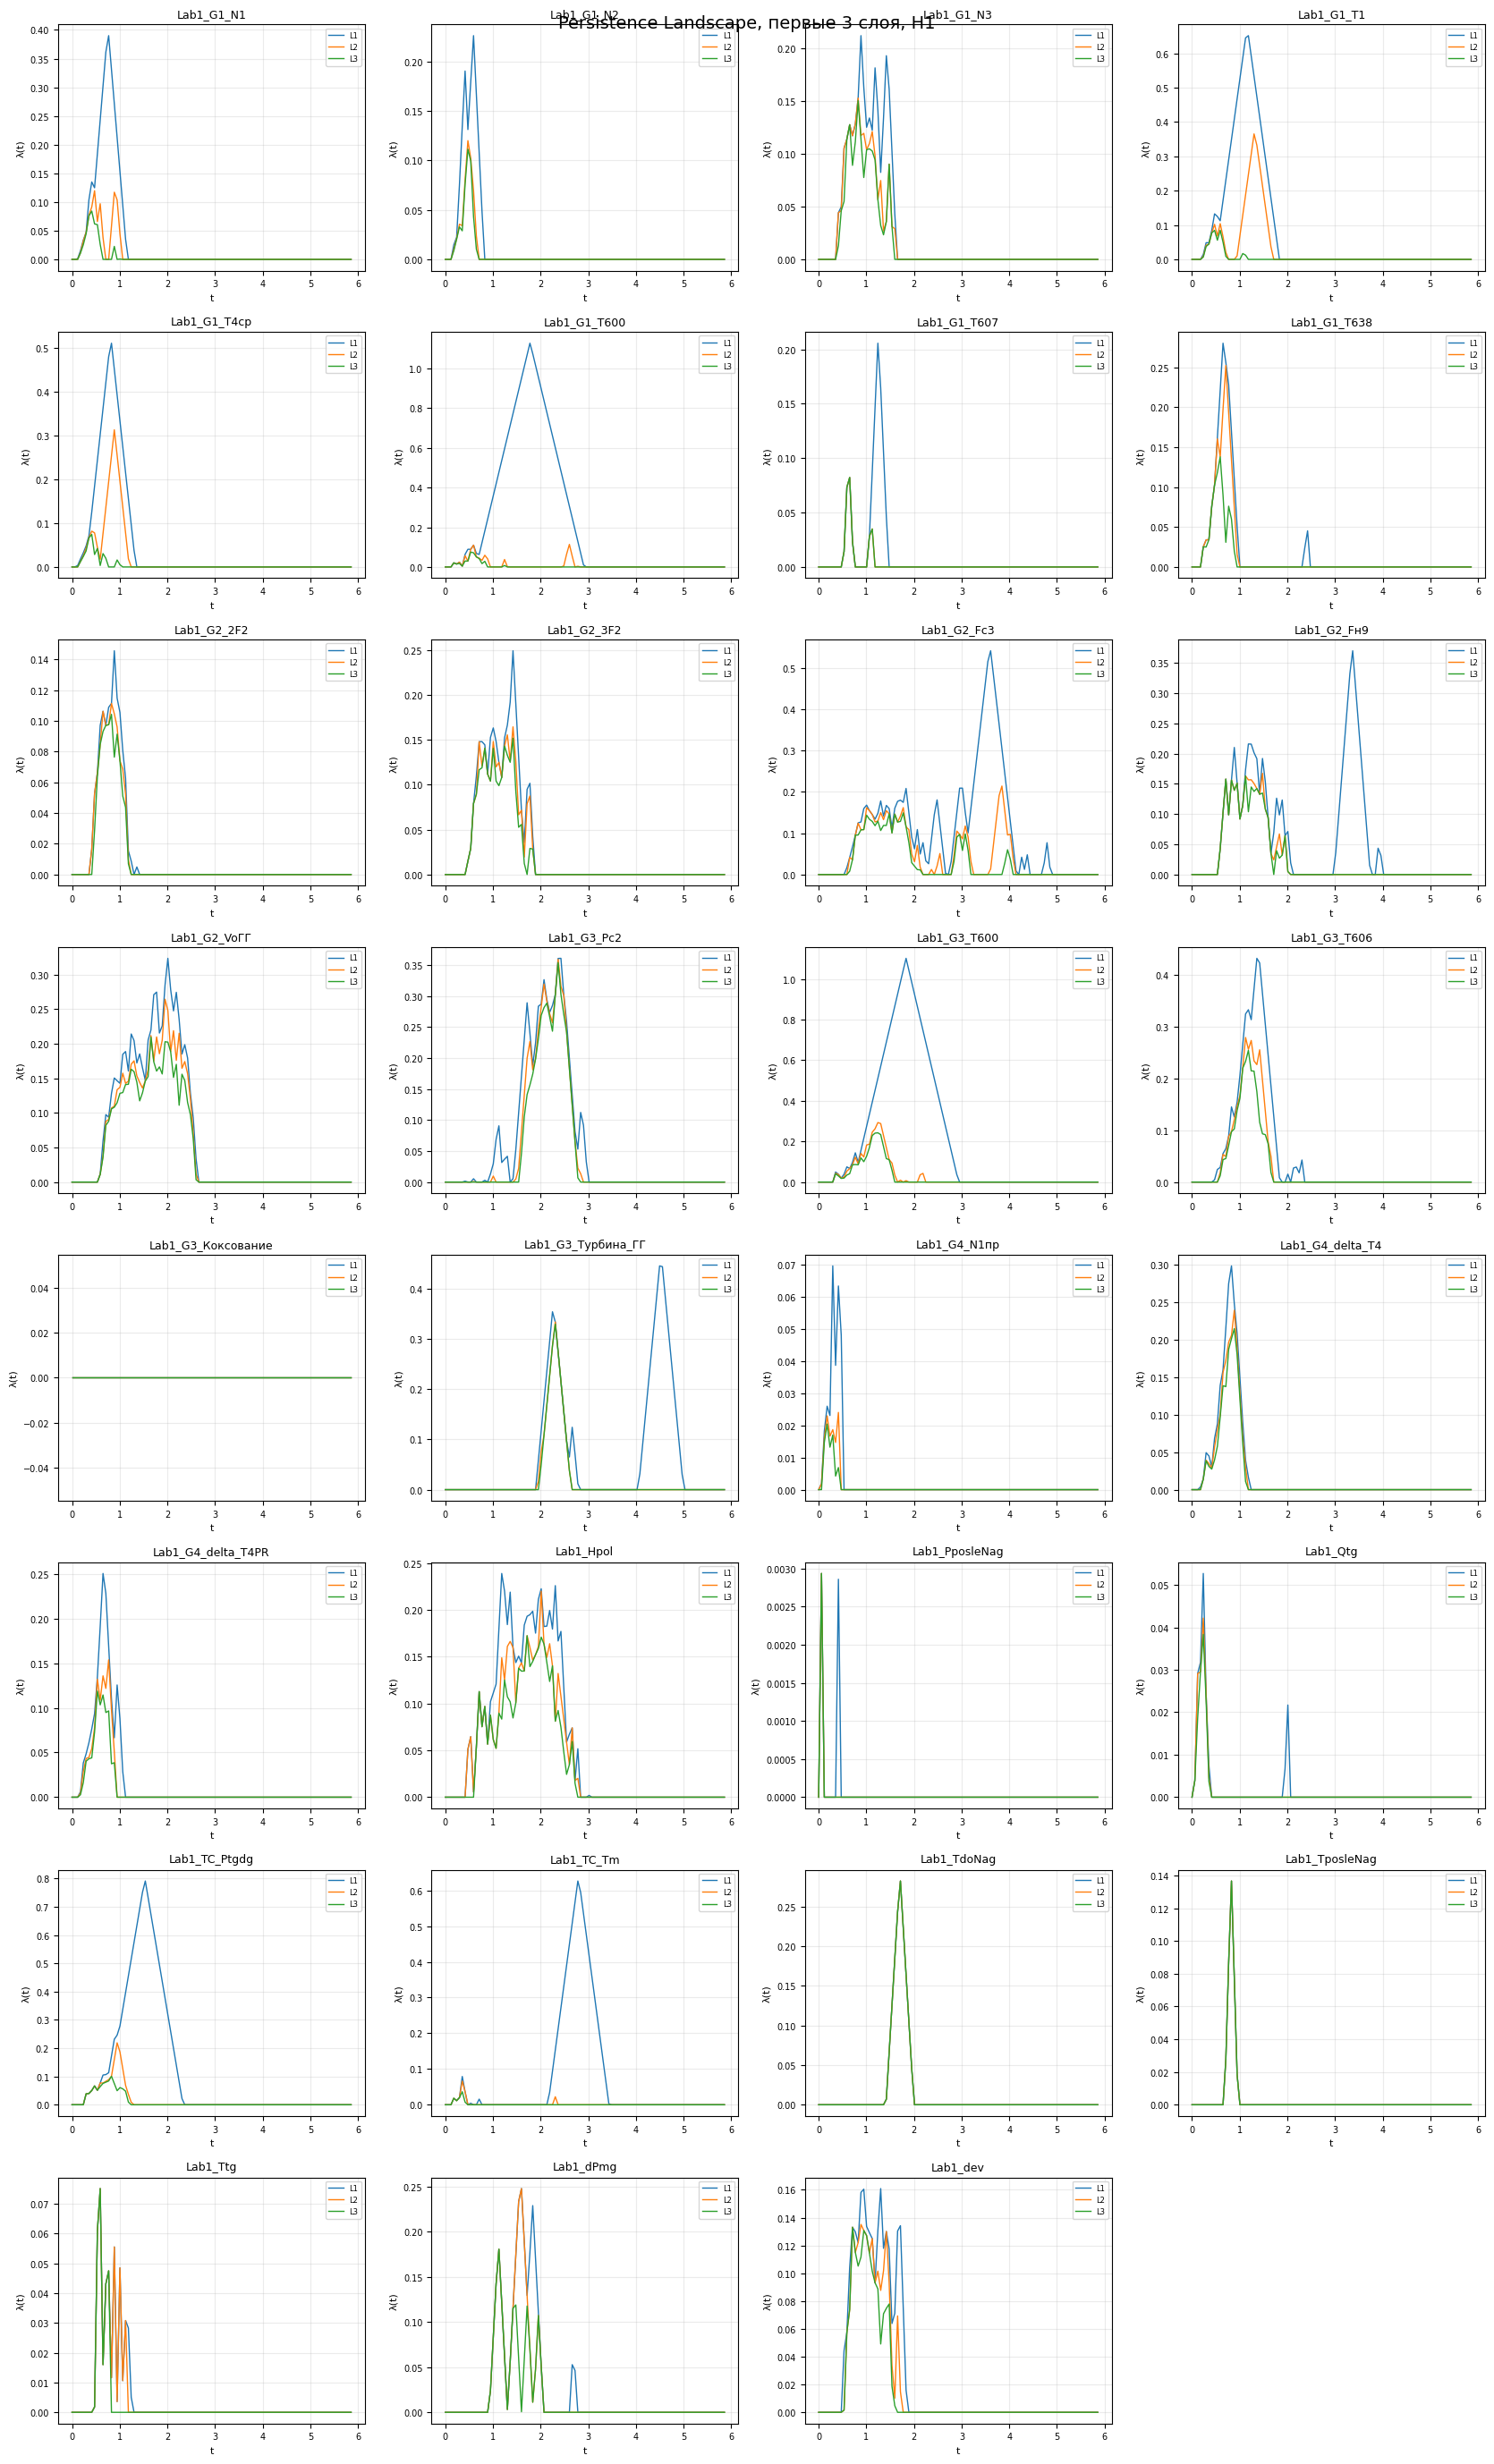

In [161]:
# =========================
# Persistence Landscape: первые 3 слоя для H1
# =========================

h_dim = 1
n_show_layers = 3

fig, axes, n_rows, n_cols = make_axes_grid(len(columns), plots_per_row=4)

for idx, column_name in enumerate(columns):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row][col]

    landscape_row = get_row_by_column(landscapes_df, column_name)

    if landscape_row is None:
        ax.set_title(column_name, fontsize=9)
        ax.text(
            0.5, 0.5, "Нет данных",
            ha="center", va="center",
            transform=ax.transAxes
        )
        ax.axis("off")
        continue

    landscape = extract_landscape(landscape_row, h_dim)

    for layer_idx in range(min(n_show_layers, landscape.shape[0])):
        ax.plot(
            grid,
            landscape[layer_idx],
            linewidth=1.0,
            label=f"L{layer_idx+1}"
        )

    ax.set_title(column_name, fontsize=9)
    ax.set_xlabel("t", fontsize=8)
    ax.set_ylabel("λ(t)", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=6)

for empty_idx in range(len(columns), n_rows * n_cols):
    row = empty_idx // n_cols
    col = empty_idx % n_cols
    axes[row][col].axis("off")

plt.suptitle(f"Persistence Landscape, первые {n_show_layers} слоя, H{h_dim}", fontsize=14)
plt.tight_layout()
plt.show()

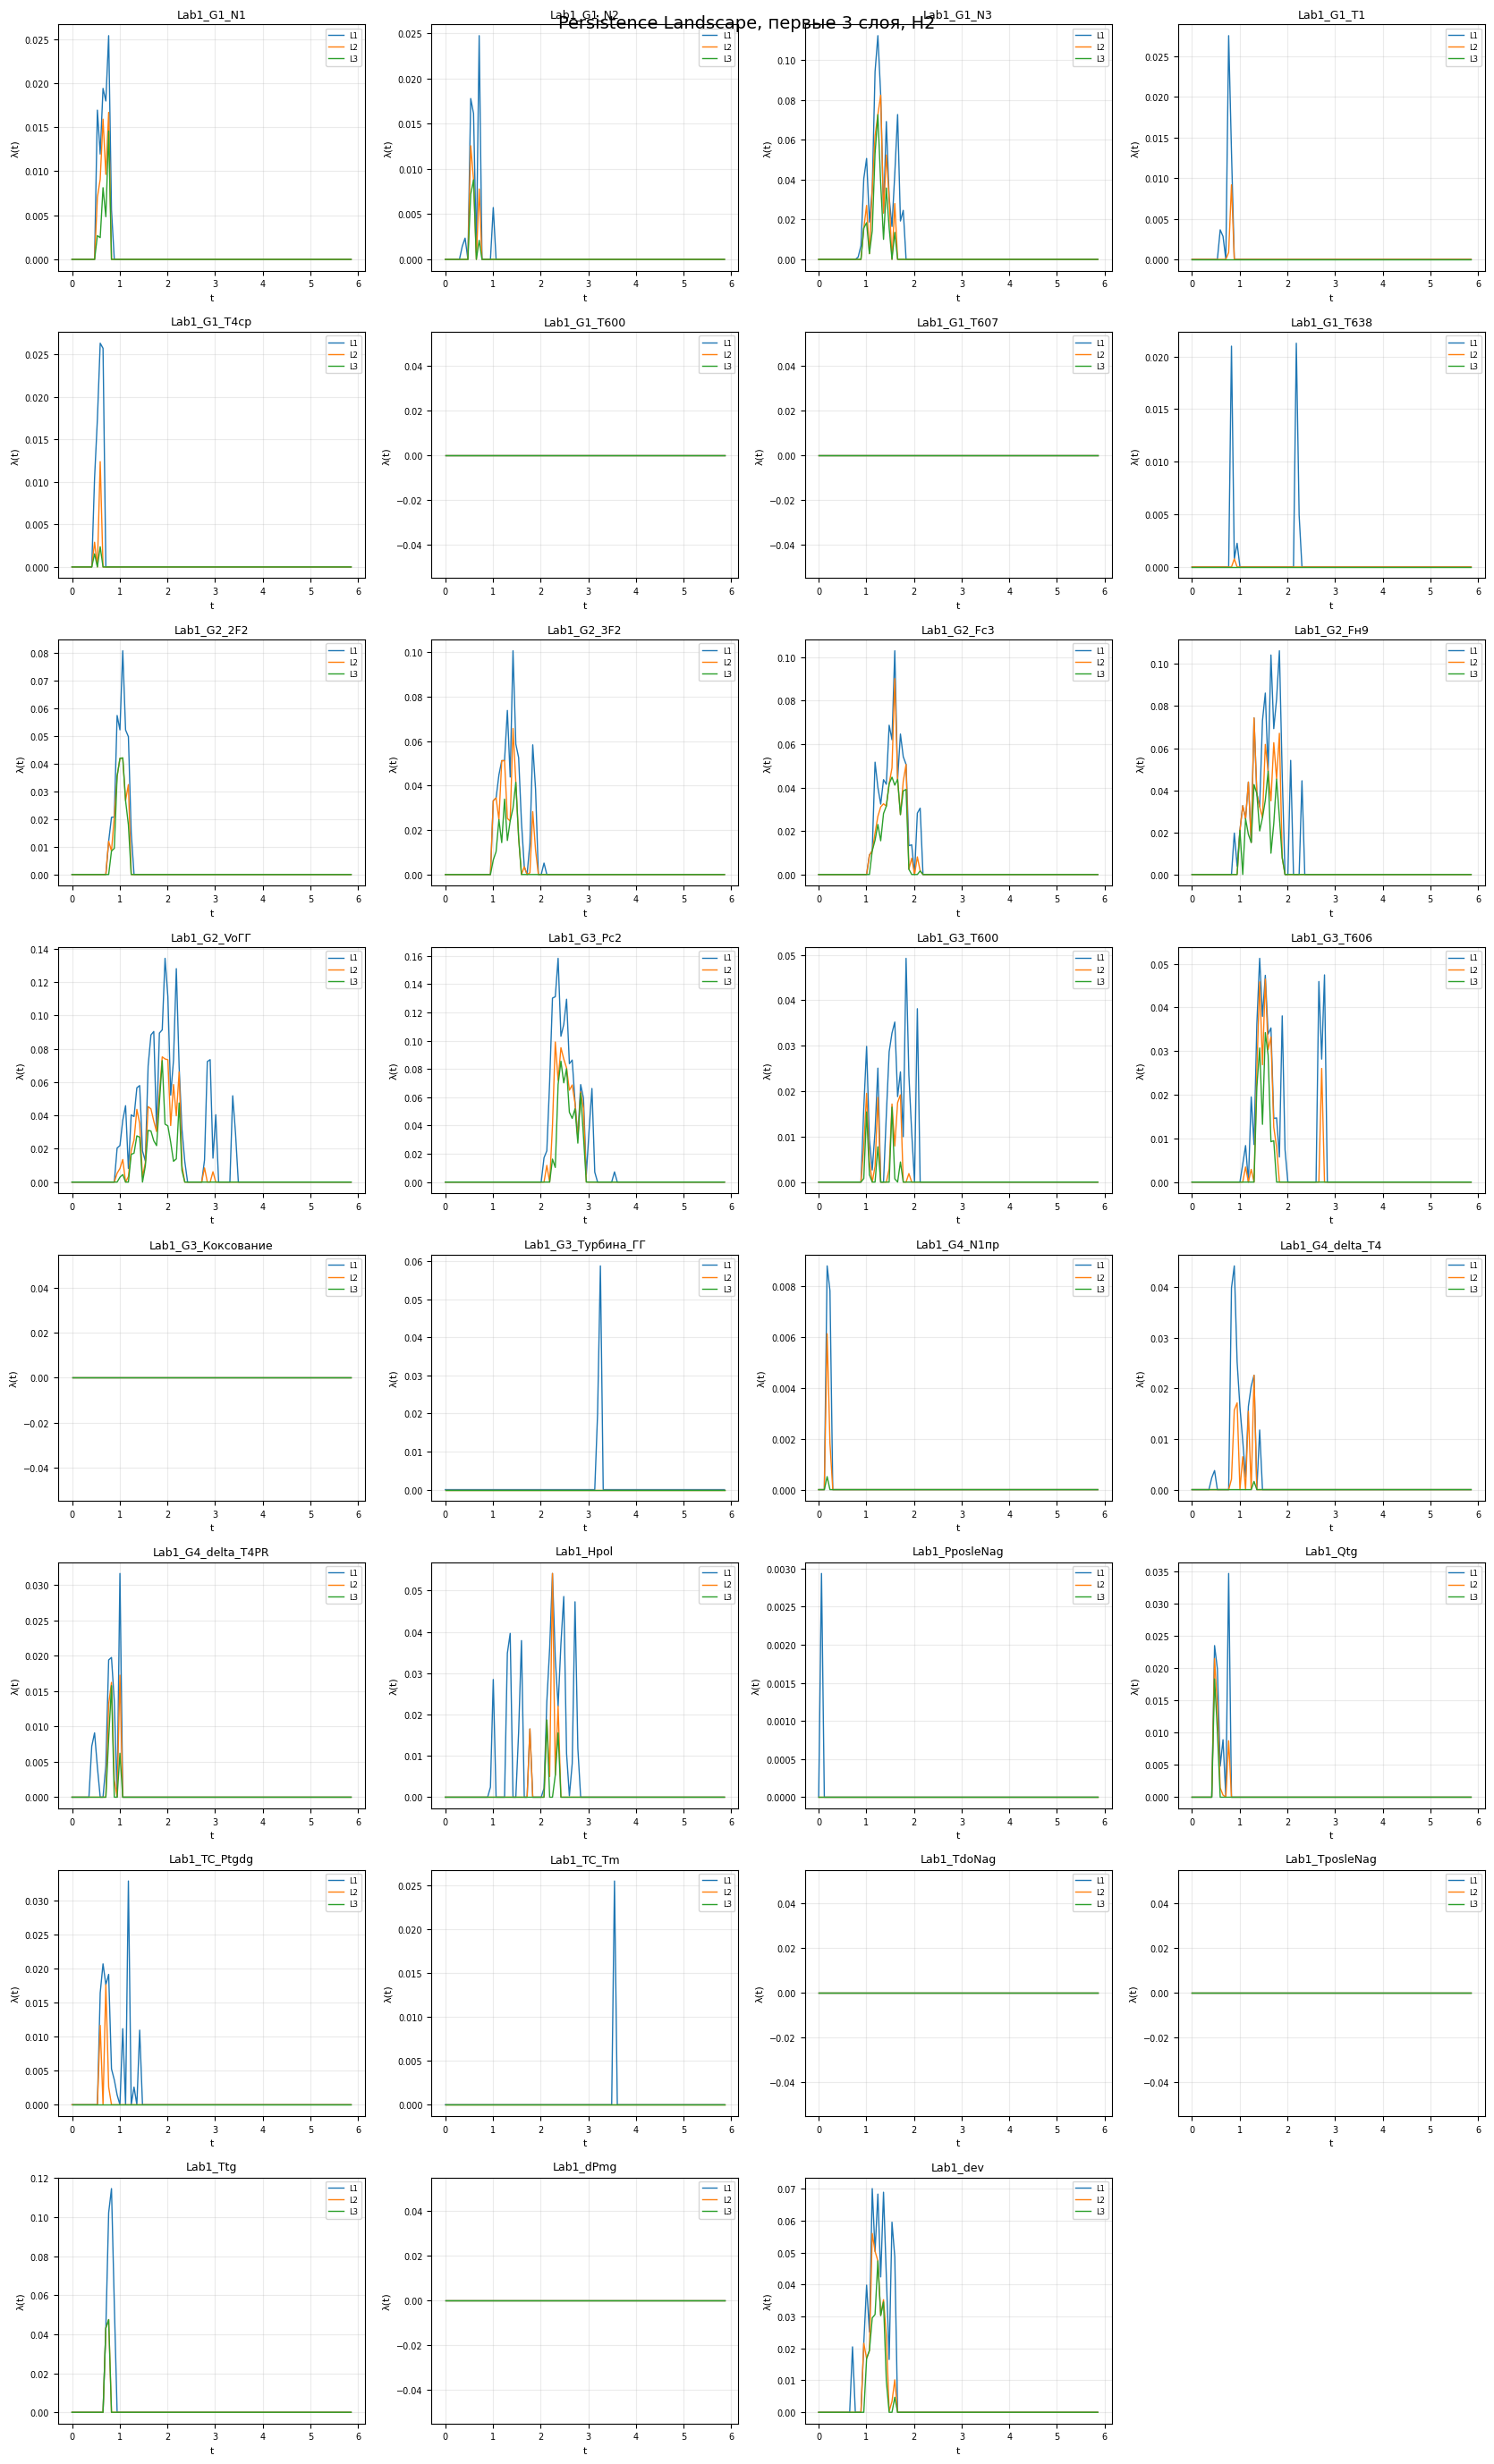

In [163]:
# =========================
# Persistence Landscape: первые 3 слоя для H2
# =========================

h_dim = 2
n_show_layers = 3

fig, axes, n_rows, n_cols = make_axes_grid(len(columns), plots_per_row=4)

for idx, column_name in enumerate(columns):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row][col]

    landscape_row = get_row_by_column(landscapes_df, column_name)

    if landscape_row is None:
        ax.set_title(column_name, fontsize=9)
        ax.text(
            0.5, 0.5, "Нет данных",
            ha="center", va="center",
            transform=ax.transAxes
        )
        ax.axis("off")
        continue

    landscape = extract_landscape(landscape_row, h_dim)

    for layer_idx in range(min(n_show_layers, landscape.shape[0])):
        ax.plot(
            grid,
            landscape[layer_idx],
            linewidth=1.0,
            label=f"L{layer_idx+1}"
        )

    ax.set_title(column_name, fontsize=9)
    ax.set_xlabel("t", fontsize=8)
    ax.set_ylabel("λ(t)", fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=6)

for empty_idx in range(len(columns), n_rows * n_cols):
    row = empty_idx // n_cols
    col = empty_idx % n_cols
    axes[row][col].axis("off")

plt.suptitle(f"Persistence Landscape, первые {n_show_layers} слоя, H{h_dim}", fontsize=14)
plt.tight_layout()
plt.show()

## Кластеризация

## Кластеризация по расстоянию Вассерштейна между диаграммами (K1)

## Подбор количества кластеров для K1

In [168]:
# ============================================================
# Расчёт матрицы расстояний Вассерштейна для K1
# ============================================================

from gtda.diagrams import PairwiseDistance

wasserstein_distance = PairwiseDistance(
    metric="wasserstein",
    metric_params={
        "p": 2,
        "delta": 0.1,
    },
    n_jobs=-1
)

Dw = wasserstein_distance.fit_transform(X_diagrams)

print("Матрица Wasserstein-расстояний рассчитана.")
print("Форма Dw:", Dw.shape)

Матрица Wasserstein-расстояний рассчитана.
Форма Dw: (31, 31)


### Критерии выбора количества кластеров

Для выбора количества кластеров в кластеризации K1 использовались два внутренних критерия качества: **Silhouette score** и **Dunn index**. Оба критерия позволяют оценить качество разбиения без заранее известных истинных меток классов.

**Silhouette score** показывает, насколько объект похож на объекты своего кластера по сравнению с объектами ближайшего соседнего кластера. Значение коэффициента лежит в диапазоне от -1 до 1. Чем ближе значение к 1, тем лучше объект согласуется со своим кластером и тем сильнее отделён от других кластеров. При выборе количества кластеров предпочтительным считается значение `K`, при котором средний Silhouette score максимален.

**Dunn index** оценивает соотношение между минимальным расстоянием между разными кластерами и максимальным расстоянием внутри одного кластера. Чем выше значение Dunn index, тем лучше кластеризация: кластеры являются более компактными внутри и лучше отделены друг от друга. При выборе количества кластеров предпочтительным считается значение `K`, при котором Dunn index максимален.

В данной работе оба критерия рассчитывались по матрице попарных Wasserstein-расстояний между диаграммами персистентности. Поэтому качество кластеризации оценивалось не по исходным временным рядам, а по степени близости их топологических представлений.

In [169]:
# ============================================================
# Подбор количества кластеров для K1
# Критерии:
#   1) Silhouette score — больше лучше
#   2) Dunn index — больше лучше
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Функция для Dunn index
# ------------------------------------------------------------

def dunn_index(distance_matrix, labels):
    """
    Dunn index = минимальное межкластерное расстояние /
                 максимальное внутрикластерное расстояние

    Чем больше значение, тем лучше кластеризация:
    - кластеры хорошо разделены между собой;
    - точки внутри кластеров близки друг к другу.
    """

    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    intra_distances = []
    inter_distances = []

    for cluster in unique_labels:
        cluster_idx = np.where(labels == cluster)[0]

        if len(cluster_idx) > 1:
            intra = distance_matrix[np.ix_(cluster_idx, cluster_idx)]
            intra_distances.append(np.max(intra))
        else:
            intra_distances.append(0)

    for i, cluster_i in enumerate(unique_labels):
        idx_i = np.where(labels == cluster_i)[0]

        for cluster_j in unique_labels[i + 1:]:
            idx_j = np.where(labels == cluster_j)[0]

            inter = distance_matrix[np.ix_(idx_i, idx_j)]
            inter_distances.append(np.min(inter))

    max_intra = np.max(intra_distances)
    min_inter = np.min(inter_distances)

    if max_intra == 0:
        return np.nan

    return min_inter / max_intra


# ------------------------------------------------------------
# Подбор K
# ------------------------------------------------------------

k_values = range(2, min(10, len(columns) - 1) + 1)

k1_selection_results = []

for k in k_values:

    try:
        clustering = AgglomerativeClustering(
            n_clusters=k,
            metric="precomputed",
            linkage="average"
        )
    except TypeError:
        clustering = AgglomerativeClustering(
            n_clusters=k,
            affinity="precomputed",
            linkage="average"
        )

    labels = clustering.fit_predict(Dw)

    silhouette = silhouette_score(
        Dw,
        labels,
        metric="precomputed"
    )

    dunn = dunn_index(Dw, labels)

    k1_selection_results.append({
        "k": k,
        "silhouette": silhouette,
        "dunn_index": dunn
    })


k1_selection_df = pd.DataFrame(k1_selection_results)

display(k1_selection_df)

# ------------------------------------------------------------
# Лучшие K по каждому критерию
# ------------------------------------------------------------

best_k_silhouette = k1_selection_df.loc[
    k1_selection_df["silhouette"].idxmax(),
    "k"
]

best_k_dunn = k1_selection_df.loc[
    k1_selection_df["dunn_index"].idxmax(),
    "k"
]

print(f"Лучшее K по silhouette score: {best_k_silhouette}")
print(f"Лучшее K по Dunn index: {best_k_dunn}")

if best_k_silhouette == best_k_dunn:
    K1 = int(best_k_silhouette)
    print(f"Оба критерия выбрали одно значение: K1 = {K1}")
else:
    K1 = int(best_k_silhouette)
    print(
        "Критерии выбрали разные значения. "
        f"Для K1 берём K = {K1} по максимальному silhouette score."
    )

,k,silhouette,dunn_index
0,2,0.562553,0.637636
1,3,0.510556,0.680755
2,4,0.498897,0.680768
3,5,0.467800,0.412639
4,6,0.455004,0.412639
5,7,0.400353,0.539356
6,8,0.340611,0.485042
7,9,0.293169,0.525489
8,10,0.275063,0.525504


Лучшее K по silhouette score: 2
Лучшее K по Dunn index: 4
Критерии выбрали разные значения. Для K1 берём K = 2 по максимальному silhouette score.


In [170]:
# ============================================================
# K1. Финальная кластеризация для двух вариантов K
#     K = 2 по Silhouette score
#     K = 4 по Dunn index
# ============================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Варианты количества кластеров
# ------------------------------------------------------------

K1_values = [2, 4]

k1_all_clusters = []
k1_quality_results = []

for K1 in K1_values:

    print("=" * 70)
    print(f"K1-кластеризация для K = {K1}")
    print("=" * 70)

    # --------------------------------------------------------
    # Агломеративная кластеризация по Wasserstein-расстояниям
    # --------------------------------------------------------

    try:
        clustering_K1 = AgglomerativeClustering(
            n_clusters=K1,
            metric="precomputed",
            linkage="average"
        )
    except TypeError:
        clustering_K1 = AgglomerativeClustering(
            n_clusters=K1,
            affinity="precomputed",
            linkage="average"
        )

    labels_K1 = clustering_K1.fit_predict(Dw)

    # --------------------------------------------------------
    # Метрики качества
    # --------------------------------------------------------

    sil_K1 = silhouette_score(
        Dw,
        labels_K1,
        metric="precomputed"
    )

    dunn_K1 = dunn_index(Dw, labels_K1)

    k1_quality_results.append({
        "K": K1,
        "silhouette": sil_K1,
        "dunn_index": dunn_K1
    })

    print(f"Silhouette score: {sil_K1:.4f}")
    print(f"Dunn index: {dunn_K1:.4f}")

    # --------------------------------------------------------
    # Таблица кластеров для текущего K
    # --------------------------------------------------------

    current_clusters = pd.DataFrame({
        "column": columns,
        f"cluster_K1_K{K1}_wasserstein_agglomerative": labels_K1
    })

    display(current_clusters)

    print(f"\nРазмеры кластеров для K = {K1}:")
    display(
        current_clusters[f"cluster_K1_K{K1}_wasserstein_agglomerative"]
        .value_counts()
        .sort_index()
    )

    # --------------------------------------------------------
    # Сохранение отдельного файла
    # --------------------------------------------------------

    current_output_path = (
        OUTPUT_DIR / f"clusters_K1_K{K1}_wasserstein_agglomerative.csv"
    )

    current_clusters.to_csv(
        current_output_path,
        index=False
    )

    print("Кластеры сохранены:")
    print(current_output_path)

    k1_all_clusters.append(current_clusters)


# ============================================================
# Сводная таблица качества для K = 2 и K = 4
# ============================================================

k1_quality_df = pd.DataFrame(k1_quality_results)

print("\nСравнение качества K1-кластеризации:")
display(k1_quality_df)

k1_quality_df.to_csv(
    OUTPUT_DIR / "clusters_K1_quality_K2_K4.csv",
    index=False
)


# ============================================================
# Общая таблица с двумя вариантами кластеризации
# ============================================================

k1_comparison = k1_all_clusters[0]

for df_clusters in k1_all_clusters[1:]:
    k1_comparison = k1_comparison.merge(
        df_clusters,
        on="column",
        how="outer"
    )

print("\nСравнение разметок K1 для K = 2 и K = 4:")
display(k1_comparison)

k1_comparison.to_csv(
    OUTPUT_DIR / "clusters_K1_comparison_K2_K4.csv",
    index=False
)

print("Сравнение кластеризаций сохранено:")
print(OUTPUT_DIR / "clusters_K1_comparison_K2_K4.csv")

K1-кластеризация для K = 2
Silhouette score: 0.5626
Dunn index: 0.6376


,column,cluster_K1_K2_wasserstein_agglomerative
0,Lab1_G1_N1,1
1,Lab1_G1_N2,1
2,Lab1_G1_N3,1
3,Lab1_G1_T1,1
4,Lab1_G1_T4ср,1
5,Lab1_G1_T600,1
6,Lab1_G1_T607,1
7,Lab1_G1_T638,1
8,Lab1_G2_2F2,1
9,Lab1_G2_3F2,1



Размеры кластеров для K = 2:


cluster_K1_K2_wasserstein_agglomerative
0     5
1    26
Name: count, dtype: int64

Кластеры сохранены:
persistence_vectors\clusters_K1_K2_wasserstein_agglomerative.csv
K1-кластеризация для K = 4
Silhouette score: 0.4989
Dunn index: 0.6808


...

Кластеры сохранены:
persistence_vectors\clusters_K1_K4_wasserstein_agglomerative.csv

Сравнение качества K1-кластеризации:


,K,silhouette,dunn_index
0,2,0.562553,0.637636
1,4,0.498897,0.680768



Сравнение разметок K1 для K = 2 и K = 4:


,column,cluster_K1_K2_wasserstein_agglomerative,cluster_K1_K4_wasserstein_agglomerative
0,Lab1_G1_N1,1,0
1,Lab1_G1_N2,1,0
2,Lab1_G1_N3,1,0
3,Lab1_G1_T1,1,0
4,Lab1_G1_T4ср,1,0
5,Lab1_G1_T600,1,0
6,Lab1_G1_T607,1,0
7,Lab1_G1_T638,1,0
8,Lab1_G2_2F2,1,0
9,Lab1_G2_3F2,1,0


Сравнение кластеризаций сохранено:
persistence_vectors\clusters_K1_comparison_K2_K4.csv


## MDS-визуализация для K=2 и K=4

**Многомерное шкалирование (Multidimensional Scaling, MDS)** — это метод снижения размерности, предназначенный для представления множества объектов в пространстве меньшей размерности на основе заданной матрицы попарных расстояний или различий между объектами. Основная идея MDS заключается в построении таких координат объектов в низкоразмерном пространстве, при которых расстояния между точками как можно лучше сохраняют исходные попарные расстояния.

В данной работе MDS используется для визуализации результатов кластеризации диаграмм персистентности. В качестве исходной матрицы расстояний используется матрица расстояний Вассерштейна между диаграммами персистентности временных рядов. После применения MDS каждый временной ряд отображается точкой на двумерной плоскости, причём близкое расположение точек соответствует близости их топологических представлений, а удалённое расположение — существенному различию между ними.

Важно отметить, что MDS не выполняет кластеризацию, а используется только как способ визуального представления объектов, для которых исходно задана матрица расстояний.

,column,cluster_K1_K2_wasserstein_agglomerative,cluster_K1_K4_wasserstein_agglomerative
0,Lab1_G1_N1,1,0
1,Lab1_G1_N2,1,0
2,Lab1_G1_N3,1,0
3,Lab1_G1_T1,1,0
4,Lab1_G1_T4ср,1,0


Проверка матрицы расстояний для MDS:
Форма Dw_mds: (31, 31)
Симметрична: True
Минимальное расстояние: 0.0
Максимальное расстояние: 23.28445913578223


,column,MDS_1,MDS_2,cluster_K1_K2_wasserstein_agglomerative,cluster_K1_K4_wasserstein_agglomerative
0,Lab1_G1_N1,-4.133066,3.882087,1,0
1,Lab1_G1_N2,-4.237809,3.185982,1,0
2,Lab1_G1_N3,-2.940220,-4.613140,1,0
3,Lab1_G1_T1,-4.952180,2.773372,1,0
4,Lab1_G1_T4ср,-4.053546,4.149475,1,0


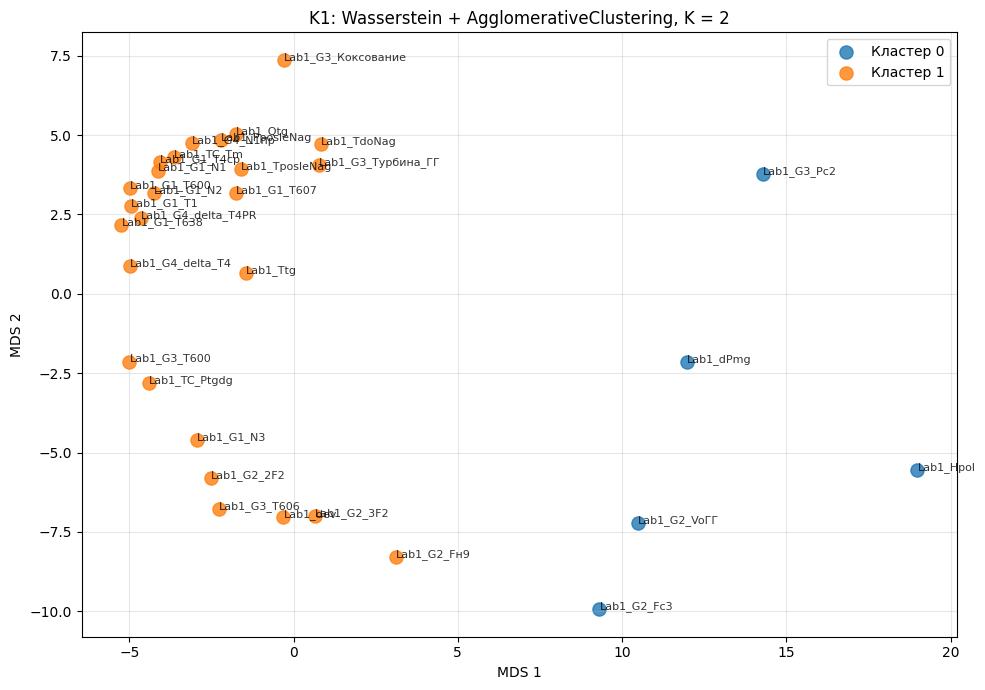

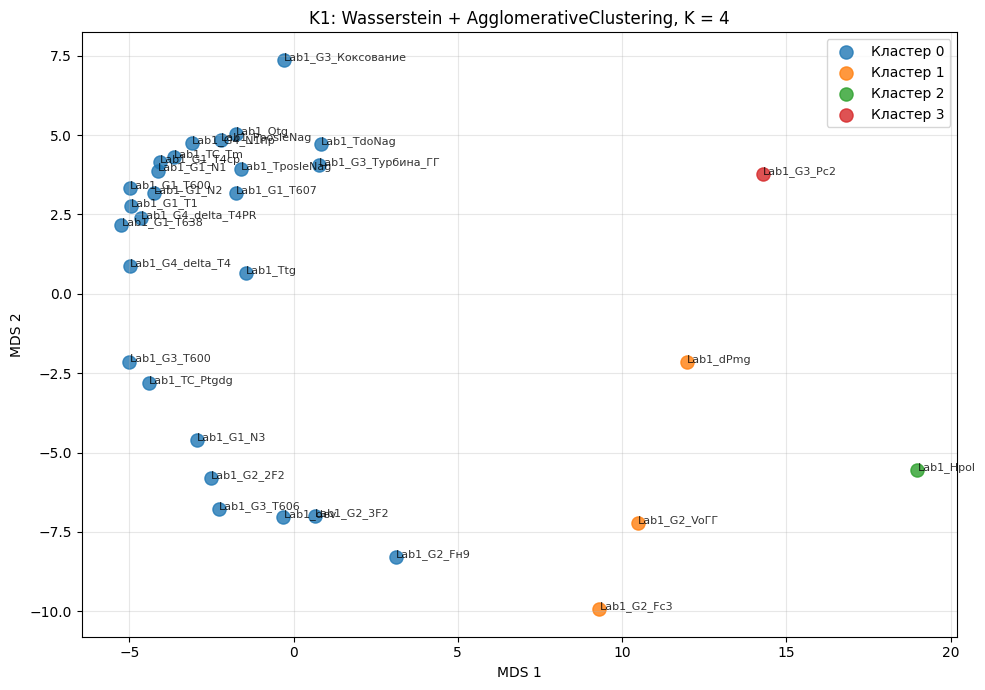

In [172]:
# ============================================================
# Визуализация K1-кластеризации через MDS
# Для K = 2 и K = 4
# ============================================================

from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Проверяем, что нужные переменные есть
# ------------------------------------------------------------

display(k1_comparison.head())

assert "Dw" in globals(), "Не найдена матрица расстояний Dw"
assert "k1_comparison" in globals(), "Не найдена таблица k1_comparison"
assert len(columns) == Dw.shape[0], "Количество columns должно совпадать с размером Dw"

# ------------------------------------------------------------
# 2. Исправляем Dw для MDS
# MDS требует строго симметричную матрицу расстояний
# ------------------------------------------------------------

Dw_mds = np.asarray(Dw, dtype=float)

finite_values = Dw_mds[np.isfinite(Dw_mds)]

if len(finite_values) == 0:
    raise ValueError("В Dw нет конечных значений.")

max_finite = np.max(finite_values)

Dw_mds = np.nan_to_num(
    Dw_mds,
    nan=0.0,
    posinf=max_finite,
    neginf=0.0
)

# Принудительно делаем матрицу симметричной
Dw_mds = 0.5 * (Dw_mds + Dw_mds.T)

# Диагональ должна быть нулевой
np.fill_diagonal(Dw_mds, 0.0)

print("Проверка матрицы расстояний для MDS:")
print("Форма Dw_mds:", Dw_mds.shape)
print("Симметрична:", np.allclose(Dw_mds, Dw_mds.T))
print("Минимальное расстояние:", np.min(Dw_mds))
print("Максимальное расстояние:", np.max(Dw_mds))

# ------------------------------------------------------------
# 3. Строим 2D MDS-проекцию по Wasserstein-расстояниям
# ------------------------------------------------------------

try:
    mds_2d = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=42,
        normalized_stress="auto"
    )
except TypeError:
    mds_2d = MDS(
        n_components=2,
        dissimilarity="precomputed",
        random_state=42
    )

X_mds_2d = mds_2d.fit_transform(Dw_mds)

mds_df = pd.DataFrame({
    "column": columns,
    "MDS_1": X_mds_2d[:, 0],
    "MDS_2": X_mds_2d[:, 1]
})

mds_df = mds_df.merge(
    k1_comparison,
    on="column",
    how="left"
)

display(mds_df.head())

# ------------------------------------------------------------
# 4. Функция для отрисовки кластеров
# ------------------------------------------------------------

def plot_k1_mds(dataframe, cluster_col, title):
    plt.figure(figsize=(10, 7))

    clusters = sorted(dataframe[cluster_col].dropna().unique())

    for cluster in clusters:
        subset = dataframe[dataframe[cluster_col] == cluster]

        plt.scatter(
            subset["MDS_1"],
            subset["MDS_2"],
            s=90,
            label=f"Кластер {cluster}",
            alpha=0.8
        )

        for _, row in subset.iterrows():
            plt.text(
                row["MDS_1"],
                row["MDS_2"],
                row["column"],
                fontsize=8,
                alpha=0.8
            )

    plt.title(title)
    plt.xlabel("MDS 1")
    plt.ylabel("MDS 2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 5. Визуализация K = 2
# ------------------------------------------------------------

plot_k1_mds(
    mds_df,
    "cluster_K1_K2_wasserstein_agglomerative",
    "K1: Wasserstein + AgglomerativeClustering, K = 2"
)

# ------------------------------------------------------------
# 6. Визуализация K = 4
# ------------------------------------------------------------

plot_k1_mds(
    mds_df,
    "cluster_K1_K4_wasserstein_agglomerative",
    "K1: Wasserstein + AgglomerativeClustering, K = 4"
)

## Кластеризация по Persistence Entropy (К2)

## Подбор количества кластеров для K2

In [175]:
# ============================================================
# Подбор количества кластеров для K2
# Persistence Entropy + KMeans
#
# Критерии:
#   1) Silhouette score — больше лучше
#   2) Dunn index — больше лучше
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, pairwise_distances
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Берём признаки Persistence Entropy
# ------------------------------------------------------------

entropy_feature_cols = [
    col for col in builtin_entropy.columns
    if col.startswith("persistence_entropy_H")
]

X_entropy = builtin_entropy[entropy_feature_cols].to_numpy(dtype=float)

print("Матрица признаков Persistence Entropy:")
print("Форма:", X_entropy.shape)
print("Признаки:", entropy_feature_cols)

# ------------------------------------------------------------
# 2. Стандартизация признаков
# ------------------------------------------------------------

scaler_K2 = StandardScaler()
X_entropy_scaled = scaler_K2.fit_transform(X_entropy)

# ------------------------------------------------------------
# 3. Матрица расстояний для Dunn index
# ------------------------------------------------------------

D_entropy = pairwise_distances(
    X_entropy_scaled,
    metric="euclidean"
)

print("Матрица евклидовых расстояний между Persistence Entropy-векторами:")
print("Форма:", D_entropy.shape)

# ------------------------------------------------------------
# 4. Функция для Dunn index
# ------------------------------------------------------------

def dunn_index(distance_matrix, labels):
    """
    Dunn index = минимальное межкластерное расстояние /
                 максимальное внутрикластерное расстояние

    Чем больше значение, тем лучше кластеризация:
    - кластеры хорошо разделены между собой;
    - объекты внутри кластеров близки друг к другу.
    """

    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    intra_distances = []
    inter_distances = []

    for cluster in unique_labels:
        cluster_idx = np.where(labels == cluster)[0]

        if len(cluster_idx) > 1:
            intra = distance_matrix[np.ix_(cluster_idx, cluster_idx)]
            intra_distances.append(np.max(intra))
        else:
            intra_distances.append(0)

    for i, cluster_i in enumerate(unique_labels):
        idx_i = np.where(labels == cluster_i)[0]

        for cluster_j in unique_labels[i + 1:]:
            idx_j = np.where(labels == cluster_j)[0]

            inter = distance_matrix[np.ix_(idx_i, idx_j)]
            inter_distances.append(np.min(inter))

    max_intra = np.max(intra_distances)
    min_inter = np.min(inter_distances)

    if max_intra == 0:
        return np.nan

    return min_inter / max_intra

# ------------------------------------------------------------
# 5. Подбор количества кластеров
# ------------------------------------------------------------

k_values = range(2, min(10, len(builtin_entropy) - 1) + 1)

k2_selection_results = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=0
    )

    labels = kmeans.fit_predict(X_entropy_scaled)

    silhouette = silhouette_score(
        X_entropy_scaled,
        labels
    )

    dunn = dunn_index(
        D_entropy,
        labels
    )

    k2_selection_results.append({
        "k": k,
        "silhouette": silhouette,
        "dunn_index": dunn
    })

k2_selection_df = pd.DataFrame(k2_selection_results)

print("Результаты подбора количества кластеров для K2:")
display(k2_selection_df)

# ------------------------------------------------------------
# 6. Лучшие K по каждому критерию
# ------------------------------------------------------------

best_k_silhouette_K2 = k2_selection_df.loc[
    k2_selection_df["silhouette"].idxmax(),
    "k"
]

best_k_dunn_K2 = k2_selection_df.loc[
    k2_selection_df["dunn_index"].idxmax(),
    "k"
]

print(f"Лучшее K по silhouette score: {best_k_silhouette_K2}")
print(f"Лучшее K по Dunn index: {best_k_dunn_K2}")

# ------------------------------------------------------------
# 7. Итоговый выбор K2
# ------------------------------------------------------------

if best_k_silhouette_K2 == best_k_dunn_K2:
    K2 = int(best_k_silhouette_K2)
    print(f"Оба критерия выбрали одно значение: K2 = {K2}")
else:
    K2 = int(best_k_silhouette_K2)
    print(
        "Критерии выбрали разные значения. "
        f"Для K2 берём K = {K2} по максимальному silhouette score."
    )

Матрица признаков Persistence Entropy:
Форма: (31, 3)
Признаки: ['persistence_entropy_H0', 'persistence_entropy_H1', 'persistence_entropy_H2']
Матрица евклидовых расстояний между Persistence Entropy-векторами:
Форма: (31, 31)
Результаты подбора количества кластеров для K2:


,k,silhouette,dunn_index
0,2,0.653570,0.289416
1,3,0.613617,0.420293
2,4,0.622248,0.784041
3,5,0.475312,0.188312
4,6,0.472972,0.261749
5,7,0.464841,0.195375
6,8,0.423831,0.235583
7,9,0.412281,0.264923
8,10,0.449058,0.264923


Лучшее K по silhouette score: 2
Лучшее K по Dunn index: 4
Критерии выбрали разные значения. Для K2 берём K = 2 по максимальному silhouette score.


In [178]:
# ============================================================
# K2. Финальная кластеризация по Persistence Entropy
#     Для двух вариантов: K = 2 и K = 4
#
# По результатам подбора:
#   Silhouette score выбрал K = 2
#   Dunn index выбрал K = 4
#
# Поэтому рассматриваем оба варианта:
#   K = 2 — основной, более укрупнённый вариант
#   K = 4 — уточняющий, более детальный вариант
# ============================================================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, pairwise_distances
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Берём признаки Persistence Entropy
# ------------------------------------------------------------

entropy_feature_cols = [
    col for col in builtin_entropy.columns
    if col.startswith("persistence_entropy_H")
]

X_entropy = builtin_entropy[entropy_feature_cols].to_numpy(dtype=float)

print("Матрица признаков Persistence Entropy:")
print("Форма:", X_entropy.shape)
print("Признаки:", entropy_feature_cols)

# ------------------------------------------------------------
# 2. Стандартизация признаков
# ------------------------------------------------------------

scaler_K2 = StandardScaler()
X_entropy_scaled = scaler_K2.fit_transform(X_entropy)

# ------------------------------------------------------------
# 3. Матрица евклидовых расстояний для Dunn index
# ------------------------------------------------------------

D_entropy = pairwise_distances(
    X_entropy_scaled,
    metric="euclidean"
)

print("Матрица расстояний между Persistence Entropy-векторами:")
print("Форма:", D_entropy.shape)

# ------------------------------------------------------------
# 4. Функция Dunn index
# ------------------------------------------------------------

def dunn_index(distance_matrix, labels):
    """
    Dunn index = минимальное межкластерное расстояние /
                 максимальное внутрикластерное расстояние.

    Чем больше значение, тем лучше кластеризация.
    """

    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    intra_distances = []
    inter_distances = []

    for cluster in unique_labels:
        cluster_idx = np.where(labels == cluster)[0]

        if len(cluster_idx) > 1:
            intra = distance_matrix[np.ix_(cluster_idx, cluster_idx)]
            intra_distances.append(np.max(intra))
        else:
            intra_distances.append(0)

    for i, cluster_i in enumerate(unique_labels):
        idx_i = np.where(labels == cluster_i)[0]

        for cluster_j in unique_labels[i + 1:]:
            idx_j = np.where(labels == cluster_j)[0]

            inter = distance_matrix[np.ix_(idx_i, idx_j)]
            inter_distances.append(np.min(inter))

    max_intra = np.max(intra_distances)
    min_inter = np.min(inter_distances)

    if max_intra == 0:
        return np.nan

    return min_inter / max_intra


# ------------------------------------------------------------
# 5. Строим K2-кластеризацию для K = 2 и K = 4
# ------------------------------------------------------------

K2_values = [2, 4]

k2_all_clusters = []
k2_quality_results = []

for K2 in K2_values:

    print("=" * 70)
    print(f"K2-кластеризация по Persistence Entropy для K = {K2}")
    print("=" * 70)

    kmeans_K2 = KMeans(
        n_clusters=K2,
        n_init=10,
        random_state=0
    )

    labels_K2 = kmeans_K2.fit_predict(X_entropy_scaled)

    # --------------------------------------------------------
    # Метрики качества
    # --------------------------------------------------------

    sil_K2 = silhouette_score(
        X_entropy_scaled,
        labels_K2
    )

    dunn_K2 = dunn_index(
        D_entropy,
        labels_K2
    )

    k2_quality_results.append({
        "K": K2,
        "silhouette": sil_K2,
        "dunn_index": dunn_K2
    })

    print(f"Silhouette score: {sil_K2:.4f}")
    print(f"Dunn index: {dunn_K2:.4f}")

    # --------------------------------------------------------
    # Таблица кластеров для текущего K
    # --------------------------------------------------------

    current_k2_clusters = pd.DataFrame({
        "column": builtin_entropy["column"],
        f"cluster_K2_K{K2}_entropy_kmeans": labels_K2
    })

    display(current_k2_clusters)

    print(f"\nРазмеры кластеров K2 для K = {K2}:")

    display(
        current_k2_clusters[f"cluster_K2_K{K2}_entropy_kmeans"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="count")
    )

    # --------------------------------------------------------
    # Сохранение отдельного файла
    # --------------------------------------------------------

    current_output_path = (
        OUTPUT_DIR / f"clusters_K2_K{K2}_entropy_kmeans.csv"
    )

    current_k2_clusters.to_csv(
        current_output_path,
        index=False
    )

    print("Кластеры сохранены:")
    print(current_output_path)

    k2_all_clusters.append(current_k2_clusters)


# ============================================================
# 6. Сводная таблица качества для K = 2 и K = 4
# ============================================================

k2_quality_df = pd.DataFrame(k2_quality_results)

print("\nСравнение качества K2-кластеризации:")
display(k2_quality_df)

k2_quality_df.to_csv(
    OUTPUT_DIR / "clusters_K2_quality_K2_K4.csv",
    index=False
)

print("Таблица качества сохранена:")
print(OUTPUT_DIR / "clusters_K2_quality_K2_K4.csv")


# ============================================================
# 7. Общая таблица с двумя вариантами кластеризации
# ============================================================

k2_comparison = k2_all_clusters[0]

for df_clusters in k2_all_clusters[1:]:
    k2_comparison = k2_comparison.merge(
        df_clusters,
        on="column",
        how="outer"
    )

print("\nСравнение разметок K2 для K = 2 и K = 4:")
display(k2_comparison)

k2_comparison.to_csv(
    OUTPUT_DIR / "clusters_K2_comparison_K2_K4.csv",
    index=False
)

print("Сравнение кластеризаций сохранено:")
print(OUTPUT_DIR / "clusters_K2_comparison_K2_K4.csv")

Матрица признаков Persistence Entropy:
Форма: (31, 3)
Признаки: ['persistence_entropy_H0', 'persistence_entropy_H1', 'persistence_entropy_H2']
Матрица расстояний между Persistence Entropy-векторами:
Форма: (31, 31)
K2-кластеризация по Persistence Entropy для K = 2
Silhouette score: 0.6536
Dunn index: 0.2894


,column,cluster_K2_K2_entropy_kmeans
0,Lab1_G1_N1,1
1,Lab1_G1_N2,1
2,Lab1_G1_N3,1
3,Lab1_G1_T1,1
4,Lab1_G1_T4ср,1
5,Lab1_G1_T600,0
6,Lab1_G1_T607,0
7,Lab1_G1_T638,1
8,Lab1_G2_2F2,1
9,Lab1_G2_3F2,1



Размеры кластеров K2 для K = 2:


,cluster,count
0,0,9
1,1,22


Кластеры сохранены:
persistence_vectors\clusters_K2_K2_entropy_kmeans.csv
K2-кластеризация по Persistence Entropy для K = 4
Silhouette score: 0.6222
Dunn index: 0.7840


...

Кластеры сохранены:
persistence_vectors\clusters_K2_K4_entropy_kmeans.csv

Сравнение качества K2-кластеризации:


,K,silhouette,dunn_index
0,2,0.653570,0.289416
1,4,0.622248,0.784041


Таблица качества сохранена:
persistence_vectors\clusters_K2_quality_K2_K4.csv

Сравнение разметок K2 для K = 2 и K = 4:


,column,cluster_K2_K2_entropy_kmeans,cluster_K2_K4_entropy_kmeans
0,Lab1_G1_N1,1,0
1,Lab1_G1_N2,1,0
2,Lab1_G1_N3,1,0
3,Lab1_G1_T1,1,0
4,Lab1_G1_T4ср,1,0
5,Lab1_G1_T600,0,2
6,Lab1_G1_T607,0,3
7,Lab1_G1_T638,1,0
8,Lab1_G2_2F2,1,0
9,Lab1_G2_3F2,1,0


Сравнение кластеризаций сохранено:
persistence_vectors\clusters_K2_comparison_K2_K4.csv


**Метод главных компонент (Principal Component Analysis, PCA)** — это линейный метод снижения размерности, который преобразует исходные признаки в новый набор ортогональных переменных, называемых главными компонентами. Главные компоненты выбираются так, чтобы первая компонента объясняла наибольшую возможную долю дисперсии данных, вторая — наибольшую оставшуюся долю дисперсии при условии ортогональности первой и т.д.

В данной работе PCA используется для визуализации кластеризации K2. Исходные стандартизированные признаки Persistence Entropy проецируются на две первые главные компоненты, что позволяет отобразить объекты на двумерной плоскости и визуально оценить разделение кластеров. При этом PCA не выполняет кластеризацию, а используется только для наглядного представления данных.

Доля объяснённой дисперсии PCA:
PCA 1: 0.8679
PCA 2: 0.083
Суммарно: 0.9509


,column,PCA_1,PCA_2,cluster_K2_K2_entropy_kmeans,cluster_K2_K4_entropy_kmeans
0,Lab1_G1_N1,-0.701395,-0.140989,1,0
1,Lab1_G1_N2,-0.668915,-0.001996,1,0
2,Lab1_G1_N3,-1.192870,-0.188484,1,0
3,Lab1_G1_T1,-0.375519,0.239608,1,0
4,Lab1_G1_T4ср,-0.316548,0.379523,1,0


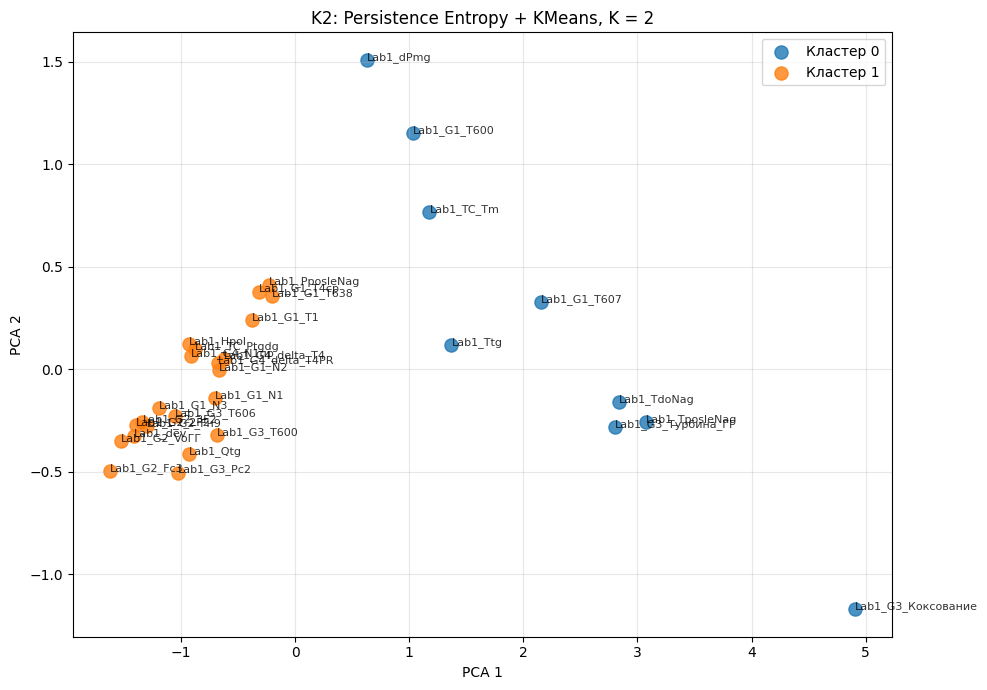

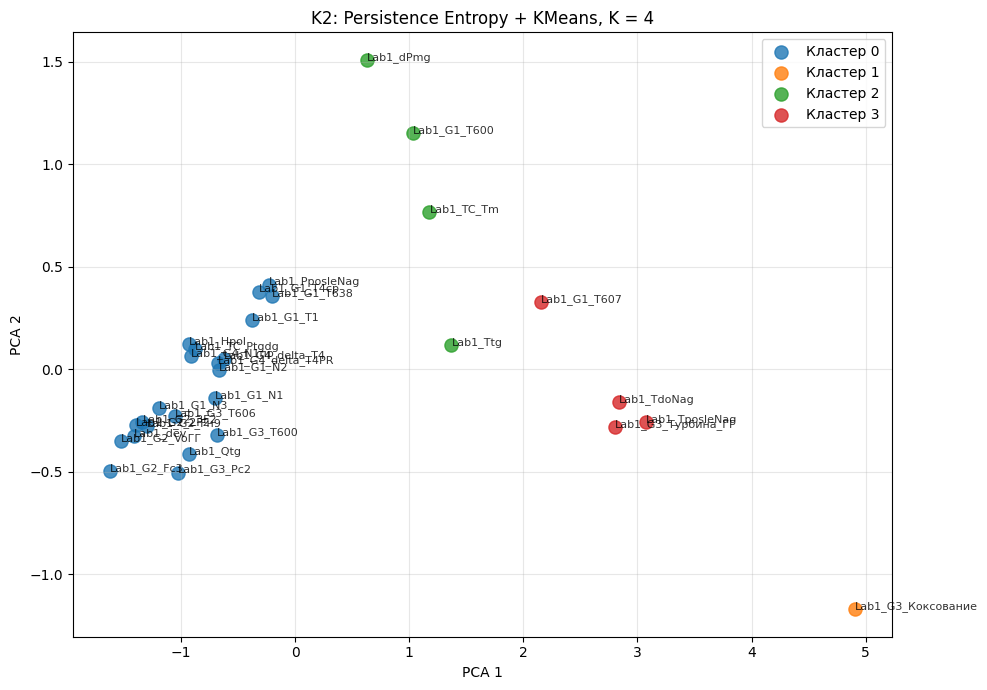

In [179]:
# ============================================================
# Визуализация K2-кластеризации через PCA
# Для K = 2 и K = 4
# ============================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. PCA-проекция Persistence Entropy-признаков в 2D
# ------------------------------------------------------------

pca_K2 = PCA(n_components=2, random_state=0)

X_entropy_pca = pca_K2.fit_transform(X_entropy_scaled)

k2_plot_df = pd.DataFrame({
    "column": builtin_entropy["column"],
    "PCA_1": X_entropy_pca[:, 0],
    "PCA_2": X_entropy_pca[:, 1]
})

k2_plot_df = k2_plot_df.merge(
    k2_comparison,
    on="column",
    how="left"
)

print("Доля объяснённой дисперсии PCA:")
print("PCA 1:", round(pca_K2.explained_variance_ratio_[0], 4))
print("PCA 2:", round(pca_K2.explained_variance_ratio_[1], 4))
print(
    "Суммарно:",
    round(pca_K2.explained_variance_ratio_[:2].sum(), 4)
)

display(k2_plot_df.head())


# ------------------------------------------------------------
# 2. Функция для визуализации кластеров
# ------------------------------------------------------------

def plot_k2_pca(dataframe, cluster_col, title):
    plt.figure(figsize=(10, 7))

    clusters = sorted(dataframe[cluster_col].dropna().unique())

    for cluster in clusters:
        subset = dataframe[dataframe[cluster_col] == cluster]

        plt.scatter(
            subset["PCA_1"],
            subset["PCA_2"],
            s=90,
            label=f"Кластер {cluster}",
            alpha=0.8
        )

        for _, row in subset.iterrows():
            plt.text(
                row["PCA_1"],
                row["PCA_2"],
                row["column"],
                fontsize=8,
                alpha=0.8
            )

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 3. Визуализация K = 2
# ------------------------------------------------------------

plot_k2_pca(
    k2_plot_df,
    "cluster_K2_K2_entropy_kmeans",
    "K2: Persistence Entropy + KMeans, K = 2"
)


# ------------------------------------------------------------
# 4. Визуализация K = 4
# ------------------------------------------------------------

plot_k2_pca(
    k2_plot_df,
    "cluster_K2_K4_entropy_kmeans",
    "K2: Persistence Entropy + KMeans, K = 4"
)

Сравнение результатов K1 и K2 показало, что два подхода выделяют разные аспекты сходства временных рядов. Кластеризация K1, основанная на расстояниях Вассерштейна между диаграммами персистентности, выявила небольшую группу рядов, существенно отличающихся от основной массы по полной топологической структуре. При увеличении числа кластеров эти ряды дополнительно разделились, причём некоторые признаки были выделены в одиночные кластеры, что указывает на их специфическое топологическое поведение.

Кластеризация K2, основанная на Persistence Entropy, дала другое разбиение: она группирует ряды не по полной форме диаграммы персистентности, а по обобщённой мере распределения топологических признаков. 

Таким образом, K1 и K2 не дублируют друг друга, а являются взаимодополняющими подходами. K1 позволяет анализировать различия в полной топологической структуре диаграмм персистентности, а K2 — сравнивать ряды по агрегированной характеристике их топологической сложности. В качестве основного результата для интерпретации топологических различий целесообразно использовать K1, а K2 рассматривать как дополнительную проверку устойчивости и обобщённой структуры кластеров.

По результатам межкластерного сравнения было установлено, что ряды, выделенные в отдельные группы методами K1 и K2, совпадают лишь частично. Кластеризация K1, основанная на расстояниях Вассерштейна между диаграммами персистентности, выделила ряды, отличающиеся по полной топологической структуре. Кластеризация K2, основанная на Persistence Entropy, выделила ряды, отличающиеся по обобщённой топологической сложности.

Единственным рядом, попавшим в отличающиеся группы в обоих подходах, является Lab1_dPmg. Это позволяет рассматривать его как наиболее устойчивого кандидата для дальнейшего поиска скрытых режимов. Дополнительно в качестве кандидатов можно рассматривать ряды, выделенные каждым методом отдельно: для K1 это Lab1_G2_Fc3, Lab1_G2_VoГГ, Lab1_G3_Pc2 и Lab1_Hpol, а для K2 — температурные и технологические признаки Lab1_G1_T600, Lab1_G1_T607, Lab1_G3_Коксование, Lab1_G3_Турбина_ГГ, Lab1_TC_Tm, Lab1_TdoNag, Lab1_TposleNag и Lab1_Ttg.

Таким образом, результаты кластеризации можно использовать как предварительный этап отбора признаков-кандидатов для поиска скрытых режимов. Ряды, которые формируют малые или одиночные кластеры, потенциально отражают отличающуюся динамику и требуют дальнейшего анализа во временной области.

##  Поиск скрытых режимов скользящими окнами

In [ ]:
# ============================================================
# Загрузка исходных временных рядов для анализа скрытых режимов
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Загружаем файл с исходными рядами
# ------------------------------------------------------------

DATA_PATH = Path("dataset_clean_31.csv")

source_df = pd.read_csv(DATA_PATH)

print("Исходный датафрейм загружен:")
print(DATA_PATH)
print("Форма source_df:", source_df.shape)

display(source_df.head())

# ------------------------------------------------------------
# 2. Ряды-кандидаты для поиска скрытых режимов
# ------------------------------------------------------------

k1_candidate_series = [
    "Lab1_G2_Fc3",
    "Lab1_G2_VoГГ",
    "Lab1_G3_Pc2",
    "Lab1_Hpol",
    "Lab1_dPmg",
]

k2_candidate_series = [
    "Lab1_G1_T600",
    "Lab1_G1_T607",
    "Lab1_G3_Коксование",
    "Lab1_G3_Турбина_ГГ",
    "Lab1_TC_Tm",
    "Lab1_TdoNag",
    "Lab1_TposleNag",
    "Lab1_Ttg",
    "Lab1_dPmg",
]

candidate_series = sorted(
    set(k1_candidate_series + k2_candidate_series)
)

# ------------------------------------------------------------
# 3. Проверяем, какие кандидаты есть в файле
# ------------------------------------------------------------

available_candidate_series = [
    col for col in candidate_series
    if col in source_df.columns
]

missing_candidate_series = [
    col for col in candidate_series
    if col not in source_df.columns
]

print("\nДоступные кандидаты:")
for col in available_candidate_series:
    print("-", col)

print("\nОтсутствующие кандидаты:")
for col in missing_candidate_series:
    print("-", col)

if len(available_candidate_series) == 0:
    raise ValueError(
        "В dataset_clean_31.csv нет ни одного ряда-кандидата. "
        "Проверь названия столбцов."
    )

candidate_series = available_candidate_series

# ------------------------------------------------------------
# 4. Создаём norm — таблицу нормализованных рядов
# ------------------------------------------------------------

norm = source_df[candidate_series].copy()

# Приводим к числам
norm = norm.apply(pd.to_numeric, errors="coerce")

# Убираем inf
norm = norm.replace([np.inf, -np.inf], np.nan)

# Z-нормализация
norm = (norm - norm.mean()) / norm.std(ddof=0)

candidate_series = [
    col for col in candidate_series
    if col in norm.columns
]

print("\nТаблица norm создана.")
print("Форма norm:", norm.shape)

display(norm.head())

Исходный датафрейм загружен:
dataset_clean_31.csv
Форма source_df: (1439, 32)


,TS,Lab1_G1_N3,Lab1_G2_Fн9,Lab1_G2_Fc3,Lab1_G3_Турбина_ГГ,Lab1_G1_N1,Lab1_G1_N2,Lab1_G2_3F2,Lab1_G1_T4ср,Lab1_G3_T606,...,Lab1_TC_Ptgdg,Lab1_dPmg,Lab1_Hpol,Lab1_TdoNag,Lab1_G1_T1,Lab1_G1_T600,Lab1_G1_T638,Lab1_G4_delta_T4PR,Lab1_G4_delta_T4,Lab1_TC_Tm
0,2022-12-02 18:59:59.999998+00:00,5000,0.19,0.31,0.0,8726,11490,0.60,662.7,0.000000,...,28.14,3.16,0.814,20.6,-16.1,67.1,79.8,12.050,-3.464,83.3
1,2022-12-02 19:00:59.999998+00:00,4993,0.21,0.29,0.0,8726,11489,0.59,662.4,0.012293,...,28.14,3.15,0.811,20.6,-16.4,67.0,79.8,11.954,-3.264,83.4
2,2022-12-02 19:01:59.999999+00:00,5001,0.16,0.35,0.0,8725,11493,0.64,663.1,0.048970,...,28.16,3.15,0.814,20.6,-16.0,67.0,79.8,12.034,-3.327,83.4
3,2022-12-02 19:02:59.999999+00:00,5011,0.19,0.26,0.0,8726,11493,0.63,663.0,0.011281,...,28.14,3.16,0.814,20.6,-16.1,67.1,79.8,12.287,-3.093,83.4
4,2022-12-02 19:04:00+00:00,5003,0.20,0.32,0.0,8728,11496,0.59,663.4,0.035681,...,28.14,3.16,0.814,20.6,-15.9,67.1,80.0,12.248,-3.096,83.5



Доступные кандидаты:
- Lab1_G1_T600
- Lab1_G1_T607
- Lab1_G2_Fc3
- Lab1_G2_VoГГ
- Lab1_G3_Pc2
- Lab1_G3_Коксование
- Lab1_G3_Турбина_ГГ
- Lab1_Hpol
- Lab1_TC_Tm
- Lab1_TdoNag
- Lab1_TposleNag
- Lab1_Ttg
- Lab1_dPmg

Отсутствующие кандидаты:

Таблица norm создана.
Форма norm: (1439, 13)


,Lab1_G1_T600,Lab1_G1_T607,Lab1_G2_Fc3,Lab1_G2_VoГГ,Lab1_G3_Pc2,Lab1_G3_Коксование,Lab1_G3_Турбина_ГГ,Lab1_Hpol,Lab1_TC_Tm,Lab1_TdoNag,Lab1_TposleNag,Lab1_Ttg,Lab1_dPmg
0,2.371288,0.648133,3.192097,-0.320004,-0.035663,-0.102731,-0.232833,-0.181367,2.756078,-0.191498,0.487033,0.383424,-0.831702
1,2.214401,0.648133,2.785563,-0.594863,-0.035663,-0.102731,-0.232833,-1.448298,2.915361,-0.191498,0.487033,0.383424,-1.754462
2,2.214401,0.648133,4.005165,-0.241473,-0.035663,-0.102731,-0.232833,-0.181367,2.915361,-0.191498,1.169447,0.383424,-1.754462
3,2.371288,0.648133,2.175762,0.003936,-0.035663,-0.102731,-0.232833,-0.181367,2.915361,-0.191498,1.169447,0.383424,-0.831702
4,2.371288,0.648133,3.395364,0.534020,1.971772,-0.102731,-0.232833,-0.181367,3.074644,-0.191498,0.487033,0.383424,-0.831702


In [186]:
# ============================================================
# Блок 1. Импорты, пути и загрузка файлов
# ============================================================

from pathlib import Path

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


DATA_PATH = Path("dataset_clean_31.csv")
EMBEDDING_PATH = Path("uniform_dimensions.csv")

OUTPUT_DIR = Path("persistence_vectors")
OUTPUT_DIR.mkdir(exist_ok=True)


def read_csv_safely(path):
    """
    Читает CSV с попыткой разных кодировок.
    """
    try:
        return pd.read_csv(path, encoding="utf-8")
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="cp1251")


source_df = read_csv_safely(DATA_PATH)

print("Исходный датафрейм загружен:")
print(DATA_PATH)
print("Форма source_df:", source_df.shape)

display(source_df.head())

Исходный датафрейм загружен:
dataset_clean_31.csv
Форма source_df: (1439, 32)


,TS,Lab1_G1_N3,Lab1_G2_Fн9,Lab1_G2_Fc3,Lab1_G3_Турбина_ГГ,Lab1_G1_N1,Lab1_G1_N2,Lab1_G2_3F2,Lab1_G1_T4ср,Lab1_G3_T606,...,Lab1_TC_Ptgdg,Lab1_dPmg,Lab1_Hpol,Lab1_TdoNag,Lab1_G1_T1,Lab1_G1_T600,Lab1_G1_T638,Lab1_G4_delta_T4PR,Lab1_G4_delta_T4,Lab1_TC_Tm
0,2022-12-02 18:59:59.999998+00:00,5000,0.19,0.31,0.0,8726,11490,0.60,662.7,0.000000,...,28.14,3.16,0.814,20.6,-16.1,67.1,79.8,12.050,-3.464,83.3
1,2022-12-02 19:00:59.999998+00:00,4993,0.21,0.29,0.0,8726,11489,0.59,662.4,0.012293,...,28.14,3.15,0.811,20.6,-16.4,67.0,79.8,11.954,-3.264,83.4
2,2022-12-02 19:01:59.999999+00:00,5001,0.16,0.35,0.0,8725,11493,0.64,663.1,0.048970,...,28.16,3.15,0.814,20.6,-16.0,67.0,79.8,12.034,-3.327,83.4
3,2022-12-02 19:02:59.999999+00:00,5011,0.19,0.26,0.0,8726,11493,0.63,663.0,0.011281,...,28.14,3.16,0.814,20.6,-16.1,67.1,79.8,12.287,-3.093,83.4
4,2022-12-02 19:04:00+00:00,5003,0.20,0.32,0.0,8728,11496,0.59,663.4,0.035681,...,28.14,3.16,0.814,20.6,-15.9,67.1,80.0,12.248,-3.096,83.5


In [187]:
# ============================================================
# Блок 2. Ряды-кандидаты для поиска скрытых режимов
# ============================================================

# Кандидаты из K1: ряды, попавшие в малые/отдельные кластеры
k1_candidate_series = [
    "Lab1_G2_Fc3",
    "Lab1_G2_VoГГ",
    "Lab1_G3_Pc2",
    "Lab1_Hpol",
    "Lab1_dPmg",
]

# Кандидаты из K2: ряды, выделенные по Persistence Entropy
k2_candidate_series = [
    "Lab1_G1_T600",
    "Lab1_G1_T607",
    "Lab1_G3_Коксование",
    "Lab1_G3_Турбина_ГГ",
    "Lab1_TC_Tm",
    "Lab1_TdoNag",
    "Lab1_TposleNag",
    "Lab1_Ttg",
    "Lab1_dPmg",
]

candidate_series = sorted(
    set(k1_candidate_series + k2_candidate_series)
)

print("Исходный список кандидатов:")
for col in candidate_series:
    print("-", col)

Исходный список кандидатов:
- Lab1_G1_T600
- Lab1_G1_T607
- Lab1_G2_Fc3
- Lab1_G2_VoГГ
- Lab1_G3_Pc2
- Lab1_G3_Коксование
- Lab1_G3_Турбина_ГГ
- Lab1_Hpol
- Lab1_TC_Tm
- Lab1_TdoNag
- Lab1_TposleNag
- Lab1_Ttg
- Lab1_dPmg


In [188]:
# ============================================================
# Блок 3. Проверка кандидатов и создание norm
# ============================================================

available_candidate_series = [
    col for col in candidate_series
    if col in source_df.columns
]

missing_candidate_series = [
    col for col in candidate_series
    if col not in source_df.columns
]

print("Доступные кандидаты в dataset_clean_31.csv:")
for col in available_candidate_series:
    print("-", col)

print("\nОтсутствующие кандидаты в dataset_clean_31.csv:")
for col in missing_candidate_series:
    print("-", col)

if len(available_candidate_series) == 0:
    raise ValueError(
        "В dataset_clean_31.csv нет ни одного ряда-кандидата. "
        "Проверь названия столбцов."
    )

candidate_series = available_candidate_series


# ------------------------------------------------------------
# Создание norm — нормализованных временных рядов
# ------------------------------------------------------------

norm = source_df[candidate_series].copy()

norm = norm.apply(pd.to_numeric, errors="coerce")
norm = norm.replace([np.inf, -np.inf], np.nan)

norm = norm.interpolate(limit_direction="both")
norm = norm.ffill().bfill()

norm = (norm - norm.mean()) / norm.std(ddof=0)

norm = norm.dropna(axis=1, how="all")

candidate_series = [
    col for col in candidate_series
    if col in norm.columns
]

print("\nТаблица norm создана.")
print("Форма norm:", norm.shape)

display(norm.head())

Доступные кандидаты в dataset_clean_31.csv:
- Lab1_G1_T600
- Lab1_G1_T607
- Lab1_G2_Fc3
- Lab1_G2_VoГГ
- Lab1_G3_Pc2
- Lab1_G3_Коксование
- Lab1_G3_Турбина_ГГ
- Lab1_Hpol
- Lab1_TC_Tm
- Lab1_TdoNag
- Lab1_TposleNag
- Lab1_Ttg
- Lab1_dPmg

Отсутствующие кандидаты в dataset_clean_31.csv:

Таблица norm создана.
Форма norm: (1439, 13)


,Lab1_G1_T600,Lab1_G1_T607,Lab1_G2_Fc3,Lab1_G2_VoГГ,Lab1_G3_Pc2,Lab1_G3_Коксование,Lab1_G3_Турбина_ГГ,Lab1_Hpol,Lab1_TC_Tm,Lab1_TdoNag,Lab1_TposleNag,Lab1_Ttg,Lab1_dPmg
0,2.371288,0.648133,3.192097,-0.320004,-0.035663,-0.102731,-0.232833,-0.181367,2.756078,-0.191498,0.487033,0.383424,-0.831702
1,2.214401,0.648133,2.785563,-0.594863,-0.035663,-0.102731,-0.232833,-1.448298,2.915361,-0.191498,0.487033,0.383424,-1.754462
2,2.214401,0.648133,4.005165,-0.241473,-0.035663,-0.102731,-0.232833,-0.181367,2.915361,-0.191498,1.169447,0.383424,-1.754462
3,2.371288,0.648133,2.175762,0.003936,-0.035663,-0.102731,-0.232833,-0.181367,2.915361,-0.191498,1.169447,0.383424,-0.831702
4,2.371288,0.648133,3.395364,0.534020,1.971772,-0.102731,-0.232833,-0.181367,3.074644,-0.191498,0.487033,0.383424,-0.831702


In [189]:
# ============================================================
# Блок 4. Загрузка параметров вложения и создание embedding_info
# ============================================================

uniform_dimensions = read_csv_safely(EMBEDDING_PATH)

print("Файл с параметрами вложения загружен:")
print(EMBEDDING_PATH)
print("Форма uniform_dimensions:", uniform_dimensions.shape)

display(uniform_dimensions.head())

required_cols = ["column", "tau", "dimension"]

missing_required_cols = [
    col for col in required_cols
    if col not in uniform_dimensions.columns
]

if missing_required_cols:
    raise ValueError(
        f"В uniform_dimensions.csv нет нужных столбцов: {missing_required_cols}"
    )


# ------------------------------------------------------------
# Создание embedding_info строго из uniform_dimensions.csv
# Без автозамены на значения по умолчанию
# ------------------------------------------------------------

embedding_info = {}

for _, row in uniform_dimensions.iterrows():
    col_name = row["column"]

    if col_name not in candidate_series:
        continue

    if col_name not in norm.columns:
        continue

    tau_value = row["tau"]
    dim_value = row["dimension"]

    if pd.isna(tau_value) or pd.isna(dim_value):
        continue

    tau_value = int(max(1, round(float(tau_value))))
    dim_value = int(max(2, round(float(dim_value))))

    embedding_info[col_name] = {
        "tau": tau_value,
        "dim": dim_value
    }

print("\nembedding_info создан из uniform_dimensions.csv.")
print("Количество рядов с параметрами:", len(embedding_info))

for col, params in embedding_info.items():
    print(col, params)

missing_embedding_candidates = [
    col for col in candidate_series
    if col not in embedding_info
]

print("\nКандидаты без параметров вложения:")
for col in missing_embedding_candidates:
    print("-", col)

candidate_series = [
    col for col in candidate_series
    if col in embedding_info
]

if len(candidate_series) == 0:
    raise ValueError(
        "Не осталось кандидатов с параметрами вложения из uniform_dimensions.csv."
    )

print("\nИтоговые кандидаты для анализа скрытых режимов:")
for col in candidate_series:
    print("-", col)

Файл с параметрами вложения загружен:
uniform_dimensions.csv
Форма uniform_dimensions: (31, 4)


,column,tau,dimension,dimension_method_type
0,Lab1_G1_N3,3,4,acf_fnn
1,Lab1_G2_Fн9,3,5,acf_fnn
2,Lab1_G2_Fc3,3,7,acf_fnn
3,Lab1_G1_N1,98,4,uzal_cost
4,Lab1_G1_N2,14,6,acf_fnn



embedding_info создан из uniform_dimensions.csv.
Количество рядов с параметрами: 13
Lab1_G2_Fc3 {'tau': 3, 'dim': 7}
Lab1_G2_VoГГ {'tau': 10, 'dim': 7}
Lab1_Ttg {'tau': 97, 'dim': 12}
Lab1_G3_Pc2 {'tau': 18, 'dim': 9}
Lab1_dPmg {'tau': 76, 'dim': 9}
Lab1_Hpol {'tau': 2, 'dim': 10}
Lab1_G1_T600 {'tau': 37, 'dim': 8}
Lab1_TC_Tm {'tau': 54, 'dim': 9}
Lab1_G3_Турбина_ГГ {'tau': 16, 'dim': 4}
Lab1_G1_T607 {'tau': 14, 'dim': 3}
Lab1_TposleNag {'tau': 2, 'dim': 3}
Lab1_G3_Коксование {'tau': 13, 'dim': 3}
Lab1_TdoNag {'tau': 4, 'dim': 4}

Кандидаты без параметров вложения:

Итоговые кандидаты для анализа скрытых режимов:
- Lab1_G1_T600
- Lab1_G1_T607
- Lab1_G2_Fc3
- Lab1_G2_VoГГ
- Lab1_G3_Pc2
- Lab1_G3_Коксование
- Lab1_G3_Турбина_ГГ
- Lab1_Hpol
- Lab1_TC_Tm
- Lab1_TdoNag
- Lab1_TposleNag
- Lab1_Ttg
- Lab1_dPmg


In [190]:
# ============================================================
# Блок 5. Вспомогательные функции
# ============================================================

def prepare_series(x):
    """
    Подготовка временного ряда:
    удаляются nan/inf, затем ряд приводится к среднему 0 и std 1.
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) == 0:
        return None

    std = x.std()

    if std == 0 or not np.isfinite(std):
        return None

    return (x - x.mean()) / std


def delay_embedding(x, m, tau):
    """
    Равномерное delay embedding:
    x(t) -> [x(t), x(t+tau), ..., x(t+(m-1)tau)]
    """
    x = np.asarray(x, dtype=float)

    m = int(m)
    tau = int(tau)

    n_vectors = len(x) - (m - 1) * tau

    if n_vectors <= 0:
        return np.empty((0, m))

    embedded = np.empty((n_vectors, m), dtype=float)

    for j in range(m):
        embedded[:, j] = x[j * tau : j * tau + n_vectors]

    return embedded


def subsample_cloud(cloud, max_points=200, random_state=42):
    """
    Уменьшение числа точек в облаке для ускорения TDA.
    """
    cloud = np.asarray(cloud)

    if len(cloud) <= max_points:
        return cloud

    rng = np.random.default_rng(random_state)
    idx = rng.choice(
        len(cloud),
        size=max_points,
        replace=False
    )

    return cloud[idx]


def stack_diagrams_by_homology(diagrams, homology_dims=(0, 1, 2)):
    """
    Приведение списка диаграмм к единому numpy-массиву для giotto-tda.

    PersistenceEntropy требует, чтобы в каждой гомологической
    размерности H0, H1, H2 у всех диаграмм было одинаковое число точек.

    Поэтому каждая диаграмма дополняется фиктивными тройками:
        [0, 0, h]

    где birth = death = 0, h — номер гомологической размерности.
    """

    cleaned_diagrams = []

    for diagram in diagrams:
        diagram = np.asarray(diagram, dtype=float)

        # Убираем nan/inf
        diagram = diagram[np.all(np.isfinite(diagram), axis=1)]

        # Оставляем только нужные размерности
        diagram = diagram[np.isin(diagram[:, 2], homology_dims)]

        cleaned_diagrams.append(diagram)

    max_points_by_dim = {}

    for h in homology_dims:
        max_points_by_dim[h] = max(
            np.sum(diagram[:, 2] == h)
            for diagram in cleaned_diagrams
        )

    padded_diagrams = []

    for diagram in cleaned_diagrams:
        parts = []

        for h in homology_dims:
            subdiagram = diagram[diagram[:, 2] == h]

            need = max_points_by_dim[h] - len(subdiagram)

            if need > 0:
                padding = np.column_stack([
                    np.zeros(need),
                    np.zeros(need),
                    np.full(need, h)
                ])

                subdiagram = np.vstack([subdiagram, padding])

            parts.append(subdiagram)

        padded_diagram = np.vstack(parts)
        padded_diagrams.append(padded_diagram)

    return np.stack(padded_diagrams)

In [191]:
# ============================================================
# Блок 6. Vietoris-Rips persistence и Persistence Entropy
# ============================================================

VR_windows = VietorisRipsPersistence(
    metric="euclidean",
    homology_dimensions=[0, 1, 2],
    collapse_edges=True,
    n_jobs=-1
)

entropy_transformer = PersistenceEntropy()

In [197]:
# ============================================================
# Блок 7. Функция анализа скрытых режимов одного ряда
# ============================================================

def analyze_hidden_regimes_tda(
    col,
    win=200,
    step=20,
    K_values=(2, 3, 4, 5, 6, 7),
    max_points=200,
    homology_dims=(0, 1, 2),
    save_results=True
):
    """
    Анализ скрытых режимов временного ряда скользящими окнами.

    Для каждого окна:
    1. строится фрагмент delay embedding;
    2. строится диаграмма персистентности;
    3. считается Persistence Entropy;
    4. окна кластеризуются методом KMeans.
    """

    if col not in norm.columns:
        print(f"[SKIP] {col}: нет такого столбца в norm")
        return None, None, None

    if col not in embedding_info:
        print(f"[SKIP] {col}: нет параметров embedding_info")
        return None, None, None

    x_raw = norm[col].to_numpy()
    x = prepare_series(x_raw)

    if x is None:
        print(f"[SKIP] {col}: ряд константный или некорректный")
        return None, None, None

    tau = int(embedding_info[col]["tau"])
    dim = int(embedding_info[col]["dim"])

    E = delay_embedding(x, dim, tau)

    if len(E) < win:
        print(f"[SKIP] {col}: облако слишком короткое для окна win={win}")
        print("Длина ряда:", len(x))
        print("Размер embedding:", E.shape)
        print("Параметры:", {"dim": dim, "tau": tau})
        return None, None, None

    starts = list(range(0, len(E) - win + 1, step))

    print("=" * 80)
    print(f"Анализ скрытых режимов для ряда: {col}")
    print(f"dim = {dim}, tau = {tau}")
    print(f"Длина ряда: {len(x)}")
    print(f"Размер embedding: {E.shape}")
    print(f"Окно: {win}, шаг: {step}")
    print(f"Количество окон: {len(starts)}")
    print("=" * 80)

    # --------------------------------------------------------
    # 1. Диаграммы персистентности для окон
    # --------------------------------------------------------

    window_diagrams = []

    for idx, start in enumerate(starts):
        window_cloud = E[start:start + win]

        window_cloud = subsample_cloud(
            window_cloud,
            max_points=max_points,
            random_state=42 + idx
        )

        diagram = VR_windows.fit_transform(
            window_cloud[None]
        )[0]

        window_diagrams.append(diagram)

    window_diagrams = stack_diagrams_by_homology(
        window_diagrams,
        homology_dims=homology_dims
    )

    # --------------------------------------------------------
    # 2. Persistence Entropy для окон
    # --------------------------------------------------------

    window_entropy = entropy_transformer.fit_transform(window_diagrams)

    window_entropy = np.nan_to_num(
        window_entropy,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    entropy_cols = [
        f"persistence_entropy_H{h}"
        for h in homology_dims
    ]

    entropy_cols = entropy_cols[:window_entropy.shape[1]]

    window_entropy_df = pd.DataFrame(
        window_entropy,
        columns=entropy_cols
    )

    window_entropy_df.insert(0, "window_start_embedding", starts)
    window_entropy_df["window_end_embedding"] = [
        start + win
        for start in starts
    ]

    window_entropy_df["window_start_raw"] = starts
    window_entropy_df["window_end_raw"] = [
        min(start + win + (dim - 1) * tau, len(x))
        for start in starts
    ]

    # --------------------------------------------------------
    # 3. Стандартизация энтропийных признаков окон
    # --------------------------------------------------------

    X_window_entropy = window_entropy_df[entropy_cols].to_numpy(dtype=float)

    scaler = StandardScaler()
    X_window_entropy_scaled = scaler.fit_transform(X_window_entropy)

    # --------------------------------------------------------
    # 4. Подбор K по silhouette
    # --------------------------------------------------------

    quality_rows = []

    for Kc in K_values:
        if Kc >= len(starts):
            continue

        kmeans = KMeans(
            n_clusters=Kc,
            n_init=10,
            random_state=0
        )

        labels = kmeans.fit_predict(X_window_entropy_scaled)

        if len(np.unique(labels)) > 1:
            sil = silhouette_score(
                X_window_entropy_scaled,
                labels
            )
        else:
            sil = np.nan

        quality_rows.append({
            "series": col,
            "K": Kc,
            "silhouette": sil
        })

    quality_df = pd.DataFrame(quality_rows)

    print("Качество кластеризации окон:")
    display(quality_df)

    if quality_df.empty or quality_df["silhouette"].isna().all():
        print(f"[SKIP] {col}: не удалось подобрать K")
        return None, None, None

    best_K = int(
        quality_df.loc[
            quality_df["silhouette"].idxmax(),
            "K"
        ]
    )

    print(f"Лучшее K для окон ряда {col} по silhouette: {best_K}")

    # --------------------------------------------------------
    # 5. Финальная кластеризация окон
    # --------------------------------------------------------

    final_kmeans = KMeans(
        n_clusters=best_K,
        n_init=10,
        random_state=0
    )

    window_labels = final_kmeans.fit_predict(X_window_entropy_scaled)

    regimes_df = pd.DataFrame({
        "series": col,
        "window_start_embedding": starts,
        "window_end_embedding": [start + win for start in starts],
        "window_start_raw": starts,
        "window_end_raw": [
            min(start + win + (dim - 1) * tau, len(x))
            for start in starts
        ],
        "regime": window_labels
    })

    regimes_df = pd.concat(
        [
            regimes_df,
            window_entropy_df[entropy_cols].reset_index(drop=True)
        ],
        axis=1
    )

    print("Размеры найденных режимов:")

    display(
        regimes_df["regime"]
        .value_counts()
        .sort_index()
        .rename_axis("regime")
        .reset_index(name="windows_count")
    )

    # --------------------------------------------------------
    # 6. Визуализация: раскраска временного ряда
    # --------------------------------------------------------

    plt.figure(figsize=(14, 4))

    plt.plot(
        x,
        color="lightgray",
        linewidth=1,
        label="нормализованный ряд"
    )

    for _, row in regimes_df.iterrows():
        plt.axvspan(
            row["window_start_raw"],
            row["window_end_raw"],
            color=plt.cm.tab10(int(row["regime"])),
            alpha=0.18
        )

    plt.title(
        f"{col}: скрытые режимы по TDA-окнам "
        f"(Persistence Entropy + KMeans, K={best_K})"
    )
    plt.xlabel("Индекс")
    plt.ylabel("Нормализованное значение")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 7. Визуализация Persistence Entropy окон
    # --------------------------------------------------------

    plt.figure(figsize=(12, 4))

    for entropy_col in entropy_cols:
        plt.plot(
            regimes_df["window_start_raw"],
            regimes_df[entropy_col],
            marker="o",
            linewidth=1,
            label=entropy_col
        )

    plt.title(f"{col}: Persistence Entropy по скользящим окнам")
    plt.xlabel("Начало окна")
    plt.ylabel("Persistence Entropy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 8. Сохранение результатов
    # --------------------------------------------------------

    if save_results:
        safe_col = (
            col.replace("/", "_")
               .replace("\\", "_")
               .replace(":", "_")
               .replace(" ", "_")
        )

        regimes_path = OUTPUT_DIR / f"hidden_regimes_{safe_col}.csv"
        quality_path = OUTPUT_DIR / f"hidden_regimes_quality_{safe_col}.csv"

        regimes_df.to_csv(regimes_path, index=False)
        quality_df.to_csv(quality_path, index=False)

        print("Режимы сохранены:")
        print(regimes_path)

        print("Качество K сохранено:")
        print(quality_path)

    return regimes_df, quality_df, window_entropy_df

Цвет показывает, к какому кластеру отнесено окно. Если фон одного цвета держится долго, значит на этом участке окна имеют похожую топологическую структуру.

Анализ скрытых режимов для ряда: Lab1_dPmg
dim = 9, tau = 76
Длина ряда: 1439
Размер embedding: (831, 9)
Окно: 200, шаг: 20
Количество окон: 32
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_dPmg,2,0.474605
1,Lab1_dPmg,3,0.563233
2,Lab1_dPmg,4,0.461403


Лучшее K для окон ряда Lab1_dPmg по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,13
1,1,13
2,2,6


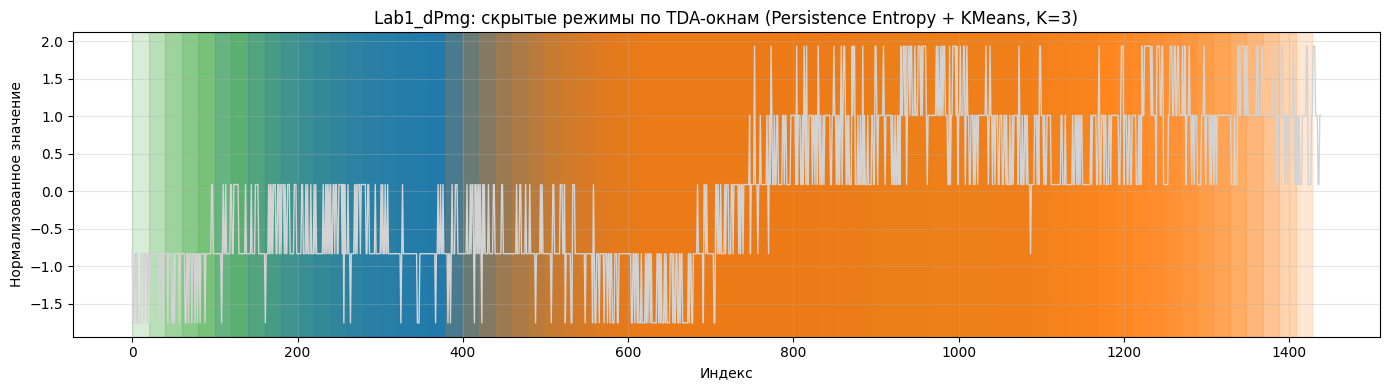

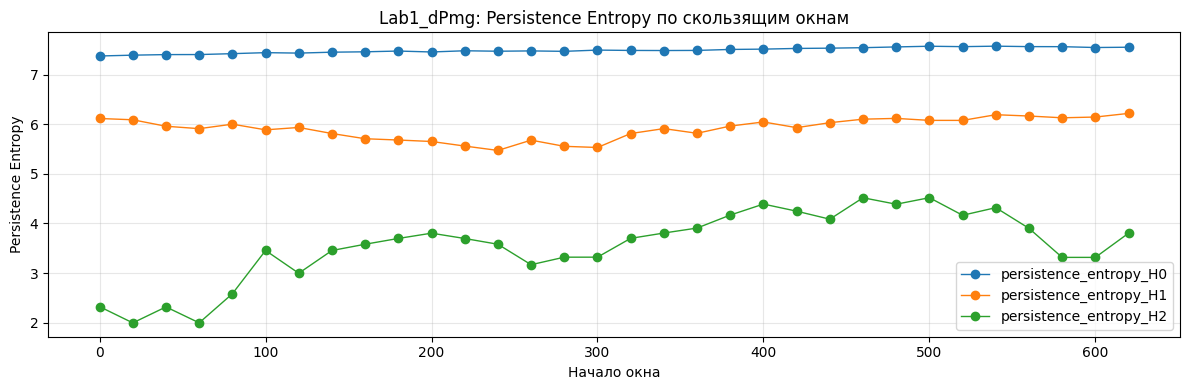

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_dPmg.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_dPmg.csv


In [198]:
# ============================================================
# Блок 8. Тестовый запуск на одном ряде
# ============================================================

test_col = "Lab1_dPmg"

regimes_df, quality_df, entropy_df = analyze_hidden_regimes_tda(
    col=test_col,
    win=200,
    step=20,
    K_values=(2, 3, 4),
    max_points=200,
    save_results=True
)

Анализ скрытых режимов для ряда: Lab1_G1_T600
dim = 8, tau = 37
Длина ряда: 1439
Размер embedding: (1180, 8)
Окно: 200, шаг: 20
Количество окон: 50
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G1_T600,2,0.351247
1,Lab1_G1_T600,3,0.447911
2,Lab1_G1_T600,4,0.473541


Лучшее K для окон ряда Lab1_G1_T600 по silhouette: 4
Размеры найденных режимов:


,regime,windows_count
0,0,10
1,1,21
2,2,8
3,3,11


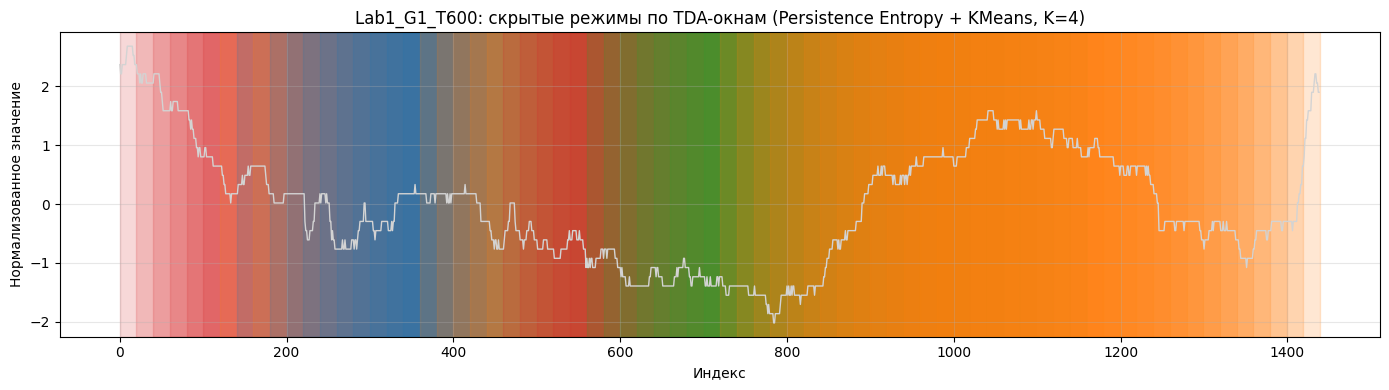

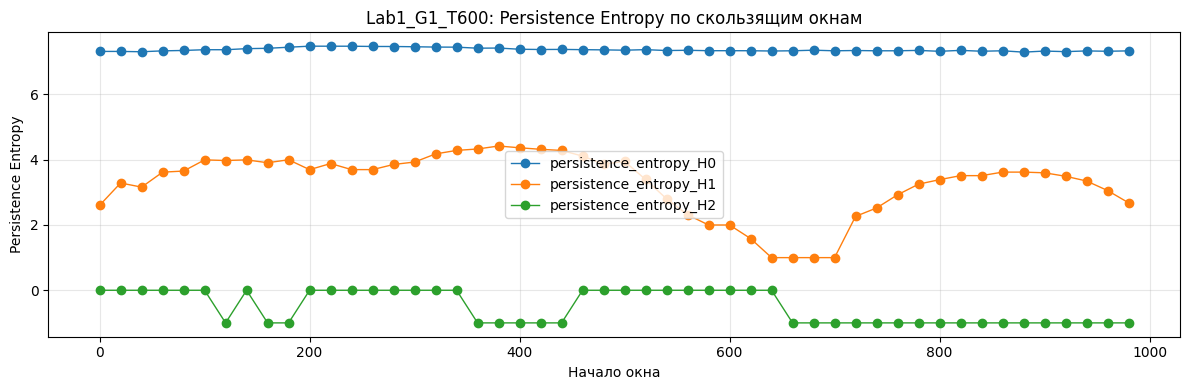

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G1_T600.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G1_T600.csv
Анализ скрытых режимов для ряда: Lab1_G1_T607
dim = 3, tau = 14
Длина ряда: 1439
Размер embedding: (1411, 3)
Окно: 200, шаг: 20
Количество окон: 61
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G1_T607,2,0.524265
1,Lab1_G1_T607,3,0.623030
2,Lab1_G1_T607,4,0.604822


Лучшее K для окон ряда Lab1_G1_T607 по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,39
1,1,17
2,2,5


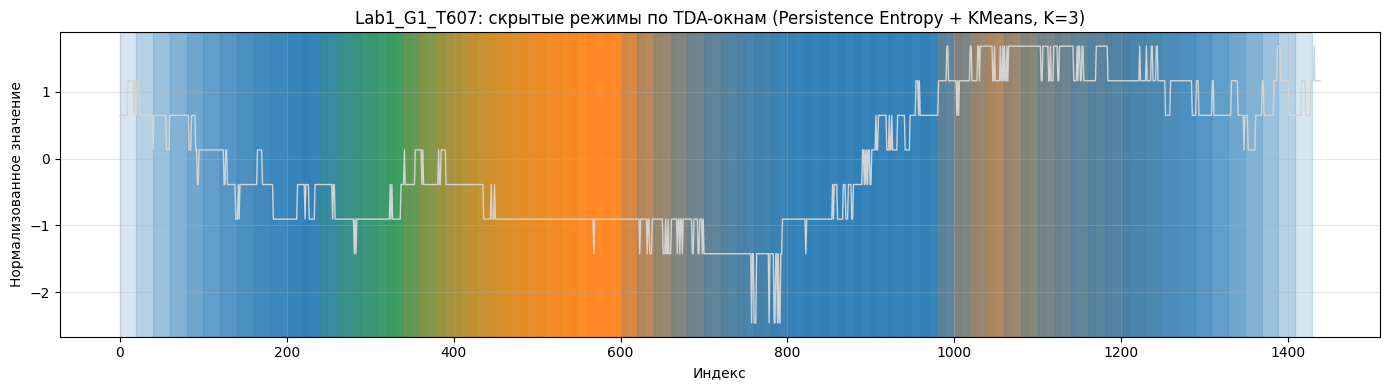

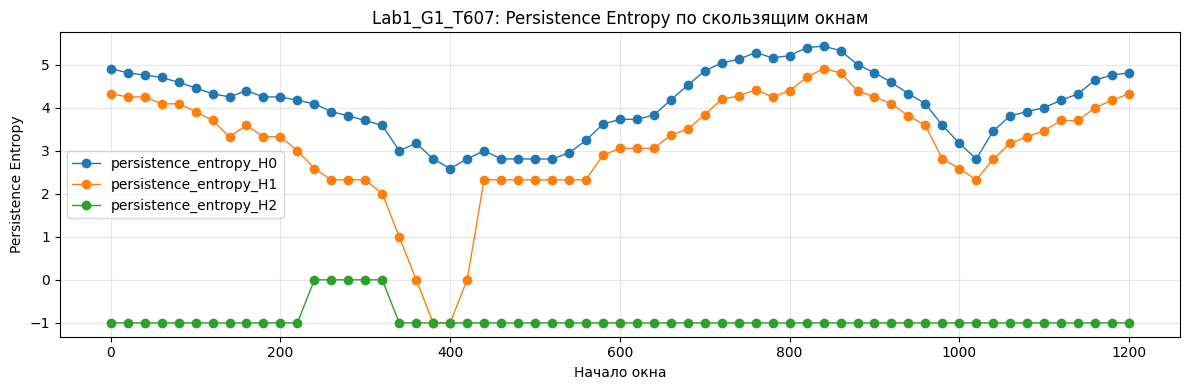

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G1_T607.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G1_T607.csv
Анализ скрытых режимов для ряда: Lab1_G2_Fc3
dim = 7, tau = 3
Длина ряда: 1439
Размер embedding: (1421, 7)
Окно: 200, шаг: 20
Количество окон: 62
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G2_Fc3,2,0.445177
1,Lab1_G2_Fc3,3,0.448810
2,Lab1_G2_Fc3,4,0.422510


Лучшее K для окон ряда Lab1_G2_Fc3 по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,5
1,1,31
2,2,26


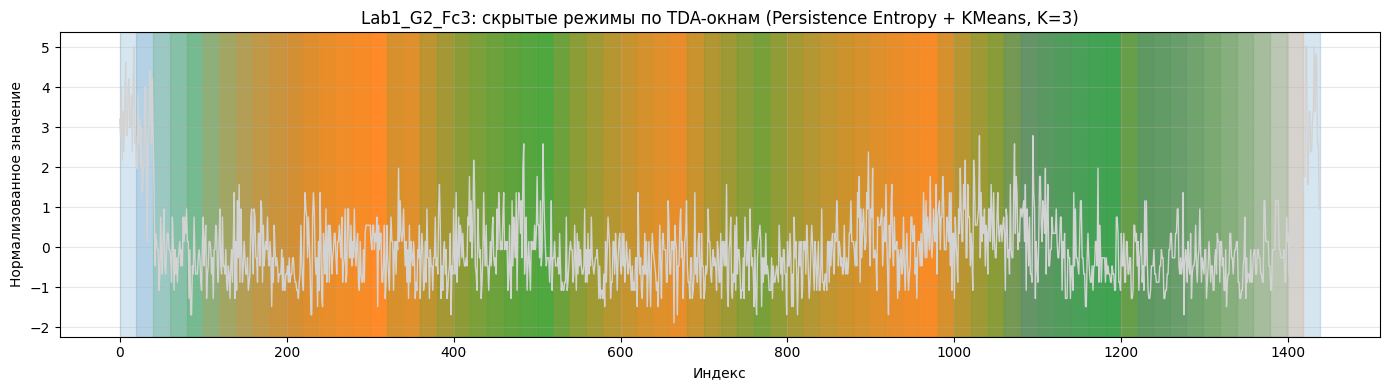

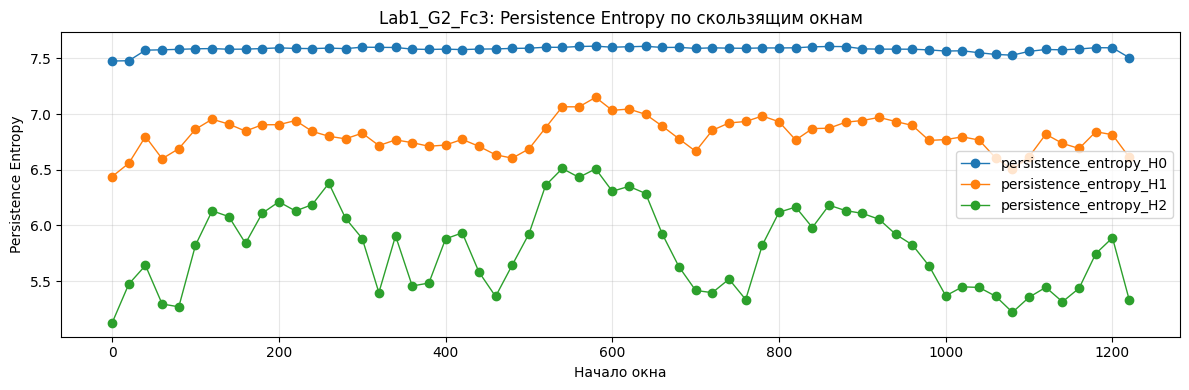

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G2_Fc3.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G2_Fc3.csv
Анализ скрытых режимов для ряда: Lab1_G2_VoГГ
dim = 7, tau = 10
Длина ряда: 1439
Размер embedding: (1379, 7)
Окно: 200, шаг: 20
Количество окон: 59
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G2_VoГГ,2,0.412488
1,Lab1_G2_VoГГ,3,0.458613
2,Lab1_G2_VoГГ,4,0.432164


Лучшее K для окон ряда Lab1_G2_VoГГ по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,27
1,1,26
2,2,6


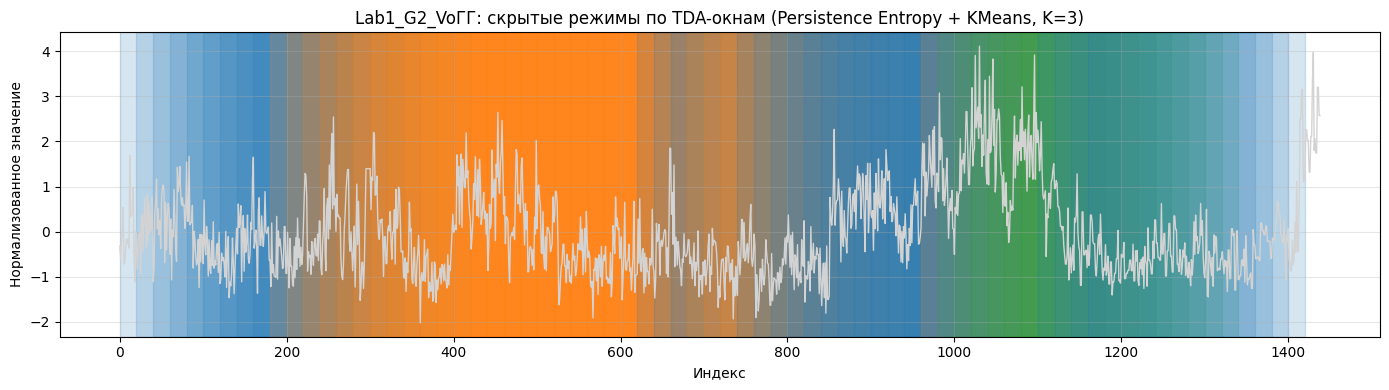

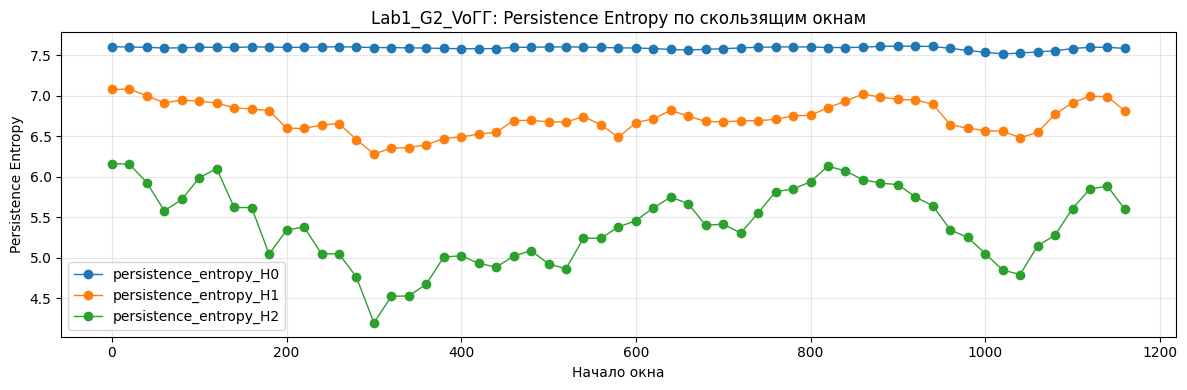

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G2_VoГГ.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G2_VoГГ.csv
Анализ скрытых режимов для ряда: Lab1_G3_Pc2
dim = 9, tau = 18
Длина ряда: 1439
Размер embedding: (1295, 9)
Окно: 200, шаг: 20
Количество окон: 55
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G3_Pc2,2,0.537000
1,Lab1_G3_Pc2,3,0.428201
2,Lab1_G3_Pc2,4,0.423316


Лучшее K для окон ряда Lab1_G3_Pc2 по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,21
1,1,34


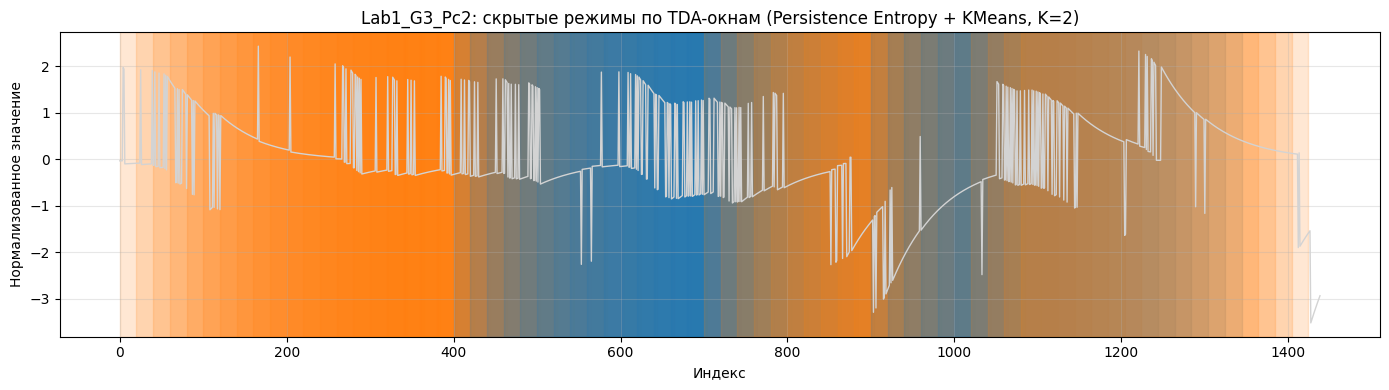

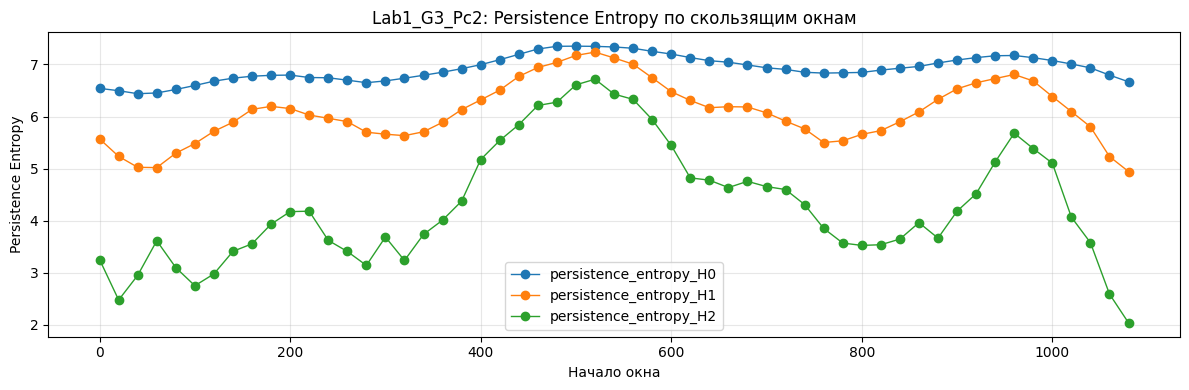

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G3_Pc2.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G3_Pc2.csv
Анализ скрытых режимов для ряда: Lab1_G3_Коксование
dim = 3, tau = 13
Длина ряда: 1439
Размер embedding: (1413, 3)
Окно: 200, шаг: 20
Количество окон: 61
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G3_Коксование,2,0.962694
1,Lab1_G3_Коксование,3,0.975689
2,Lab1_G3_Коксование,4,0.962163


Лучшее K для окон ряда Lab1_G3_Коксование по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,49
1,1,10
2,2,2


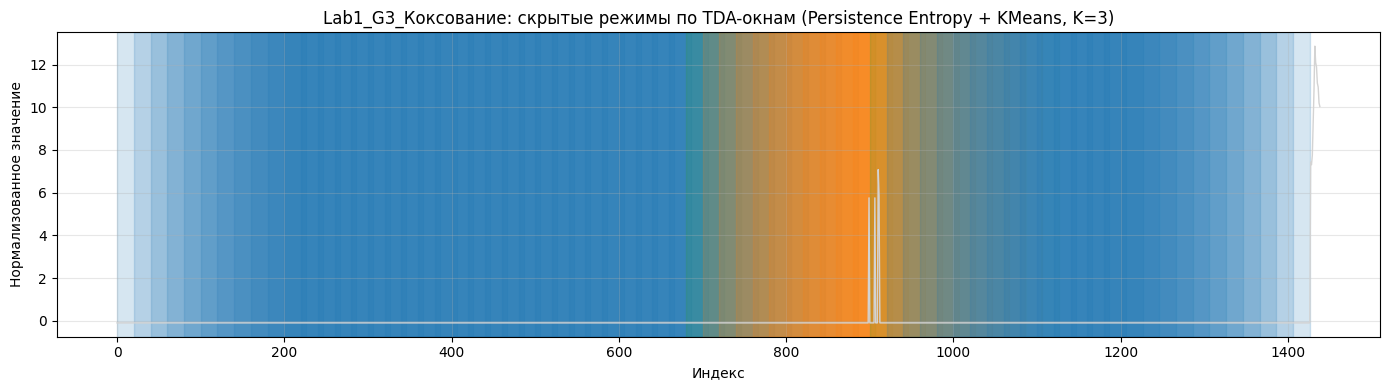

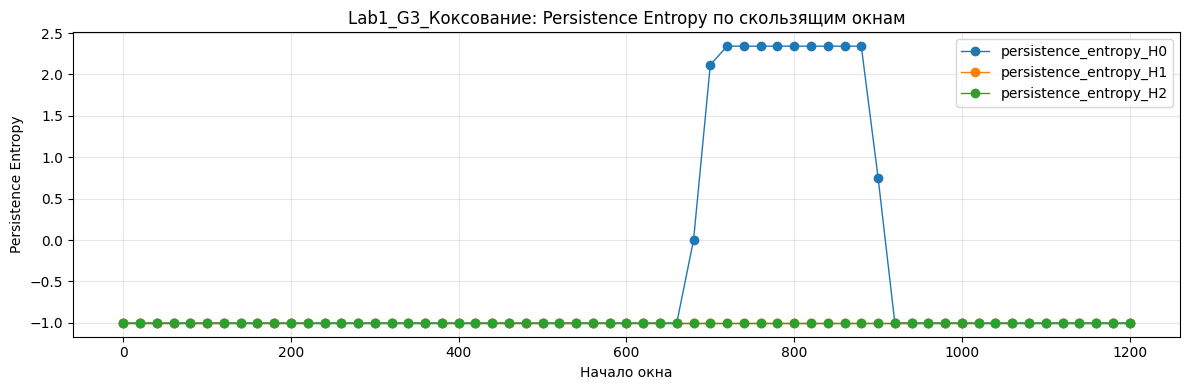

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G3_Коксование.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G3_Коксование.csv
Анализ скрытых режимов для ряда: Lab1_G3_Турбина_ГГ
dim = 4, tau = 16
Длина ряда: 1439
Размер embedding: (1391, 4)
Окно: 200, шаг: 20
Количество окон: 60
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G3_Турбина_ГГ,2,0.503080
1,Lab1_G3_Турбина_ГГ,3,0.664206
2,Lab1_G3_Турбина_ГГ,4,0.778130


Лучшее K для окон ряда Lab1_G3_Турбина_ГГ по silhouette: 4
Размеры найденных режимов:


,regime,windows_count
0,0,18
1,1,28
2,2,10
3,3,4


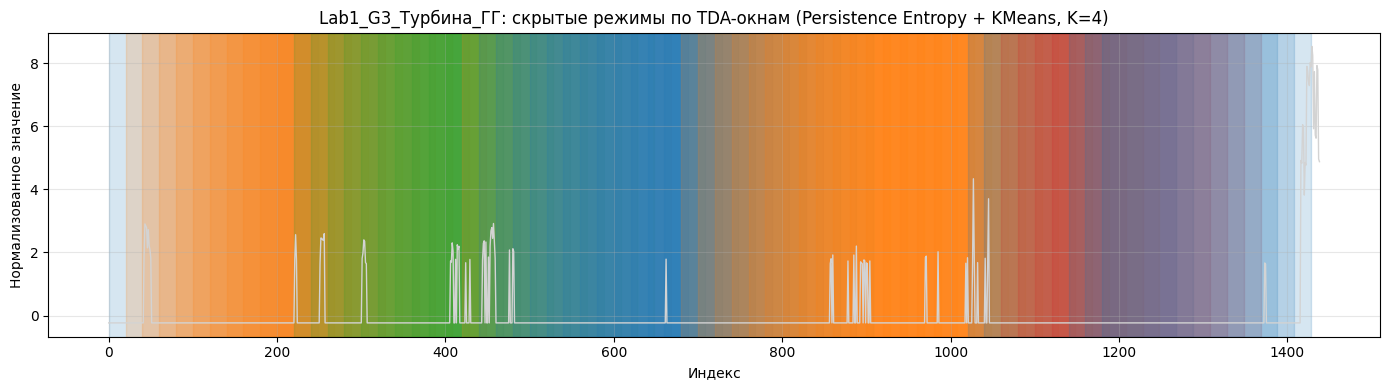

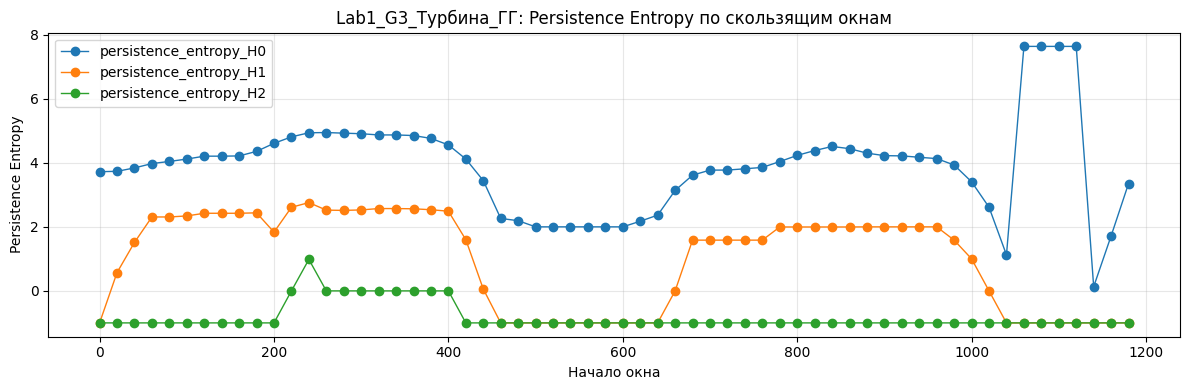

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G3_Турбина_ГГ.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G3_Турбина_ГГ.csv
Анализ скрытых режимов для ряда: Lab1_Hpol
dim = 10, tau = 2
Длина ряда: 1439
Размер embedding: (1421, 10)
Окно: 200, шаг: 20
Количество окон: 62
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_Hpol,2,0.474589
1,Lab1_Hpol,3,0.427129
2,Lab1_Hpol,4,0.448231


Лучшее K для окон ряда Lab1_Hpol по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,28
1,1,34


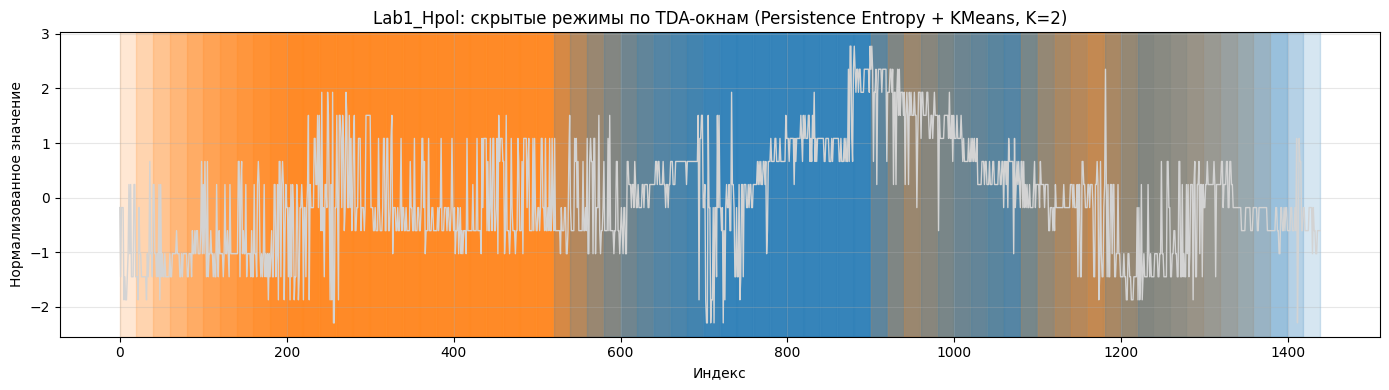

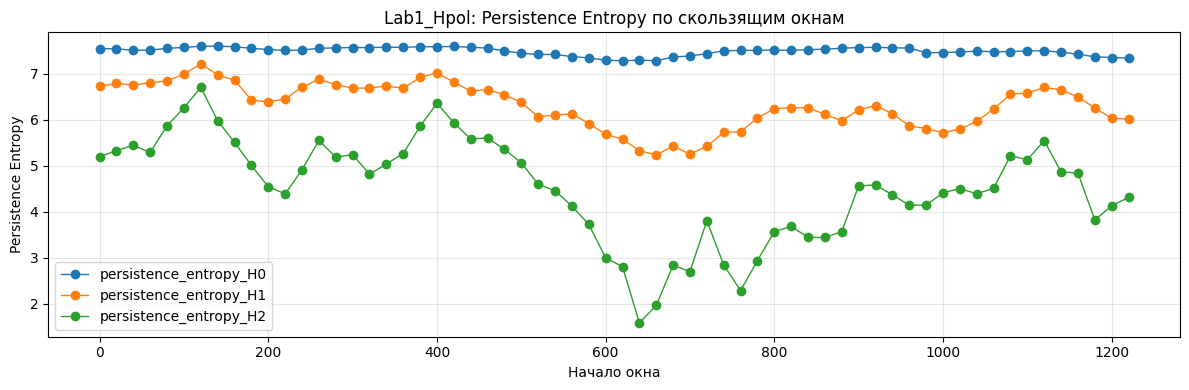

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_Hpol.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_Hpol.csv
Анализ скрытых режимов для ряда: Lab1_TC_Tm
dim = 9, tau = 54
Длина ряда: 1439
Размер embedding: (1007, 9)
Окно: 200, шаг: 20
Количество окон: 41
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_TC_Tm,2,0.561302
1,Lab1_TC_Tm,3,0.576234
2,Lab1_TC_Tm,4,0.563109


Лучшее K для окон ряда Lab1_TC_Tm по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,23
1,1,13
2,2,5


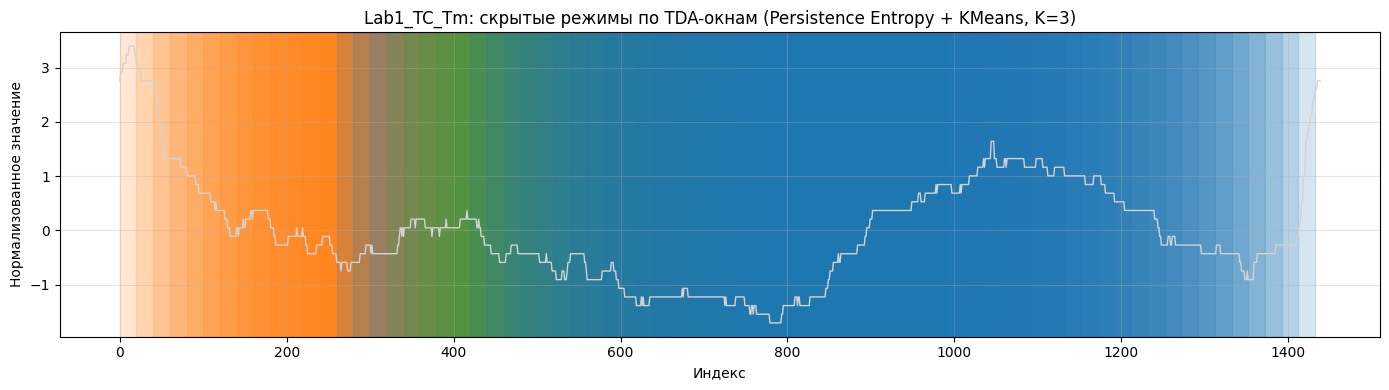

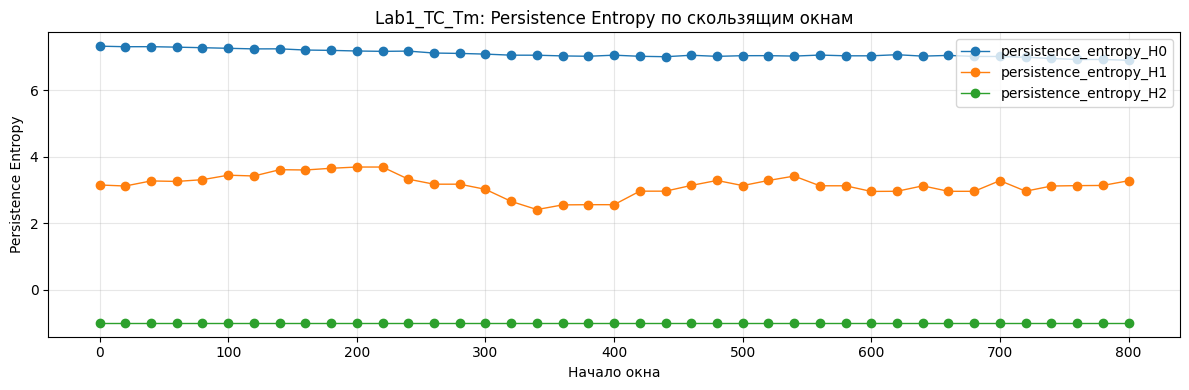

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_TC_Tm.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_TC_Tm.csv
Анализ скрытых режимов для ряда: Lab1_TdoNag
dim = 4, tau = 4
Длина ряда: 1439
Размер embedding: (1427, 4)
Окно: 200, шаг: 20
Количество окон: 62
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_TdoNag,2,0.768756
1,Lab1_TdoNag,3,0.675067
2,Lab1_TdoNag,4,0.737564


Лучшее K для окон ряда Lab1_TdoNag по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,50
1,1,12


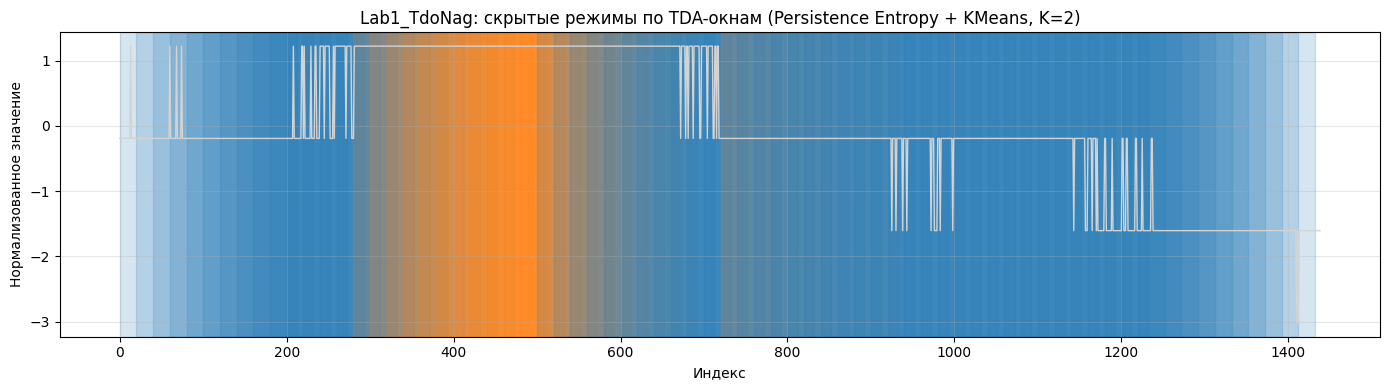

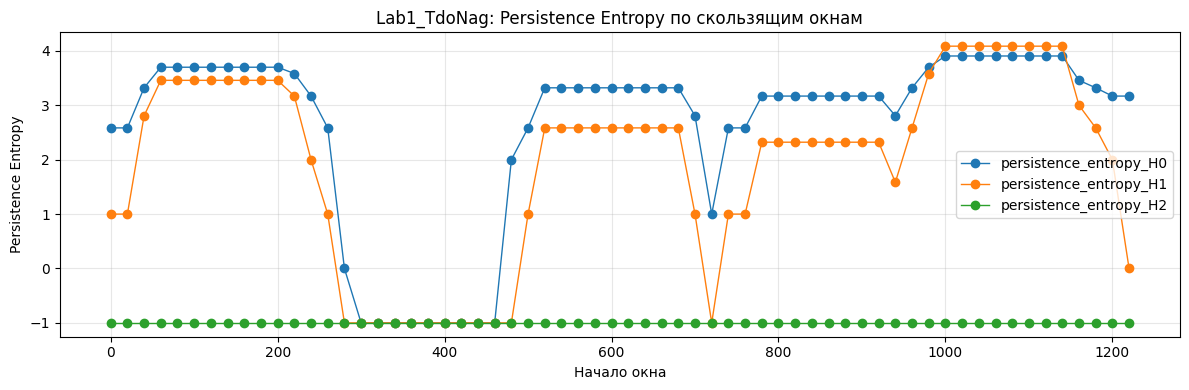

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_TdoNag.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_TdoNag.csv
Анализ скрытых режимов для ряда: Lab1_TposleNag
dim = 3, tau = 2
Длина ряда: 1439
Размер embedding: (1435, 3)
Окно: 200, шаг: 20
Количество окон: 62
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_TposleNag,2,0.848142
1,Lab1_TposleNag,3,0.871407
2,Lab1_TposleNag,4,0.777295


Лучшее K для окон ряда Lab1_TposleNag по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,54
1,1,5
2,2,3


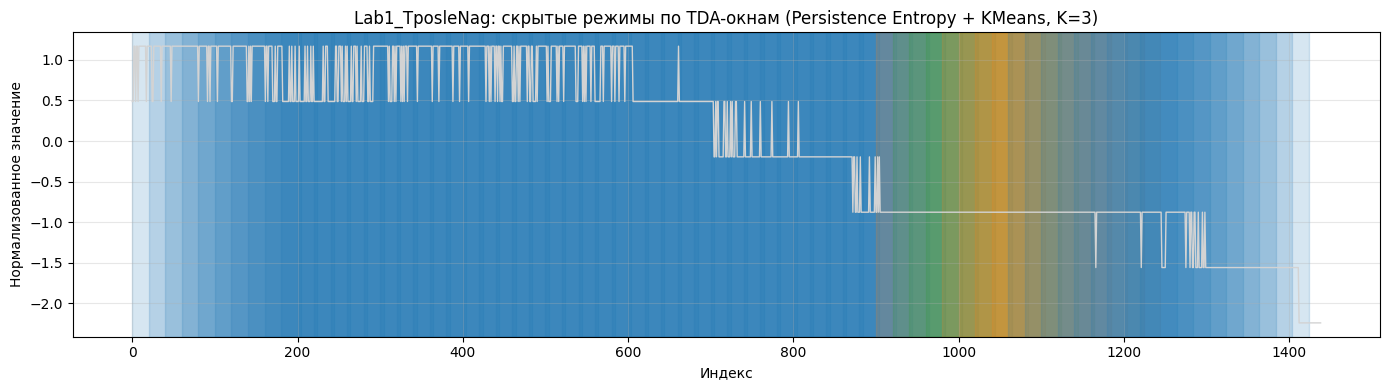

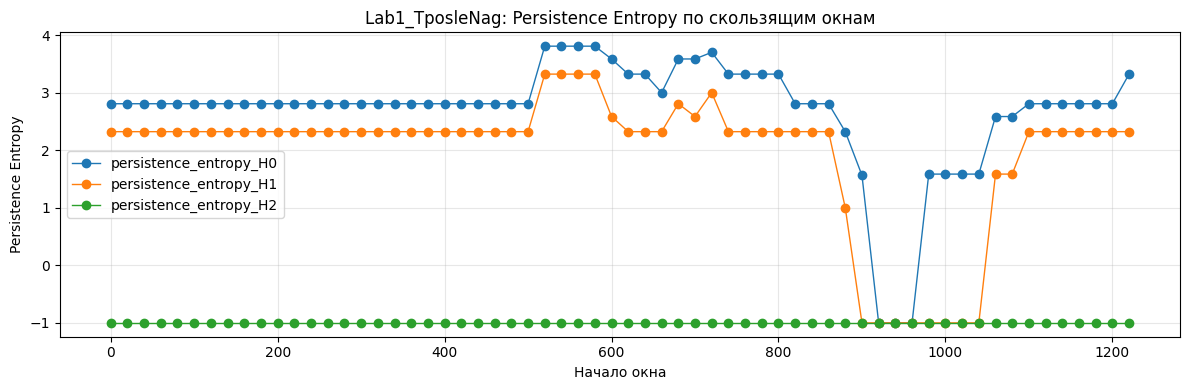

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_TposleNag.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_TposleNag.csv
Анализ скрытых режимов для ряда: Lab1_Ttg
dim = 12, tau = 97
Длина ряда: 1439
Размер embedding: (372, 12)
Окно: 200, шаг: 20
Количество окон: 9
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_Ttg,2,0.445315
1,Lab1_Ttg,3,0.530888
2,Lab1_Ttg,4,0.447228


Лучшее K для окон ряда Lab1_Ttg по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,4
1,1,4
2,2,1


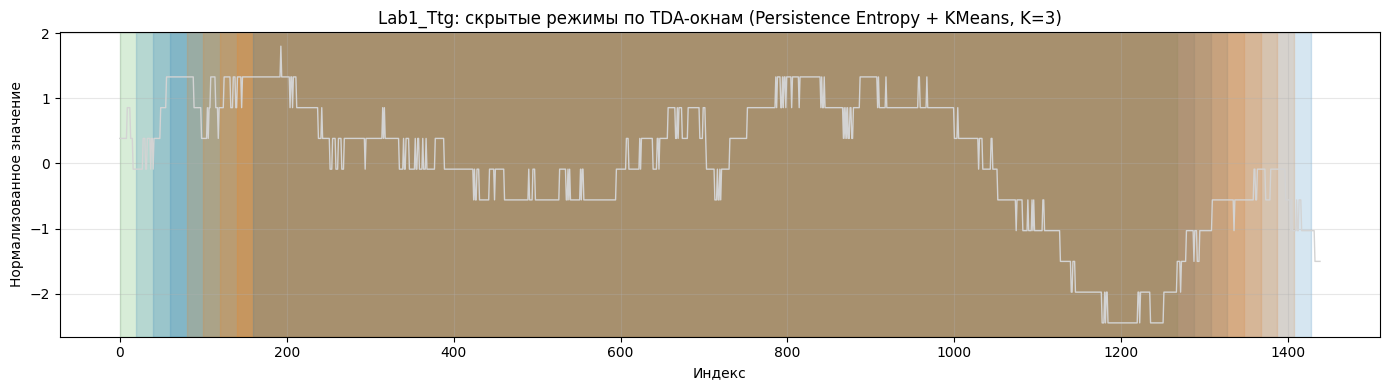

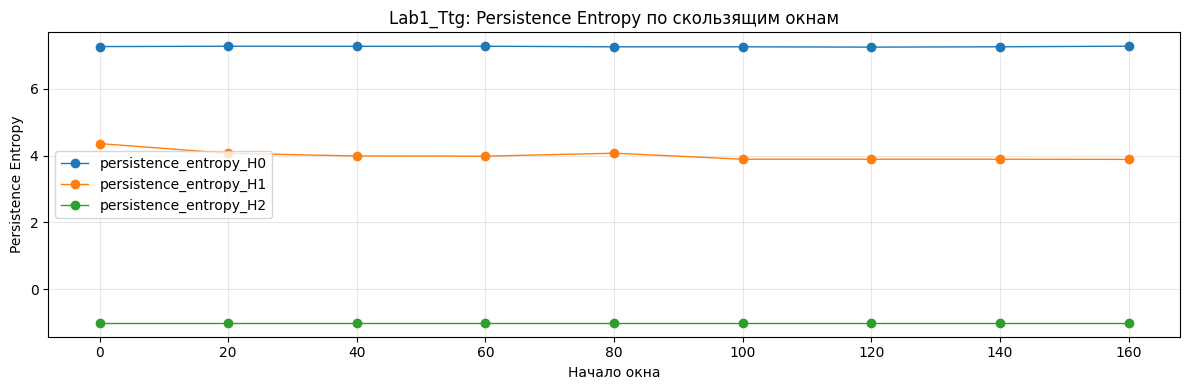

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_Ttg.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_Ttg.csv
Анализ скрытых режимов для ряда: Lab1_dPmg
dim = 9, tau = 76
Длина ряда: 1439
Размер embedding: (831, 9)
Окно: 200, шаг: 20
Количество окон: 32
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_dPmg,2,0.474605
1,Lab1_dPmg,3,0.563233
2,Lab1_dPmg,4,0.461403


Лучшее K для окон ряда Lab1_dPmg по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,13
1,1,13
2,2,6


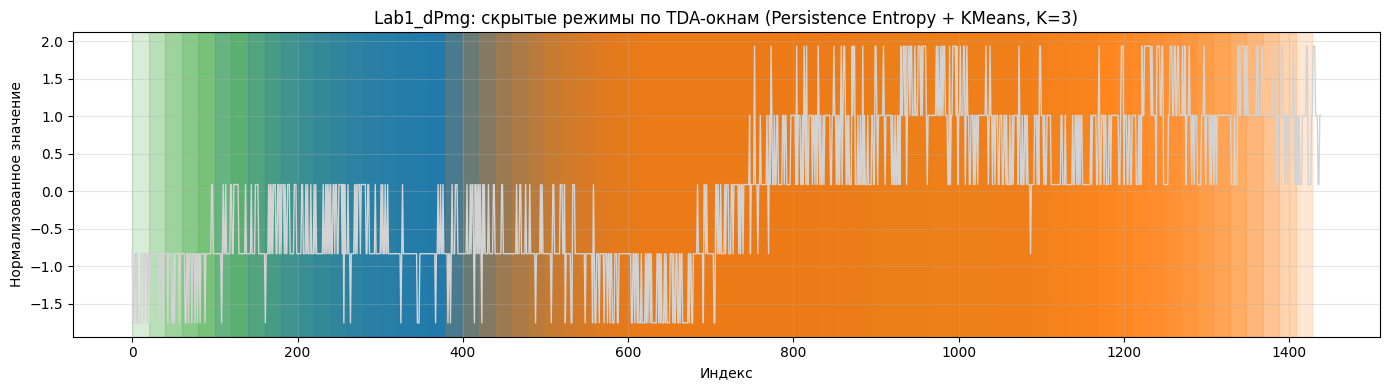

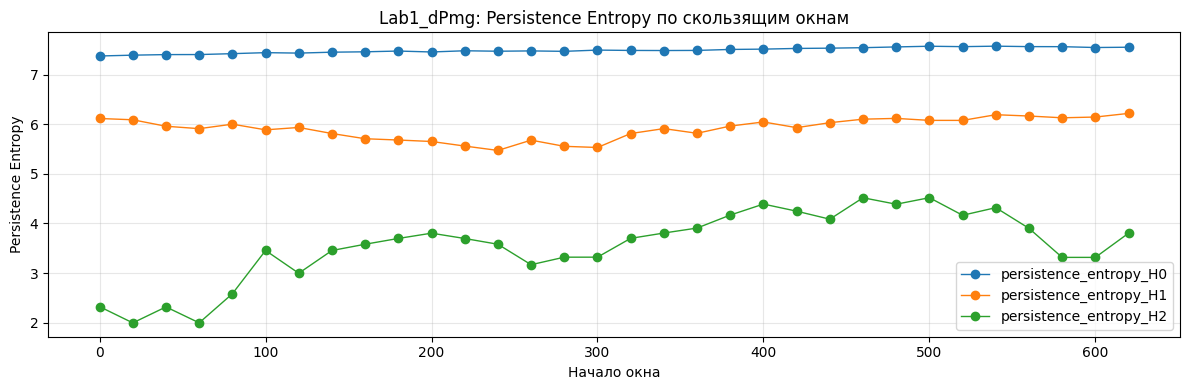

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_dPmg.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_dPmg.csv


In [199]:
# ============================================================
# Блок 9. Запуск анализа для всех кандидатов
# ============================================================

all_regimes = []
all_regime_quality = []

for col in candidate_series:
    regimes_df, quality_df, entropy_df = analyze_hidden_regimes_tda(
        col=col,
        win=200,
        step=20,
        K_values=(2, 3, 4),
        max_points=200,
        save_results=True
    )

    if regimes_df is not None:
        all_regimes.append(regimes_df)

    if quality_df is not None:
        all_regime_quality.append(quality_df)

Уже выбранные кандидаты, которые исключаем:
- Lab1_G1_T600
- Lab1_G1_T607
- Lab1_G2_Fc3
- Lab1_G2_VoГГ
- Lab1_G3_Pc2
- Lab1_G3_Коксование
- Lab1_G3_Турбина_ГГ
- Lab1_Hpol
- Lab1_TC_Tm
- Lab1_TdoNag
- Lab1_TposleNag
- Lab1_Ttg
- Lab1_dPmg

Остальные ряды для анализа:
- Lab1_G1_N3
- Lab1_G2_Fн9
- Lab1_G1_N1
- Lab1_G1_N2
- Lab1_G2_3F2
- Lab1_G1_T4ср
- Lab1_G3_T606
- Lab1_Qtg
- Lab1_G2_2F2
- Lab1_G3_T600
- Lab1_G4_N1пр
- Lab1_PposleNag
- Lab1_dev
- Lab1_TC_Ptgdg
- Lab1_G1_T1
- Lab1_G1_T638
- Lab1_G4_delta_T4PR
- Lab1_G4_delta_T4

Количество остальных рядов: 18

Таблица norm_other создана.
Форма norm_other: (1439, 18)


,Lab1_G1_N3,Lab1_G2_Fн9,Lab1_G1_N1,Lab1_G1_N2,Lab1_G2_3F2,Lab1_G1_T4ср,Lab1_G3_T606,Lab1_Qtg,Lab1_G2_2F2,Lab1_G3_T600,Lab1_G4_N1пр,Lab1_PposleNag,Lab1_dev,Lab1_TC_Ptgdg,Lab1_G1_T1,Lab1_G1_T638,Lab1_G4_delta_T4PR,Lab1_G4_delta_T4
0,-0.117264,3.153097,3.835586,3.837560,1.874375,3.790768,0.183770,4.107364,-0.719987,0.173268,0.412861,1.26417,-0.172143,-1.957059,3.146460,2.913426,1.705935,0.948379
1,-1.612451,3.929369,3.835586,3.813899,1.645097,3.746608,0.332345,4.062742,-1.704301,-0.133183,0.472254,1.26417,-1.698553,-1.957059,2.997352,2.913426,1.637614,1.070590
2,0.096334,1.988690,3.801734,3.908542,2.791487,3.849647,0.775613,3.839634,-0.719987,-0.128118,0.431834,1.26417,-1.916611,-1.593208,3.196162,2.913426,1.694548,1.032094
3,2.232316,3.153097,3.835586,3.908542,2.562209,3.834927,0.320106,3.884256,-0.438754,0.183315,0.408737,1.26417,-1.916611,-1.957059,3.146460,2.913426,1.874600,1.175080
4,0.523531,3.541233,3.903291,3.979524,1.645097,3.893807,0.615002,4.196607,-1.423068,0.183149,0.422760,1.26417,-1.044377,-1.957059,3.245865,3.283895,1.846845,1.173247



embedding_info_other создан.
Количество рядов с параметрами: 18
Lab1_G1_N3 {'tau': 3, 'dim': 4}
Lab1_G2_Fн9 {'tau': 3, 'dim': 5}
Lab1_G1_N1 {'tau': 98, 'dim': 4}
Lab1_G1_N2 {'tau': 14, 'dim': 6}
Lab1_G2_3F2 {'tau': 3, 'dim': 5}
Lab1_G1_T4ср {'tau': 51, 'dim': 5}
Lab1_G3_T606 {'tau': 24, 'dim': 9}
Lab1_Qtg {'tau': 19, 'dim': 3}
Lab1_G2_2F2 {'tau': 2, 'dim': 6}
Lab1_G3_T600 {'tau': 22, 'dim': 8}
Lab1_G4_N1пр {'tau': 4, 'dim': 6}
Lab1_PposleNag {'tau': 60, 'dim': 5}
Lab1_dev {'tau': 4, 'dim': 5}
Lab1_TC_Ptgdg {'tau': 14, 'dim': 7}
Lab1_G1_T1 {'tau': 33, 'dim': 6}
Lab1_G1_T638 {'tau': 12, 'dim': 7}
Lab1_G4_delta_T4PR {'tau': 28, 'dim': 5}
Lab1_G4_delta_T4 {'tau': 18, 'dim': 6}

Остальные ряды без параметров вложения:

Итоговые остальные ряды для анализа:
- Lab1_G1_N3
- Lab1_G2_Fн9
- Lab1_G1_N1
- Lab1_G1_N2
- Lab1_G2_3F2
- Lab1_G1_T4ср
- Lab1_G3_T606
- Lab1_Qtg
- Lab1_G2_2F2
- Lab1_G3_T600
- Lab1_G4_N1пр
- Lab1_PposleNag
- Lab1_dev
- Lab1_TC_Ptgdg
- Lab1_G1_T1
- Lab1_G1_T638
- Lab1_G4_delt

,series,K,silhouette
0,Lab1_G1_N3,2,0.414570
1,Lab1_G1_N3,3,0.284499
2,Lab1_G1_N3,4,0.297063


Лучшее K для окон ряда Lab1_G1_N3 по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,40
1,1,22


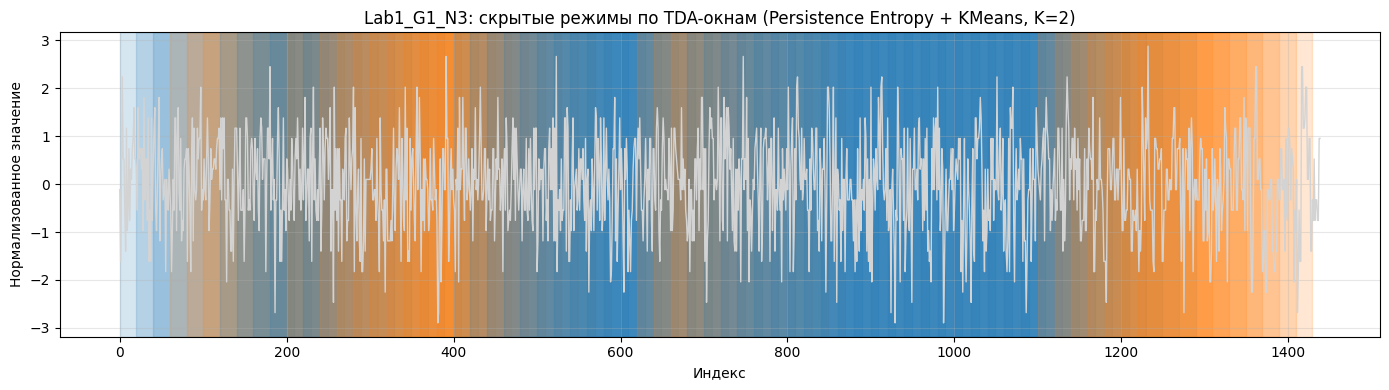

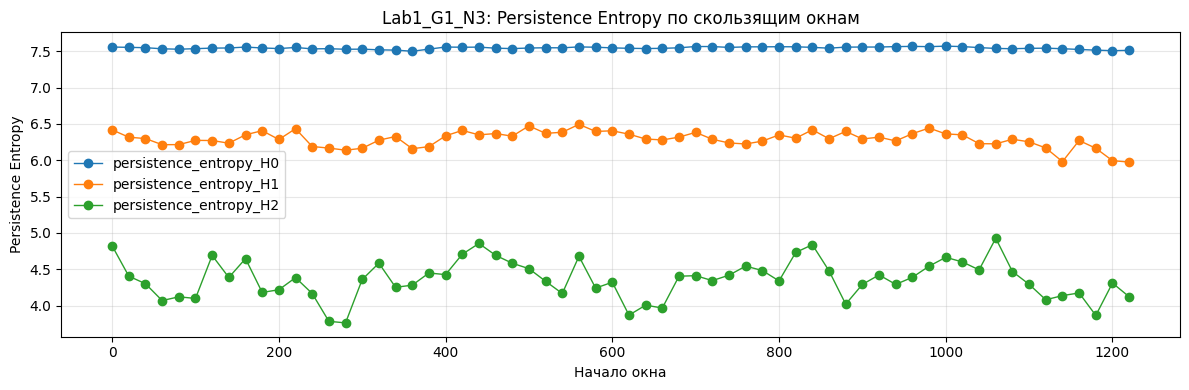

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G1_N3.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G1_N3.csv
Анализ скрытых режимов для ряда: Lab1_G2_Fн9
dim = 5, tau = 3
Длина ряда: 1439
Размер embedding: (1427, 5)
Окно: 200, шаг: 20
Количество окон: 62
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G2_Fн9,2,0.351332
1,Lab1_G2_Fн9,3,0.351967
2,Lab1_G2_Fн9,4,0.308683


Лучшее K для окон ряда Lab1_G2_Fн9 по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,12
1,1,23
2,2,27


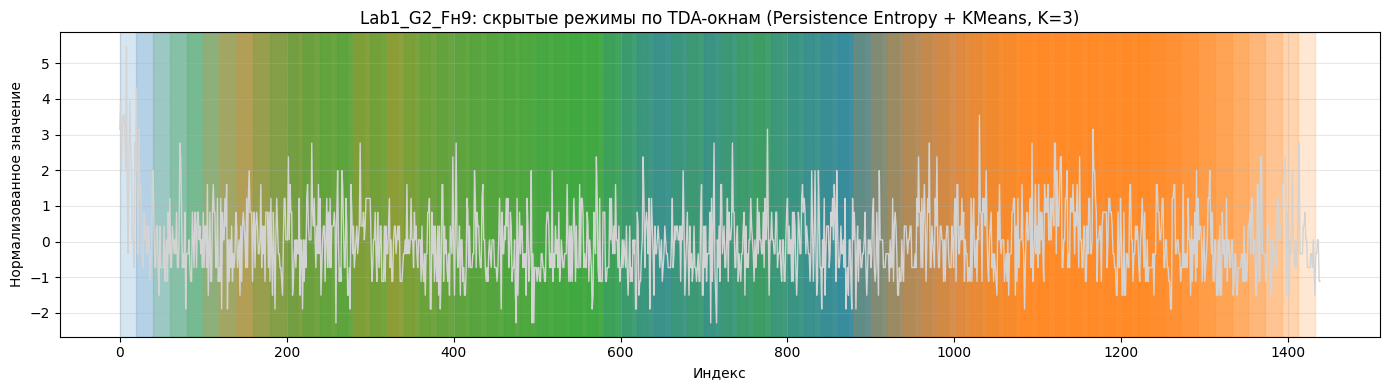

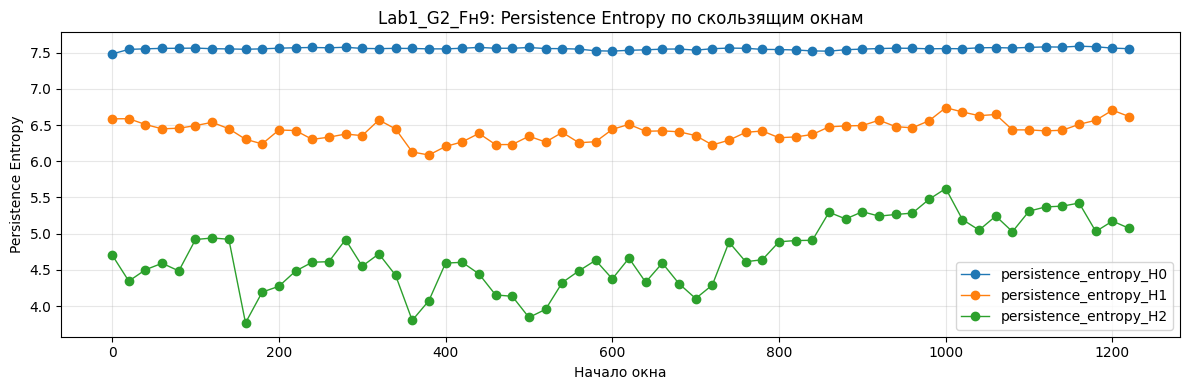

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G2_Fн9.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G2_Fн9.csv
Анализ скрытых режимов для ряда: Lab1_G1_N1
dim = 4, tau = 98
Длина ряда: 1439
Размер embedding: (1145, 4)
Окно: 200, шаг: 20
Количество окон: 48
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G1_N1,2,0.519853
1,Lab1_G1_N1,3,0.498631
2,Lab1_G1_N1,4,0.361027


Лучшее K для окон ряда Lab1_G1_N1 по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,28
1,1,20


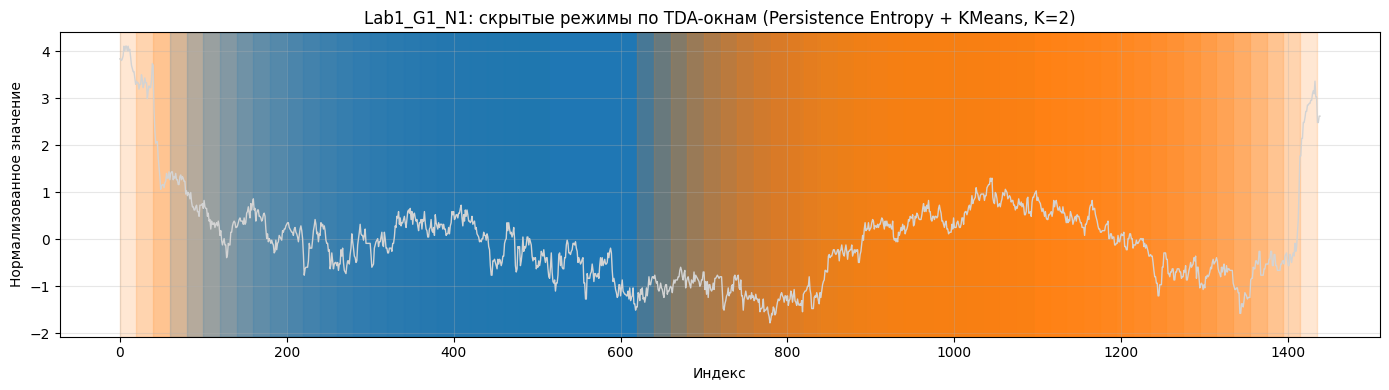

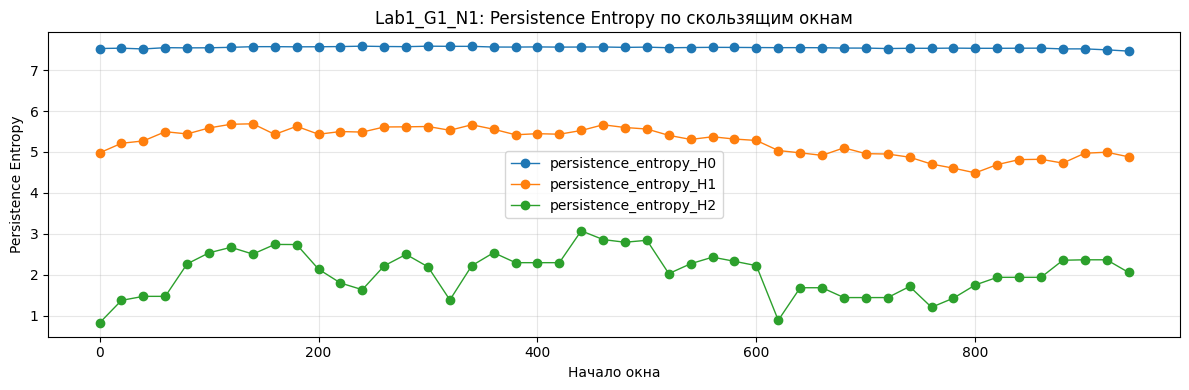

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G1_N1.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G1_N1.csv
Анализ скрытых режимов для ряда: Lab1_G1_N2
dim = 6, tau = 14
Длина ряда: 1439
Размер embedding: (1369, 6)
Окно: 200, шаг: 20
Количество окон: 59
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G1_N2,2,0.564574
1,Lab1_G1_N2,3,0.513046
2,Lab1_G1_N2,4,0.392995


Лучшее K для окон ряда Lab1_G1_N2 по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,49
1,1,10


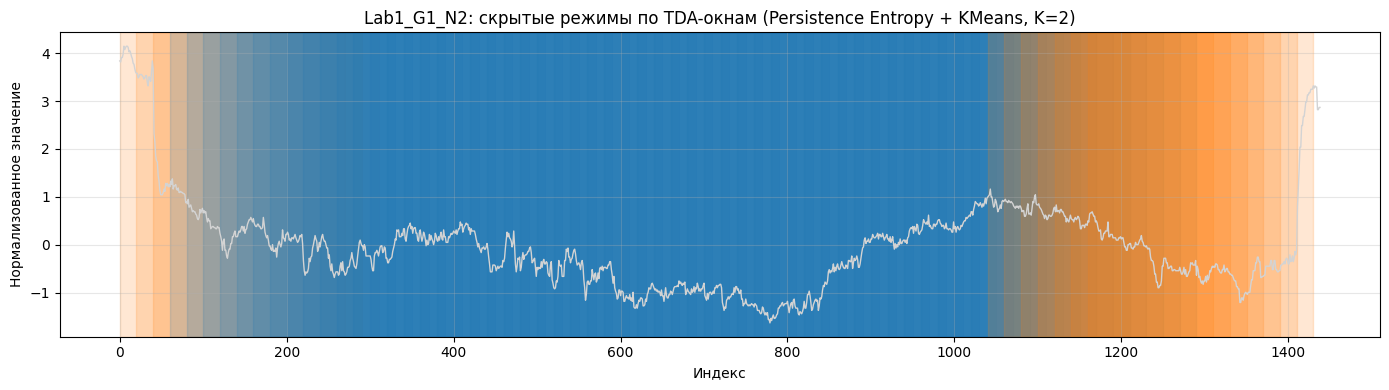

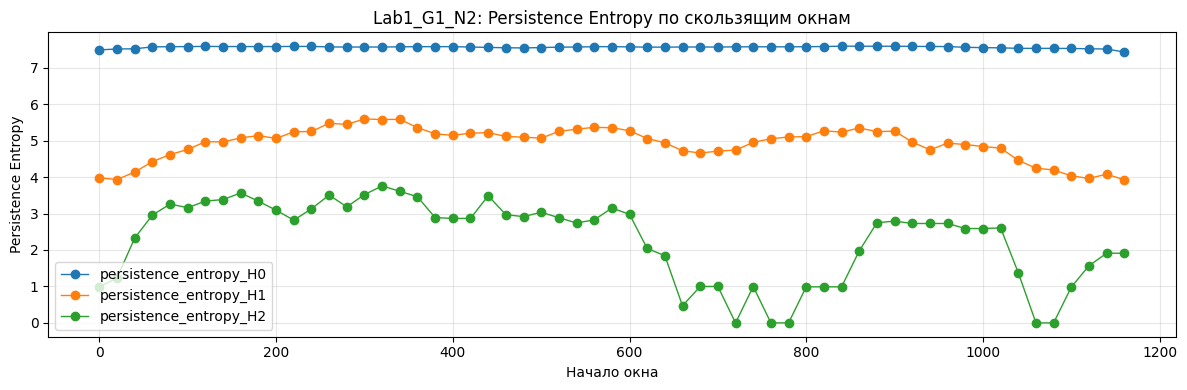

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G1_N2.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G1_N2.csv
Анализ скрытых режимов для ряда: Lab1_G2_3F2
dim = 5, tau = 3
Длина ряда: 1439
Размер embedding: (1427, 5)
Окно: 200, шаг: 20
Количество окон: 62
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G2_3F2,2,0.413188
1,Lab1_G2_3F2,3,0.426015
2,Lab1_G2_3F2,4,0.380552


Лучшее K для окон ряда Lab1_G2_3F2 по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,31
1,1,25
2,2,6


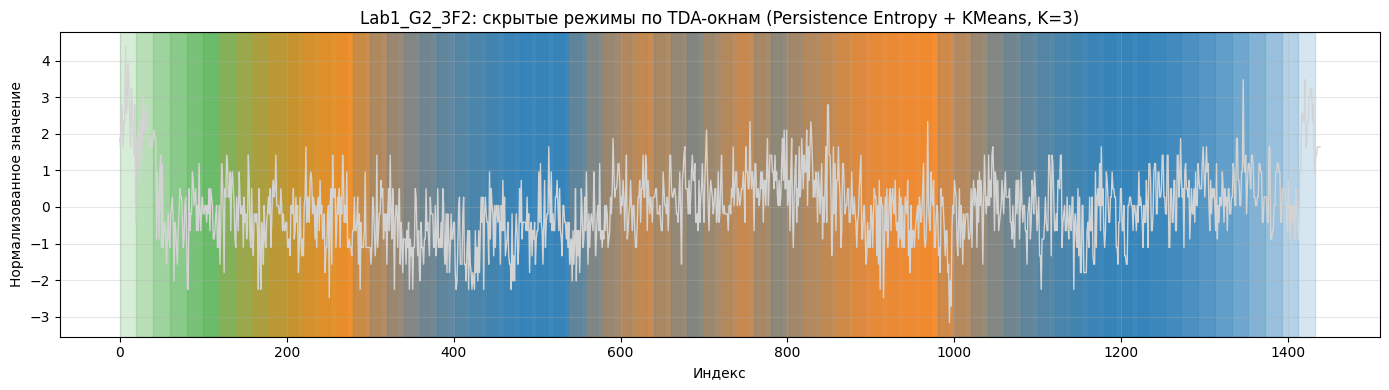

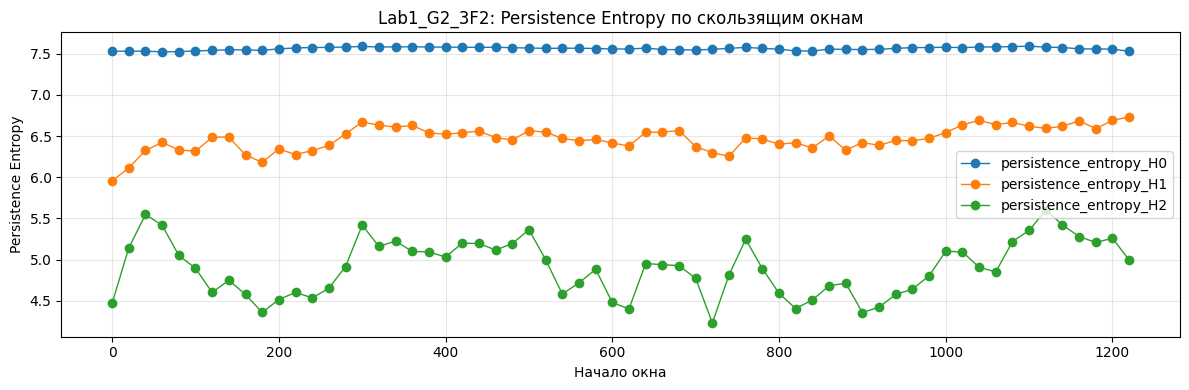

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G2_3F2.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G2_3F2.csv
Анализ скрытых режимов для ряда: Lab1_G1_T4ср
dim = 5, tau = 51
Длина ряда: 1439
Размер embedding: (1235, 5)
Окно: 200, шаг: 20
Количество окон: 52
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G1_T4ср,2,0.409682
1,Lab1_G1_T4ср,3,0.442890
2,Lab1_G1_T4ср,4,0.432332


Лучшее K для окон ряда Lab1_G1_T4ср по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,21
1,1,27
2,2,4


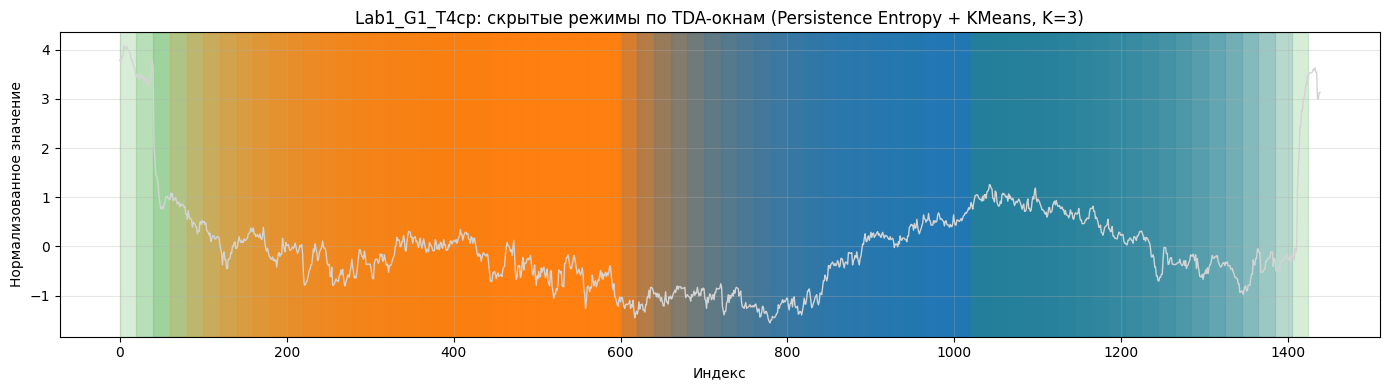

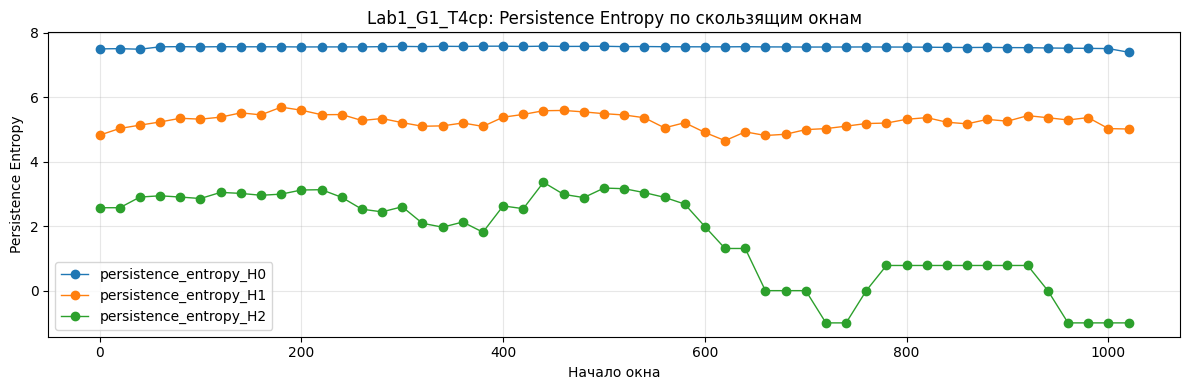

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G1_T4ср.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G1_T4ср.csv
Анализ скрытых режимов для ряда: Lab1_G3_T606
dim = 9, tau = 24
Длина ряда: 1439
Размер embedding: (1247, 9)
Окно: 200, шаг: 20
Количество окон: 53
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G3_T606,2,0.460280
1,Lab1_G3_T606,3,0.453968
2,Lab1_G3_T606,4,0.484954


Лучшее K для окон ряда Lab1_G3_T606 по silhouette: 4
Размеры найденных режимов:


,regime,windows_count
0,0,21
1,1,7
2,2,13
3,3,12


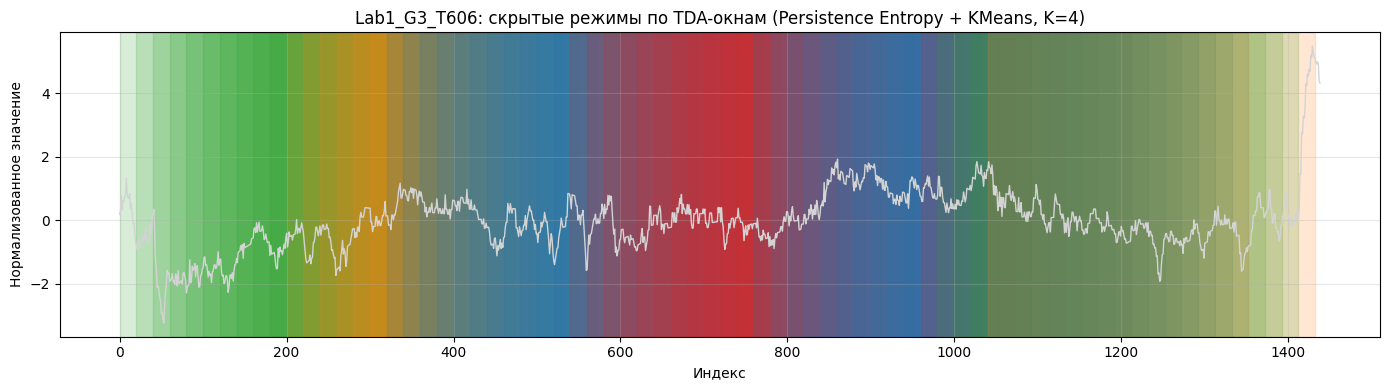

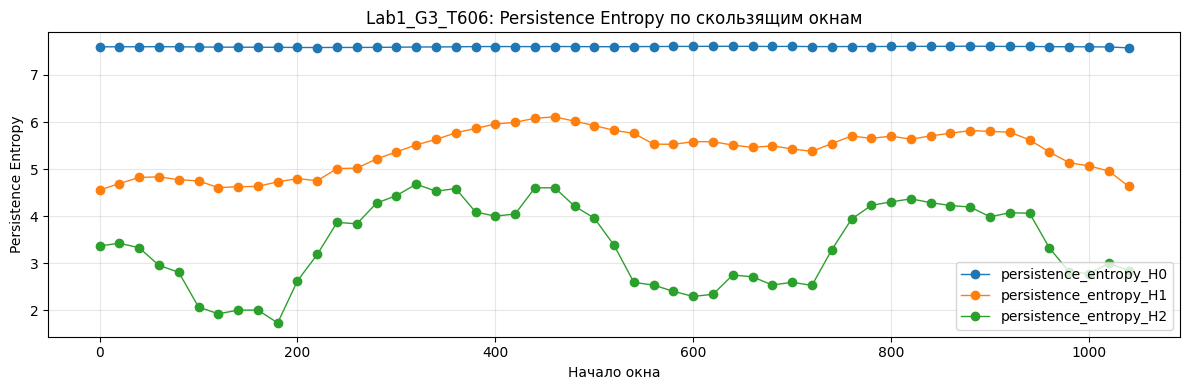

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G3_T606.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G3_T606.csv
Анализ скрытых режимов для ряда: Lab1_Qtg
dim = 3, tau = 19
Длина ряда: 1439
Размер embedding: (1401, 3)
Окно: 200, шаг: 20
Количество окон: 61
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_Qtg,2,0.327493
1,Lab1_Qtg,3,0.370193
2,Lab1_Qtg,4,0.345614


Лучшее K для окон ряда Lab1_Qtg по silhouette: 3
Размеры найденных режимов:


,regime,windows_count
0,0,30
1,1,26
2,2,5


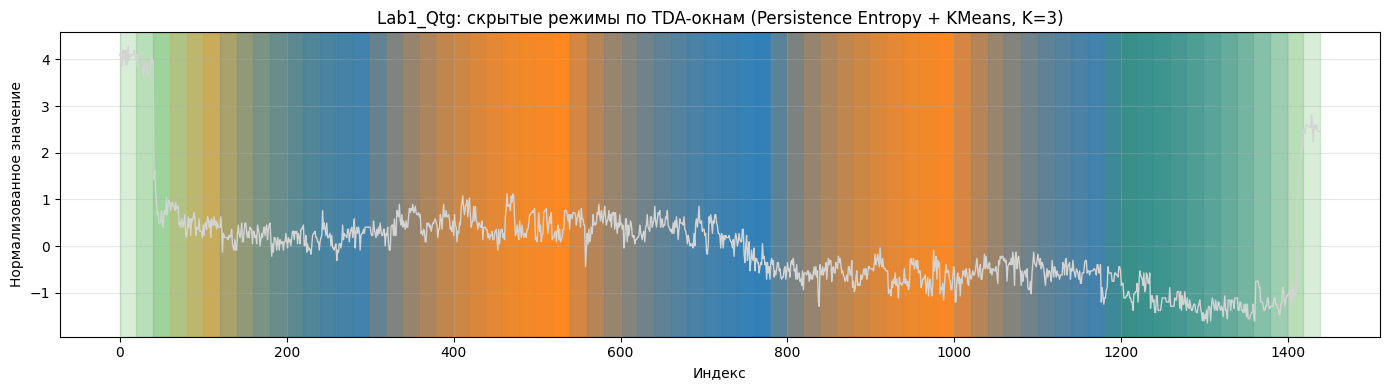

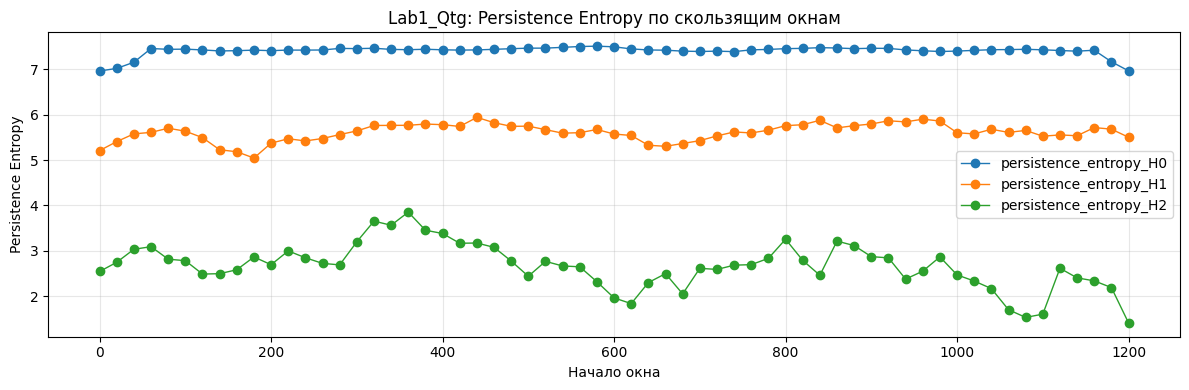

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_Qtg.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_Qtg.csv
Анализ скрытых режимов для ряда: Lab1_G2_2F2
dim = 6, tau = 2
Длина ряда: 1439
Размер embedding: (1429, 6)
Окно: 200, шаг: 20
Количество окон: 62
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G2_2F2,2,0.472589
1,Lab1_G2_2F2,3,0.446940
2,Lab1_G2_2F2,4,0.410415


Лучшее K для окон ряда Lab1_G2_2F2 по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,42
1,1,20


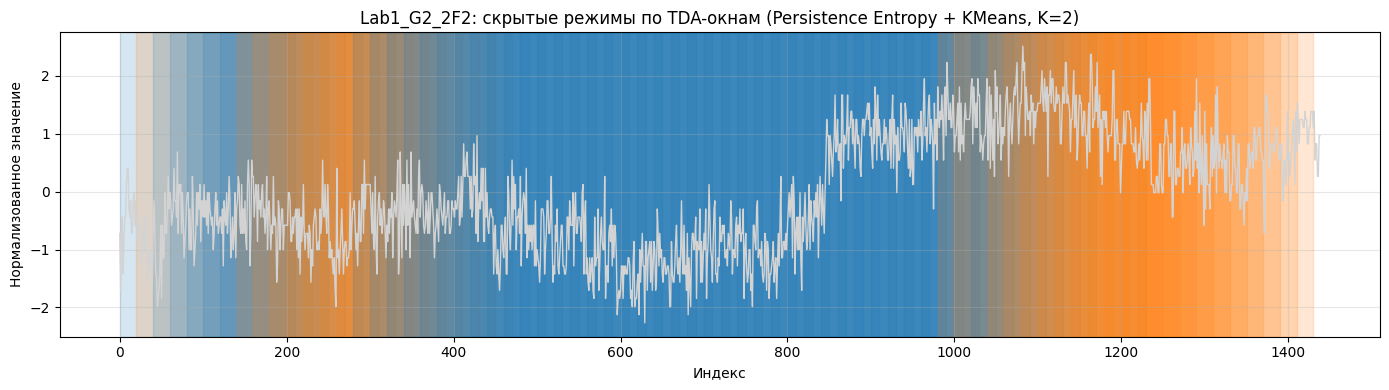

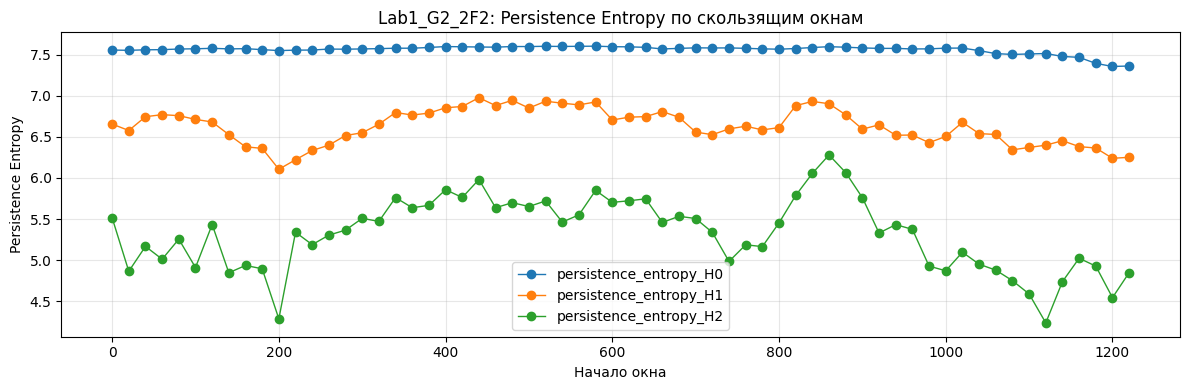

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G2_2F2.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G2_2F2.csv
Анализ скрытых режимов для ряда: Lab1_G3_T600
dim = 8, tau = 22
Длина ряда: 1439
Размер embedding: (1285, 8)
Окно: 200, шаг: 20
Количество окон: 55
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G3_T600,2,0.363477
1,Lab1_G3_T600,3,0.411781
2,Lab1_G3_T600,4,0.479576


Лучшее K для окон ряда Lab1_G3_T600 по silhouette: 4
Размеры найденных режимов:


,regime,windows_count
0,0,14
1,1,13
2,2,17
3,3,11


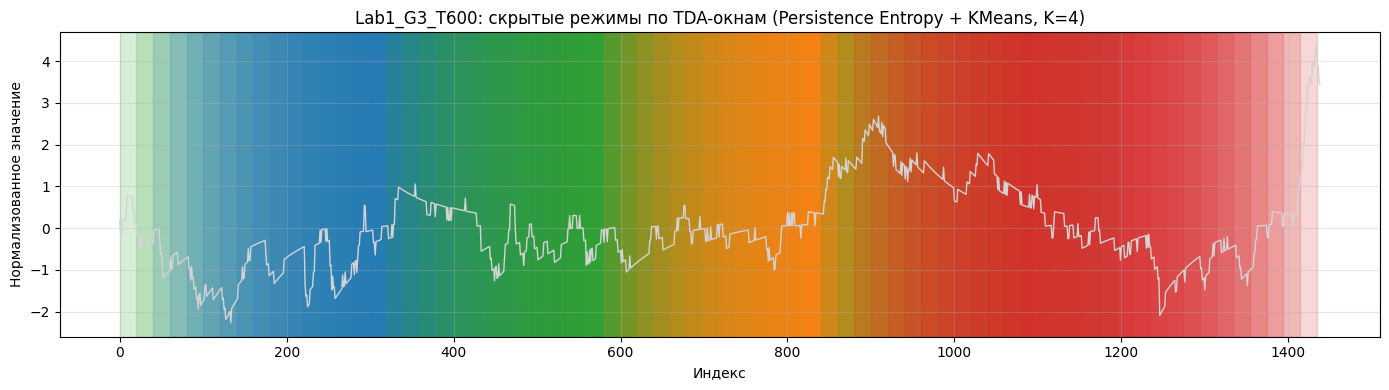

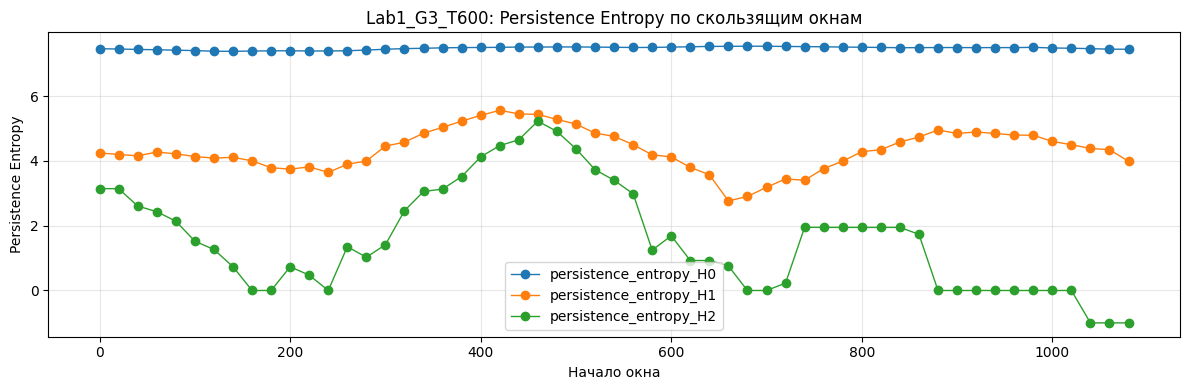

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G3_T600.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G3_T600.csv
Анализ скрытых режимов для ряда: Lab1_G4_N1пр
dim = 6, tau = 4
Длина ряда: 1439
Размер embedding: (1419, 6)
Окно: 200, шаг: 20
Количество окон: 61
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G4_N1пр,2,0.465301
1,Lab1_G4_N1пр,3,0.434910
2,Lab1_G4_N1пр,4,0.340249


Лучшее K для окон ряда Lab1_G4_N1пр по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,36
1,1,25


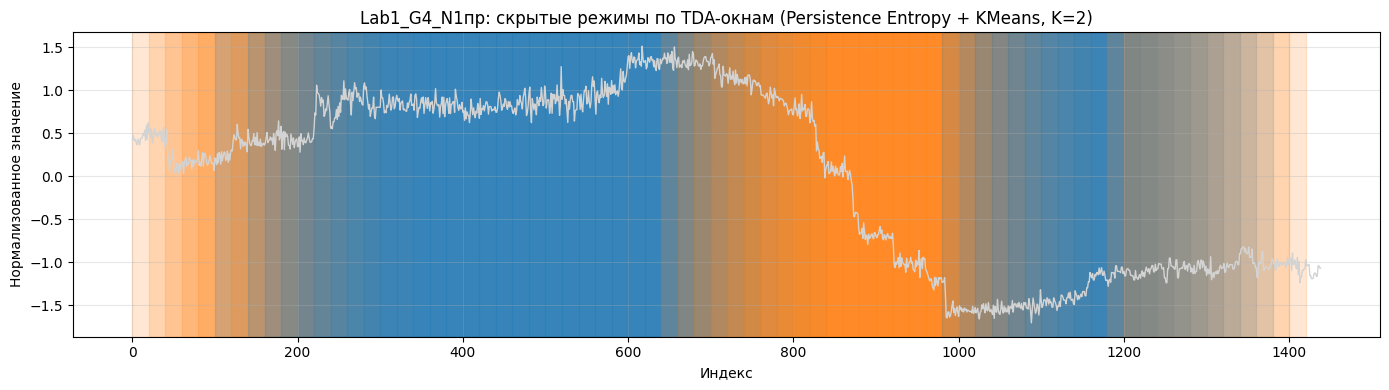

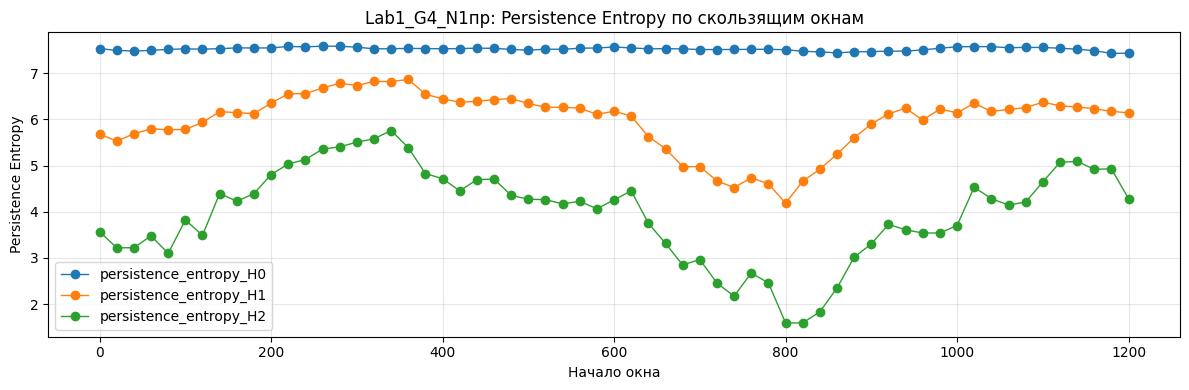

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G4_N1пр.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G4_N1пр.csv
Анализ скрытых режимов для ряда: Lab1_PposleNag
dim = 5, tau = 60
Длина ряда: 1439
Размер embedding: (1199, 5)
Окно: 200, шаг: 20
Количество окон: 50
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_PposleNag,2,0.456724
1,Lab1_PposleNag,3,0.548723
2,Lab1_PposleNag,4,0.553115


Лучшее K для окон ряда Lab1_PposleNag по silhouette: 4
Размеры найденных режимов:


,regime,windows_count
0,0,13
1,1,8
2,2,11
3,3,18


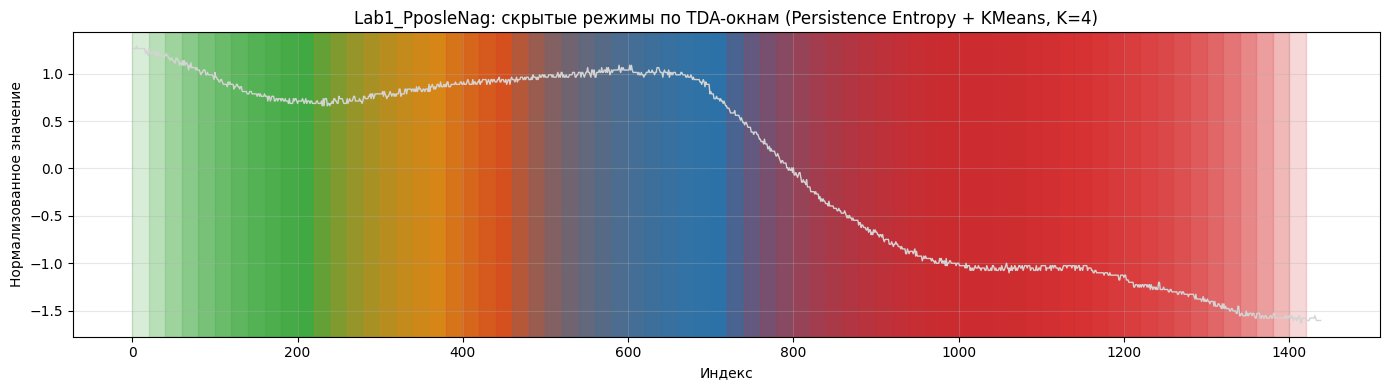

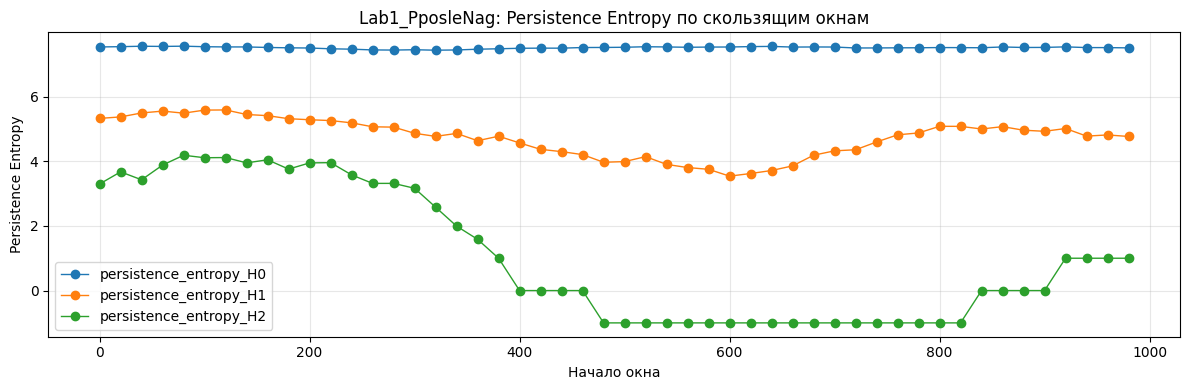

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_PposleNag.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_PposleNag.csv
Анализ скрытых режимов для ряда: Lab1_dev
dim = 5, tau = 4
Длина ряда: 1439
Размер embedding: (1423, 5)
Окно: 200, шаг: 20
Количество окон: 62
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_dev,2,0.304081
1,Lab1_dev,3,0.305993
2,Lab1_dev,4,0.332247


Лучшее K для окон ряда Lab1_dev по silhouette: 4
Размеры найденных режимов:


,regime,windows_count
0,0,19
1,1,15
2,2,19
3,3,9


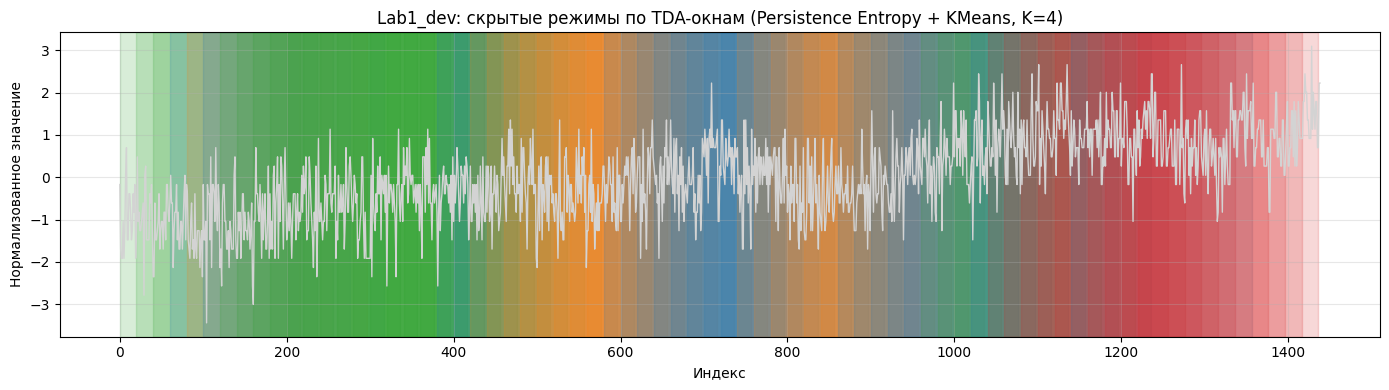

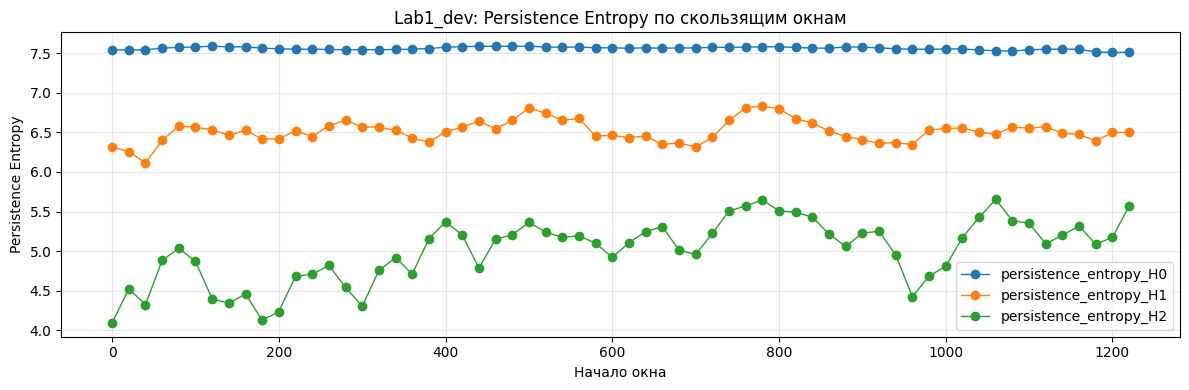

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_dev.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_dev.csv
Анализ скрытых режимов для ряда: Lab1_TC_Ptgdg
dim = 7, tau = 14
Длина ряда: 1439
Размер embedding: (1355, 7)
Окно: 200, шаг: 20
Количество окон: 58
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_TC_Ptgdg,2,0.406498
1,Lab1_TC_Ptgdg,3,0.395479
2,Lab1_TC_Ptgdg,4,0.448060


Лучшее K для окон ряда Lab1_TC_Ptgdg по silhouette: 4
Размеры найденных режимов:


,regime,windows_count
0,0,11
1,1,24
2,2,12
3,3,11


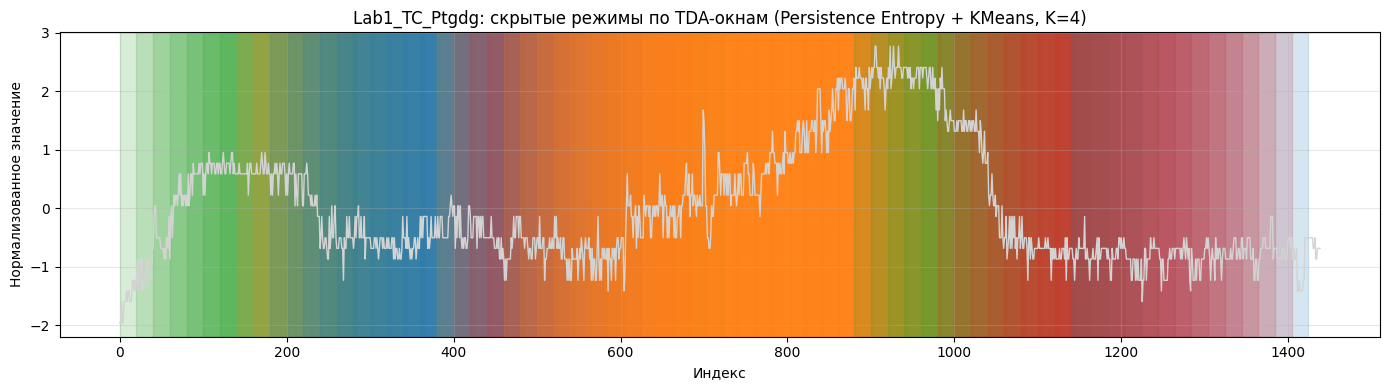

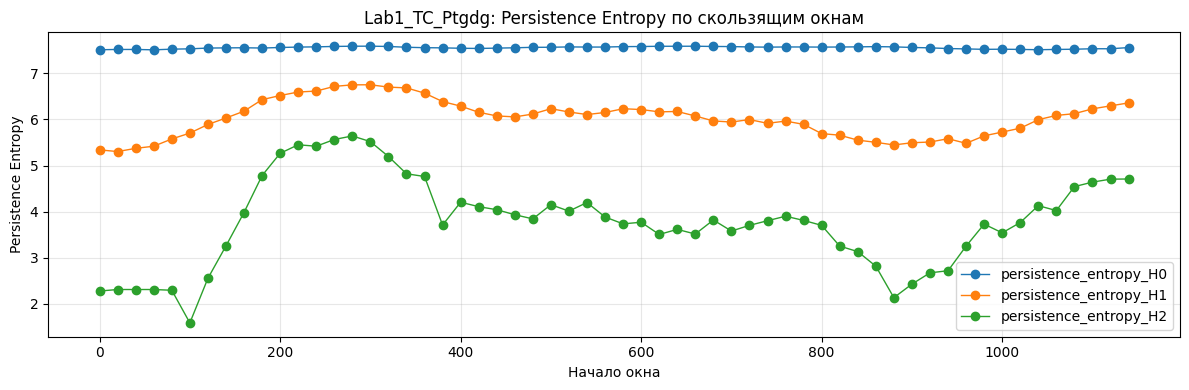

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_TC_Ptgdg.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_TC_Ptgdg.csv
Анализ скрытых режимов для ряда: Lab1_G1_T1
dim = 6, tau = 33
Длина ряда: 1439
Размер embedding: (1274, 6)
Окно: 200, шаг: 20
Количество окон: 54
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G1_T1,2,0.359290
1,Lab1_G1_T1,3,0.371036
2,Lab1_G1_T1,4,0.388290


Лучшее K для окон ряда Lab1_G1_T1 по silhouette: 4
Размеры найденных режимов:


,regime,windows_count
0,0,9
1,1,14
2,2,21
3,3,10


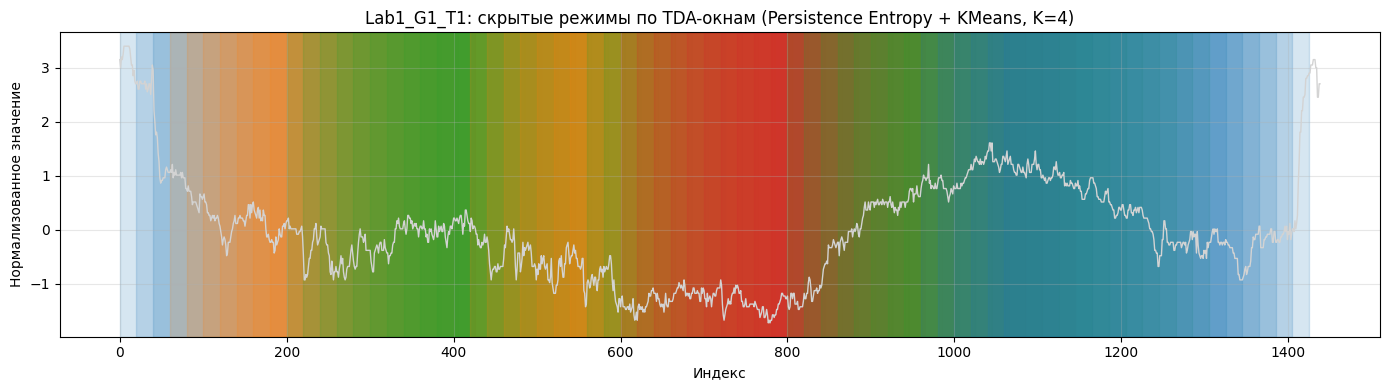

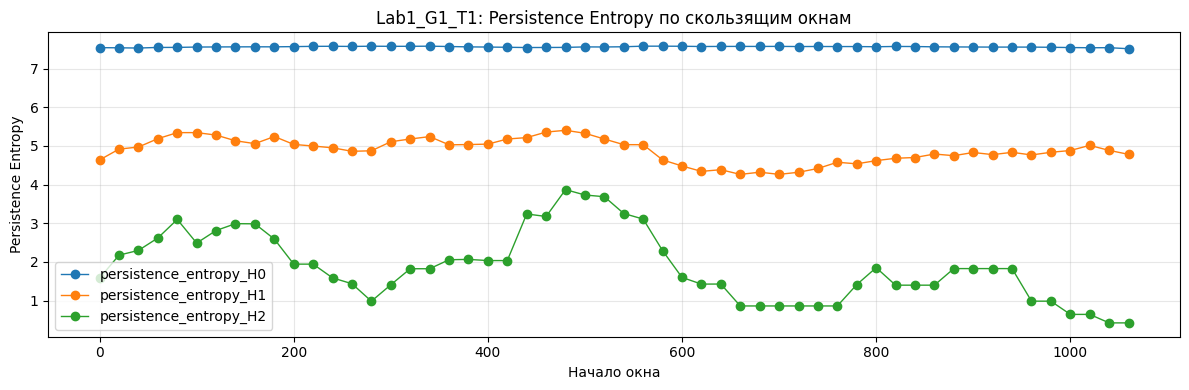

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G1_T1.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G1_T1.csv
Анализ скрытых режимов для ряда: Lab1_G1_T638
dim = 7, tau = 12
Длина ряда: 1439
Размер embedding: (1367, 7)
Окно: 200, шаг: 20
Количество окон: 59
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G1_T638,2,0.354330
1,Lab1_G1_T638,3,0.344911
2,Lab1_G1_T638,4,0.386303


Лучшее K для окон ряда Lab1_G1_T638 по silhouette: 4
Размеры найденных режимов:


,regime,windows_count
0,0,28
1,1,9
2,2,9
3,3,13


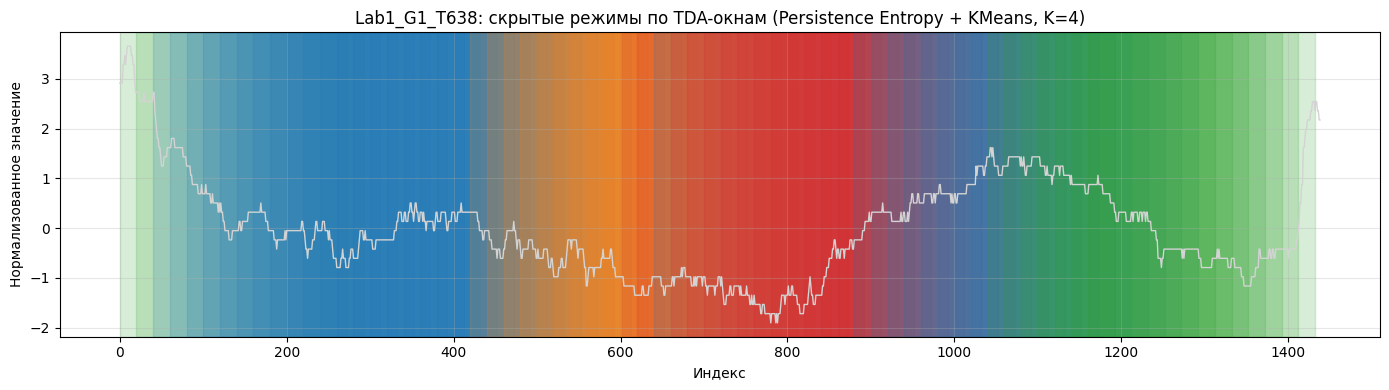

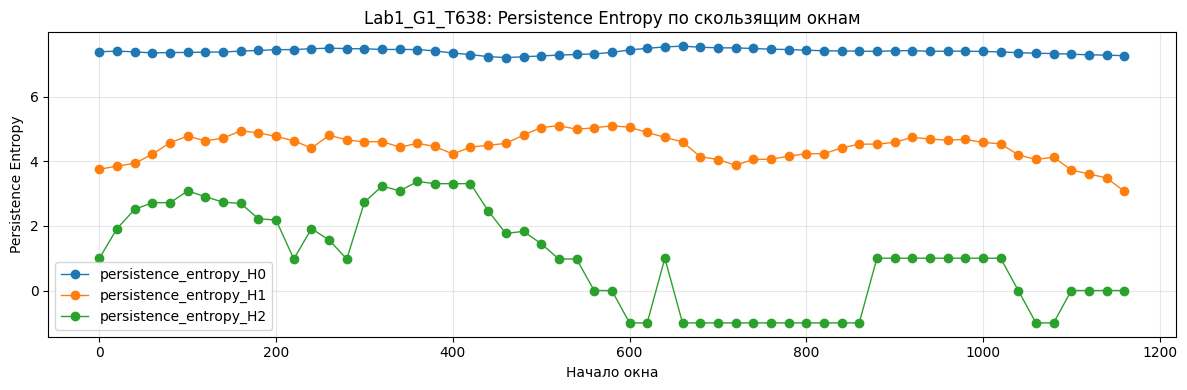

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G1_T638.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G1_T638.csv
Анализ скрытых режимов для ряда: Lab1_G4_delta_T4PR
dim = 5, tau = 28
Длина ряда: 1439
Размер embedding: (1327, 5)
Окно: 200, шаг: 20
Количество окон: 57
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G4_delta_T4PR,2,0.457439
1,Lab1_G4_delta_T4PR,3,0.352575
2,Lab1_G4_delta_T4PR,4,0.367558


Лучшее K для окон ряда Lab1_G4_delta_T4PR по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,38
1,1,19


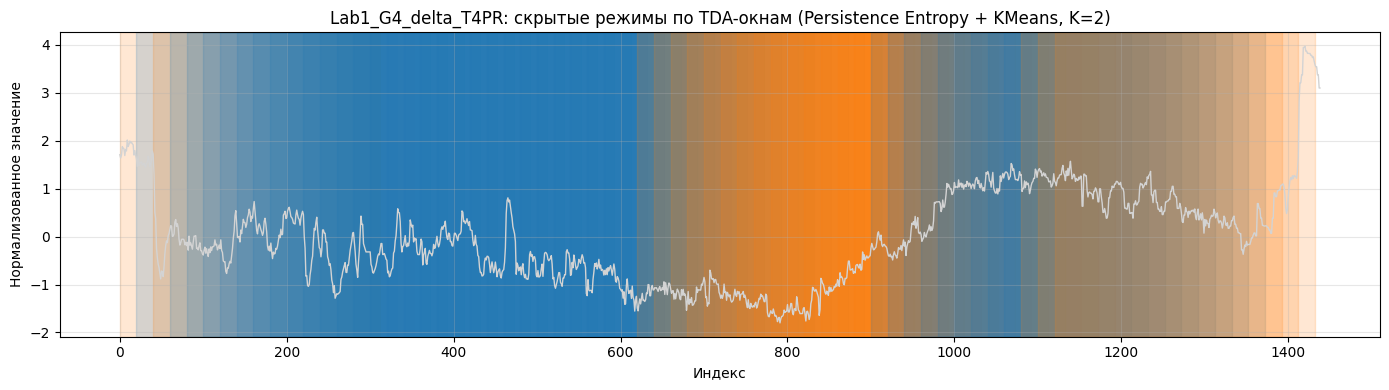

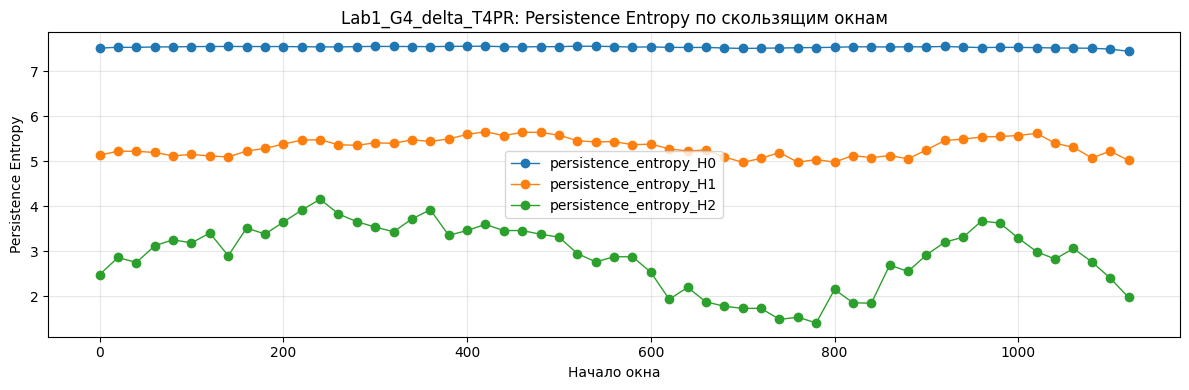

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G4_delta_T4PR.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G4_delta_T4PR.csv
Анализ скрытых режимов для ряда: Lab1_G4_delta_T4
dim = 6, tau = 18
Длина ряда: 1439
Размер embedding: (1349, 6)
Окно: 200, шаг: 20
Количество окон: 58
Качество кластеризации окон:


,series,K,silhouette
0,Lab1_G4_delta_T4,2,0.551602
1,Lab1_G4_delta_T4,3,0.540671
2,Lab1_G4_delta_T4,4,0.387615


Лучшее K для окон ряда Lab1_G4_delta_T4 по silhouette: 2
Размеры найденных режимов:


,regime,windows_count
0,0,49
1,1,9


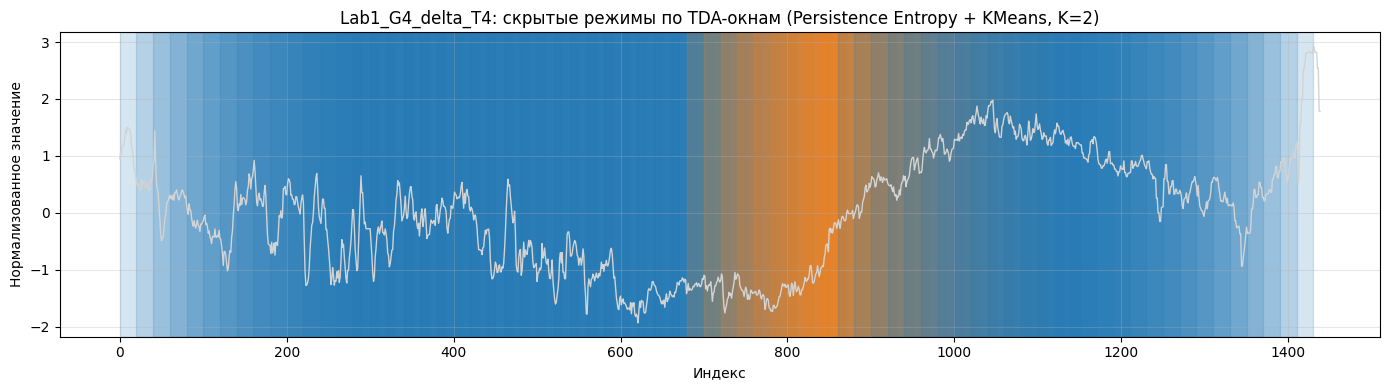

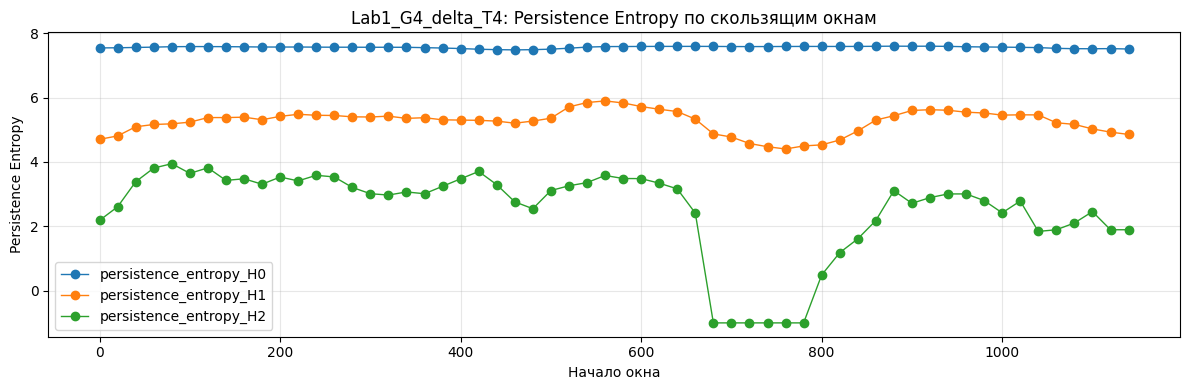

Режимы сохранены:
persistence_vectors\hidden_regimes_Lab1_G4_delta_T4.csv
Качество K сохранено:
persistence_vectors\hidden_regimes_quality_Lab1_G4_delta_T4.csv

Общая таблица режимов для остальных рядов сохранена:
persistence_vectors\hidden_regimes_other_series.csv


,series,window_start_embedding,window_end_embedding,window_start_raw,window_end_raw,regime,persistence_entropy_H0,persistence_entropy_H1,persistence_entropy_H2
0,Lab1_G1_N3,0,200,0,209,0,7.557615,6.417982,4.821668
1,Lab1_G1_N3,20,220,20,229,0,7.553170,6.316395,4.403728
2,Lab1_G1_N3,40,240,40,249,0,7.548615,6.297926,4.299568
3,Lab1_G1_N3,60,260,60,269,1,7.533386,6.213487,4.067821
4,Lab1_G1_N3,80,280,80,289,1,7.527575,6.214490,4.119386



Общая таблица качества для остальных рядов сохранена:
persistence_vectors\hidden_regimes_quality_other_series.csv


,series,K,silhouette
0,Lab1_G1_N3,2,0.414570
1,Lab1_G1_N3,3,0.284499
2,Lab1_G1_N3,4,0.297063
3,Lab1_G2_Fн9,2,0.351332
4,Lab1_G2_Fн9,3,0.351967
5,Lab1_G2_Fн9,4,0.308683
6,Lab1_G1_N1,2,0.519853
7,Lab1_G1_N1,3,0.498631
8,Lab1_G1_N1,4,0.361027
9,Lab1_G1_N2,2,0.564574



Глобальные norm и embedding_info восстановлены обратно.


In [195]:
# ============================================================
# Анализ скрытых режимов для остальных рядов
# то есть для всех рядов, кроме кандидатов K1/K2
# ============================================================

# ------------------------------------------------------------
# 1. Восстанавливаем список кандидатов, которые уже анализировали
# ------------------------------------------------------------

k1_candidate_series = [
    "Lab1_G2_Fc3",
    "Lab1_G2_VoГГ",
    "Lab1_G3_Pc2",
    "Lab1_Hpol",
    "Lab1_dPmg",
]

k2_candidate_series = [
    "Lab1_G1_T600",
    "Lab1_G1_T607",
    "Lab1_G3_Коксование",
    "Lab1_G3_Турбина_ГГ",
    "Lab1_TC_Tm",
    "Lab1_TdoNag",
    "Lab1_TposleNag",
    "Lab1_Ttg",
    "Lab1_dPmg",
]

candidate_series_main = sorted(
    set(k1_candidate_series + k2_candidate_series)
)

print("Уже выбранные кандидаты, которые исключаем:")
for col in candidate_series_main:
    print("-", col)


# ------------------------------------------------------------
# 2. Берём все ряды, для которых есть параметры вложения
# ------------------------------------------------------------

all_series_with_embedding = [
    col for col in uniform_dimensions["column"].tolist()
    if col in source_df.columns
]

other_series = [
    col for col in all_series_with_embedding
    if col not in candidate_series_main
]

print("\nОстальные ряды для анализа:")
for col in other_series:
    print("-", col)

print(f"\nКоличество остальных рядов: {len(other_series)}")

if len(other_series) == 0:
    raise ValueError("Нет рядов для анализа после исключения кандидатов.")


# ------------------------------------------------------------
# 3. Создаём norm для остальных рядов
# ------------------------------------------------------------

norm_backup = norm.copy()
embedding_info_backup = embedding_info.copy()

norm_other = source_df[other_series].copy()

norm_other = norm_other.apply(pd.to_numeric, errors="coerce")
norm_other = norm_other.replace([np.inf, -np.inf], np.nan)

norm_other = norm_other.interpolate(limit_direction="both")
norm_other = norm_other.ffill().bfill()

norm_other = (norm_other - norm_other.mean()) / norm_other.std(ddof=0)

norm_other = norm_other.dropna(axis=1, how="all")

other_series = [
    col for col in other_series
    if col in norm_other.columns
]

print("\nТаблица norm_other создана.")
print("Форма norm_other:", norm_other.shape)

display(norm_other.head())


# ------------------------------------------------------------
# 4. Создаём embedding_info для остальных рядов
# без автозамены параметров
# ------------------------------------------------------------

embedding_info_other = {}

for _, row in uniform_dimensions.iterrows():
    col_name = row["column"]

    if col_name not in other_series:
        continue

    if col_name not in norm_other.columns:
        continue

    tau_value = row["tau"]
    dim_value = row["dimension"]

    if pd.isna(tau_value) or pd.isna(dim_value):
        continue

    embedding_info_other[col_name] = {
        "tau": int(max(1, round(float(tau_value)))),
        "dim": int(max(2, round(float(dim_value))))
    }

print("\nembedding_info_other создан.")
print("Количество рядов с параметрами:", len(embedding_info_other))

for col, params in embedding_info_other.items():
    print(col, params)

missing_other_embedding = [
    col for col in other_series
    if col not in embedding_info_other
]

print("\nОстальные ряды без параметров вложения:")
for col in missing_other_embedding:
    print("-", col)

other_series = [
    col for col in other_series
    if col in embedding_info_other
]

print("\nИтоговые остальные ряды для анализа:")
for col in other_series:
    print("-", col)


# ------------------------------------------------------------
# 5. Временно подменяем norm и embedding_info,
# чтобы использовать уже написанную функцию analyze_hidden_regimes_tda
# ------------------------------------------------------------

norm = norm_other
embedding_info = embedding_info_other


# ------------------------------------------------------------
# 6. Запуск анализа для остальных рядов
# ------------------------------------------------------------

all_regimes_other = []
all_regime_quality_other = []

for col in other_series:
    regimes_df, quality_df, entropy_df = analyze_hidden_regimes_tda(
        col=col,
        win=200,
        step=20,
        K_values=(2, 3, 4),
        max_points=200,
        save_results=True
    )

    if regimes_df is not None:
        all_regimes_other.append(regimes_df)

    if quality_df is not None:
        all_regime_quality_other.append(quality_df)


# ------------------------------------------------------------
# 7. Сохраняем общие таблицы по остальным рядам
# ------------------------------------------------------------

if all_regimes_other:
    all_regimes_other_df = pd.concat(
        all_regimes_other,
        ignore_index=True
    )

    all_regimes_other_df.to_csv(
        OUTPUT_DIR / "hidden_regimes_other_series.csv",
        index=False
    )

    print("\nОбщая таблица режимов для остальных рядов сохранена:")
    print(OUTPUT_DIR / "hidden_regimes_other_series.csv")

    display(all_regimes_other_df.head())

else:
    print("\nНе удалось построить режимы ни для одного из остальных рядов.")


if all_regime_quality_other:
    all_regime_quality_other_df = pd.concat(
        all_regime_quality_other,
        ignore_index=True
    )

    all_regime_quality_other_df.to_csv(
        OUTPUT_DIR / "hidden_regimes_quality_other_series.csv",
        index=False
    )

    print("\nОбщая таблица качества для остальных рядов сохранена:")
    print(OUTPUT_DIR / "hidden_regimes_quality_other_series.csv")

    display(all_regime_quality_other_df)

else:
    print("\nНет таблиц качества для остальных рядов.")


# ------------------------------------------------------------
# 8. Возвращаем norm и embedding_info обратно к кандидатам
# ------------------------------------------------------------

norm = norm_backup
embedding_info = embedding_info_backup

print("\nГлобальные norm и embedding_info восстановлены обратно.")